# Deng--Ginting Example 4 with hard-conservative curl PINN flux reconstruction, Q1 CG

This notebook is a no-fracture source--sink benchmark on \(\Omega=(0,1)^2\), inspired by Deng--Ginting Example 4.  It keeps the SPE10 layer-20 permeability/grid from the MRST export, but replaces the boundary-pressure problem by

\[
-\nabla\cdot(\kappa\nabla p)=q_I\chi_{K_I}/|K_I|-q_P\chi_{K_P}/|K_P|,
\qquad p=0\quad\text{on }\partial\Omega.
\]

The source points are the Deng locations scaled from \((0,5)\times(0,1)\) to \((0,1)^2\): \(x_I=(0.2,0.4)\), \(x_P=(0.8,0.5)\).  The point sources are regularized as cell-integrated sources on the matching SPE10/MRST cells.  Transport uses clean boundary inflow \(S=0\), source concentration \(S_I=1\), and an explicit upwind Buckley--Leverett update on the Deng nodal dual control volumes \(C_z\).

Flux choices:

- `CG`: raw Q1 CG flux, averaged on transport-cell interfaces.
- `NLR`: Deng/Ginting local Q1 reconstruction on nodal dual control volumes.
- `CVFEM`: vertex-centred control-volume finite-element pressure solve on the same nodal dual mesh.
- `PINN`: hard-conservative stream-function reconstruction, trained on Deng dual-volume CG face fluxes.
- `MRST`: included only if a matching homogeneous-Dirichlet source--sink MRST export is loaded.


Run order: execute the setup, pressure solve, Deng/NLR dual-flux assembly, then the hard-conservative stream-function PINN cell. The old soft-penalty PINN branch has been removed from this notebook.


In [1]:
import pathlib
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from scipy.io import loadmat
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

try:
    import torch
    import torch.nn as nn
    from tqdm.auto import tqdm
    TORCH_AVAILABLE = True
except ModuleNotFoundError:
    torch = None
    nn = None
    TORCH_AVAILABLE = False

    def tqdm(iterable, **kwargs):
        return iterable

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

np.random.seed(1234)
if TORCH_AVAILABLE:
    torch.manual_seed(1234)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
    device = "numpy"

# Active CG/FEM order.  Q1 uses the classical vertex dual mesh; Q2 uses the
# midpoint-bounded Q2 nodal dual mesh for Deng/CVFEM/transport.
CG_ORDER = 1
RUN_CVFEM_SOLVE = True
RUN_DUAL_TRANSPORT = True
HARD_CURL_PINN_VARIANT = True
PINN_ACTIVE = False  # becomes True only after the hard-curl reconstruction cell succeeds
HARD_CURL_PINN_ACTIVE = False

# Base SPE10 export: currently used for grid and permeability.  If a matching
# source-sink MRST export is added later, put it earlier in DATA_CANDIDATES.
DATA_CANDIDATES = [
    pathlib.Path("case3_ecmor/case3_mrst_export_spe10_L20_64_wells.mat"),
    pathlib.Path("case3_ecmor/case3_mrst_export_spe10_L20_64_deng_example4.mat"),
    pathlib.Path("case3_ecmor/case3_mrst_export_spe10_L20_64_sourcesink.mat"),
    pathlib.Path("case3_ecmor/case3_mrst_export_spe10_L20_64.mat"),
]
DATA_FILE = None
for candidate in DATA_CANDIDATES:
    if candidate.exists():
        DATA_FILE = candidate
        break
if DATA_FILE is None:
    for candidate in DATA_CANDIDATES:
        matches = sorted(pathlib.Path.cwd().glob(f"**/{candidate.as_posix()}"))
        if matches:
            DATA_FILE = matches[0]
            break
if DATA_FILE is None or not DATA_FILE.exists():
    raise FileNotFoundError("Could not find an SPE10 layer-20 MRST export containing kappa_cell/kappa_grid.")

mrst = loadmat(DATA_FILE, squeeze_me=True, struct_as_record=False)

if CG_ORDER == 2:
    FINE_MRST_CANDIDATES = [
        pathlib.Path("case3_ecmor/case3_mrst_export_spe10_q2_dualT.mat"),
        pathlib.Path("case3_ecmor/case3_mrst_export_finep_dualT.mat"),
        pathlib.Path("case3_ecmor/case3_mrst_export_fine128_wells.mat"),
    ]
elif CG_ORDER == 1:
    FINE_MRST_CANDIDATES = [
        pathlib.Path("case3_ecmor/case3_mrst_export_finep_dualT.mat"),
        pathlib.Path("case3_ecmor/case3_mrst_export_fine128_wells.mat"),
        pathlib.Path("case3_ecmor/case3_mrst_export_spe10_q2_dualT.mat"),
    ]
else:
    raise ValueError("CG_ORDER must be 1 or 2.")
FINE_MRST_FILE = None
for candidate in FINE_MRST_CANDIDATES:
    if candidate.exists():
        FINE_MRST_FILE = candidate
        break
if FINE_MRST_FILE is None:
    for candidate in FINE_MRST_CANDIDATES:
        matches = sorted(pathlib.Path.cwd().glob(f"**/{candidate.as_posix()}"))
        if matches:
            FINE_MRST_FILE = matches[0]
            break
mrst_fine = loadmat(FINE_MRST_FILE, squeeze_me=True, struct_as_record=False) if FINE_MRST_FILE is not None else {}
MRST_FINE_AVAILABLE = bool(mrst_fine)


def _arr(key, dtype=float):
    if key not in mrst:
        raise KeyError(f"Missing MRST field {key!r}")
    return np.asarray(mrst[key], dtype=dtype)


def _meta_float(key, default=np.nan):
    if key not in mrst:
        return float(default)
    values = np.asarray(mrst[key]).reshape(-1)
    return float(values[0]) if values.size else float(default)


def _meta_str(key, default=""):
    return str(mrst.get(key, default))

xc_matrix = _arr("xc_matrix", float)
face_neighbors = _arr("face_neighbors", np.int64)
face_centroid = _arr("face_centroid", float)
face_normal = _arr("face_normal", float)
face_len = _arr("face_len", float).reshape(-1)
face_p1 = _arr("face_p1", float)
face_p2 = _arr("face_p2", float)
face_flux_mrst_export = _arr("face_flux", float).reshape(-1) if "face_flux" in mrst else None
p_matrix_mrst_export = _arr("p_matrix", float).reshape(-1) if "p_matrix" in mrst else None
face_is_boundary = _arr("face_is_boundary", bool).reshape(-1) if "face_is_boundary" in mrst else np.any(face_neighbors == 0, axis=1)
kappa_cell_mrst = _arr("kappa_cell", float).reshape(-1) if "kappa_cell" in mrst else None

nx, ny = np.asarray(mrst.get("meta_celldim", [64, 64]), dtype=int).reshape(-1) if "meta_celldim" in mrst else np.asarray([64, 64], dtype=int)
if int(xc_matrix.shape[0]) != int(nx * ny):
    n_guess = int(round(np.sqrt(xc_matrix.shape[0])))
    nx = ny = n_guess
physdim = np.asarray(mrst.get("meta_physdim", [1.0, 1.0]), dtype=float).reshape(-1)
if physdim.size < 2:
    physdim = np.array([1.0, 1.0], dtype=float)
phi_matrix = _meta_float("meta_phi_matrix", 1.0)
PV_matrix = _meta_float("meta_PV_matrix", _meta_float("meta_PV", phi_matrix * float(np.prod(physdim))))
CFL = _meta_float("meta_CFL", 0.45)
FPRIME_MAX = _meta_float("meta_FPRIME_MAX", 2.0)
SPE10_LAYER = _meta_float("meta_layer", 20.0)
SPE10_CONTRAST = _meta_float("meta_contrast", np.nan)

xmin, ymin = 0.0, 0.0
xmax, ymax = float(physdim[0]), float(physdim[1])
hx = physdim[0] / nx
hy = physdim[1] / ny
h_est = min(hx, hy)
ncell = int(xc_matrix.shape[0])
cell_area = np.full(ncell, float(np.prod(physdim)) / ncell, dtype=float)
cell_pv = phi_matrix * cell_area

kappa_cell_dg0 = np.asarray(kappa_cell_mrst, dtype=float).reshape(-1)
if kappa_cell_dg0.size != ncell:
    raise ValueError(f"Expected one SPE10 permeability value per cell ({ncell}), got {kappa_cell_dg0.size}.")

# Deng Example 4, x-coordinate scaled from [0,5] to [0,1].  The delta sources
# are regularized as cell-integrated sources on the selected grid cells.
SOURCE_POINTS_REQUESTED = np.array([[0.2, 0.4], [0.8, 0.5]], dtype=float)
SOURCE_RATES = np.array([1.0, -5.0], dtype=float)  # + spill/injector, - leakage/producer
SOURCE_SATURATION = 1.0
BOUNDARY_INFLOW_S = 0.0  # clean external reservoir on any pressure-boundary inflow
# Short defaults keep reruns quick under the CFL restriction of the unit-square
# SPE10 scaling.  Add 0.5, 1.0, 2.0 here if you want the paper's later times.
TRANSPORT_T_VALUES = np.array([0.02, 0.05, 0.1], dtype=float)
TRANSPORT_CASE_KEY = "T0.05"
TRANSPORT_CLIP = True
TRANSPORT_USE_FIXED_DT = False
TRANSPORT_DT = 1.0e-4  # Optional paper-style fixed dt; CFL mode is safer here.

# Matching MRST reference is only valid if the export has the same homogeneous
# Dirichlet/source-sink setup.  The old boundary-driven SPE10 export is not used
# as a reference for this notebook.
_meta_joined = " ".join([_meta_str("README"), _meta_str("meta_bc"), _meta_str("meta_source")]).lower()
MRST_REFERENCE_AVAILABLE = (
    face_flux_mrst_export is not None
    and p_matrix_mrst_export is not None
    and ("homogeneous" in _meta_joined or "p=0 on all" in _meta_joined)
    and ("source" in _meta_joined or "sink" in _meta_joined or "deng" in _meta_joined or "injector" in _meta_joined)
)


def rect_cell_ids_from_points(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    xp = np.clip(pts[:, 0], xmin, np.nextafter(xmax, xmin))
    yp = np.clip(pts[:, 1], ymin, np.nextafter(ymax, ymin))
    ix = np.floor((xp - xmin) / hx).astype(int)
    iy = np.floor((yp - ymin) / hy).astype(int)
    ix = np.clip(ix, 0, nx - 1)
    iy = np.clip(iy, 0, ny - 1)
    return iy * nx + ix


def kappa_numpy(points):
    return kappa_cell_dg0[rect_cell_ids_from_points(points)]

source_cell_ids = rect_cell_ids_from_points(SOURCE_POINTS_REQUESTED)
source_rate_cell = np.zeros(ncell, dtype=float)
for cid, rate in zip(source_cell_ids, SOURCE_RATES):
    source_rate_cell[int(cid)] += float(rate)
source_density_cell = source_rate_cell / cell_area
source_rate_total = float(np.sum(source_rate_cell))
source_rate_positive = float(np.sum(np.maximum(source_rate_cell, 0.0)))
source_rate_negative = float(np.sum(np.minimum(source_rate_cell, 0.0)))
source_points_effective = xc_matrix[source_cell_ids]


def f_numpy(points):
    return source_density_cell[rect_cell_ids_from_points(points)]


def polygon_signed_area(poly):
    poly = np.asarray(poly, dtype=float)
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0.0:
        poly = poly[::-1]
    return poly


def edge_length(a, b):
    return float(np.linalg.norm(np.asarray(b, dtype=float) - np.asarray(a, dtype=float)))


def outward_edge_normal(a, b, centroid):
    t = np.asarray(b, dtype=float) - np.asarray(a, dtype=float)
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    mid = 0.5 * (np.asarray(a, dtype=float) + np.asarray(b, dtype=float))
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1.0e-30)


def residual_stats(vals, ids=None):
    arr = np.asarray(vals, dtype=float).reshape(-1)
    if ids is not None:
        arr = arr[np.asarray(ids, dtype=np.int64)]
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return "n=0"
    return (
        f"n={arr.size:d} mean|R|={np.mean(np.abs(arr)):.6e} "
        f"median|R|={np.median(np.abs(arr)):.6e} "
        f"rmse={np.sqrt(np.mean(arr**2)):.6e} "
        f"max|R|={np.max(np.abs(arr)):.6e} sum(R)={np.sum(arr):+.6e}"
    )

print(f"Loaded {DATA_FILE}")
print(f"SPE10 grid: {nx} x {ny}, cells={ncell}, faces={len(face_neighbors)}")
print(f"SPE10 layer={SPE10_LAYER:.0f}, contrast={SPE10_CONTRAST:.6g}, PV={PV_matrix:.8e}")
print("Deng-style source/sink regularized on grid cells:")
for req, eff, cid, rate in zip(SOURCE_POINTS_REQUESTED, source_points_effective, source_cell_ids, SOURCE_RATES):
    print(f"  requested={req}, effective cell center={eff}, cell={int(cid)}, rate={rate:+.6e}")
print(f"  total source integral={source_rate_total:+.6e}, positive injection={source_rate_positive:.6e}, negative sink={source_rate_negative:.6e}")
print(f"MRST matching homogeneous-Dirichlet source-sink reference available: {MRST_REFERENCE_AVAILABLE}")
print(f"MRST fine-pressure / dual-transport reference available: {MRST_FINE_AVAILABLE}" + (f" ({FINE_MRST_FILE})" if MRST_FINE_AVAILABLE else ""))
if not MRST_REFERENCE_AVAILABLE:
    print("  Note: loaded MRST data are used for SPE10 grid/permeability only; old boundary-driven MRST flux/saturation are not compared.")


Loaded case3_ecmor/case3_mrst_export_spe10_L20_64_wells.mat
SPE10 grid: 64 x 64, cells=4096, faces=8320
SPE10 layer=20, contrast=nan, PV=1.00000000e+00
Deng-style source/sink regularized on grid cells:
  requested=[0.2 0.4], effective cell center=[0.1953125 0.3984375], cell=1612, rate=+1.000000e+00
  requested=[0.8 0.5], effective cell center=[0.8046875 0.5078125], cell=2099, rate=-5.000000e+00
  total source integral=-4.000000e+00, positive injection=1.000000e+00, negative sink=-5.000000e+00
MRST matching homogeneous-Dirichlet source-sink reference available: True
MRST fine-pressure / dual-transport reference available: True (case3_ecmor/case3_mrst_export_finep_dualT.mat)


/home/muchamad/PhD/fenicsx/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Q1 CG pressure solve
  pressure dofs: 4225, cell dofs: 4
  p range: [-6.724652e-01, +2.514441e-01]
  source integral sum_K int_K f dx = -4.00000000e+00
  source density range: [-2.048e+04, +4.096e+03]
  matched MRST pressure mean|e|=6.998e-03, max|e|=2.900e-01


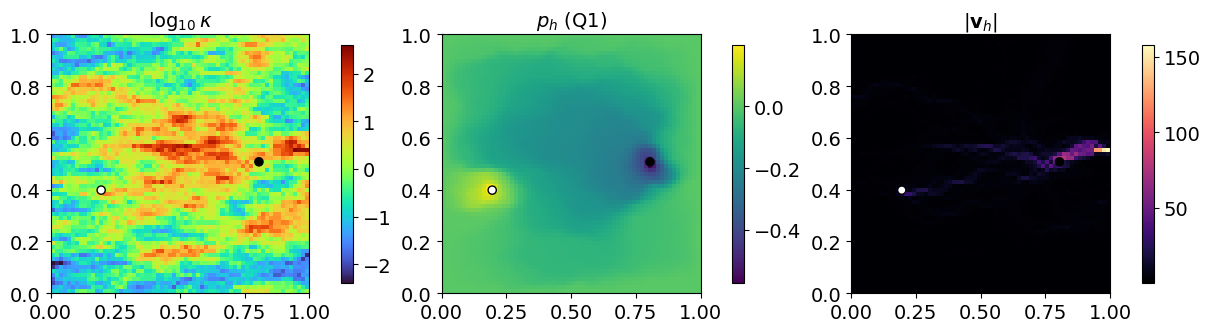

In [2]:
# Tensor-product CG pressure solve with homogeneous Dirichlet boundary and cell-regularized sources.
# Set CG_ORDER = 1 for Q1 or CG_ORDER = 2 for Q2 in the setup cell.
CG_ORDER = int(CG_ORDER)
if CG_ORDER not in (1, 2):
    raise ValueError("CG_ORDER must be 1 or 2 for this notebook.")


def lagrange_1d_values_and_derivatives(nodes, x):
    nodes = np.asarray(nodes, dtype=float).reshape(-1)
    x = np.asarray(x, dtype=float).reshape(-1)
    n = len(nodes)
    vals = np.ones((x.size, n), dtype=float)
    ders = np.zeros((x.size, n), dtype=float)
    if n == 1:
        return vals, ders
    for i in range(n):
        for j in range(n):
            if j != i:
                vals[:, i] *= (x - nodes[j]) / (nodes[i] - nodes[j])
        for k in range(n):
            if k == i:
                continue
            term = np.ones_like(x) / (nodes[i] - nodes[k])
            for j in range(n):
                if j != i and j != k:
                    term *= (x - nodes[j]) / (nodes[i] - nodes[j])
            ders[:, i] += term
    return vals, ders


def tensor_lagrange_values_grads(order, xi_eta, hx_val=1.0, hy_val=1.0):
    xi_eta = np.asarray(xi_eta, dtype=float).reshape(-1, 2)
    nodes_1d = np.linspace(0.0, 1.0, int(order) + 1)
    Lx, dLx = lagrange_1d_values_and_derivatives(nodes_1d, xi_eta[:, 0])
    Ly, dLy = lagrange_1d_values_and_derivatives(nodes_1d, xi_eta[:, 1])
    nd = (int(order) + 1) ** 2
    vals = np.zeros((xi_eta.shape[0], nd), dtype=float)
    grads = np.zeros((xi_eta.shape[0], nd, 2), dtype=float)
    a = 0
    for j in range(int(order) + 1):
        for i in range(int(order) + 1):
            vals[:, a] = Lx[:, i] * Ly[:, j]
            grads[:, a, 0] = (dLx[:, i] / hx_val) * Ly[:, j]
            grads[:, a, 1] = Lx[:, i] * (dLy[:, j] / hy_val)
            a += 1
    return vals, grads


# Compatibility wrappers used by the Q1-only downstream cells.
def q1_phi(xi_eta):
    return tensor_lagrange_values_grads(1, xi_eta, 1.0, 1.0)[0]


def q1_grad_ref(xi_eta):
    return tensor_lagrange_values_grads(1, xi_eta, 1.0, 1.0)[1]


def q1_grad_phys(xi_eta, hx_val, hy_val):
    return tensor_lagrange_values_grads(1, xi_eta, hx_val, hy_val)[1]


nodes_per_axis_x = nx * CG_ORDER + 1
nodes_per_axis_y = ny * CG_ORDER + 1


def _nid(i, j):
    return j * nodes_per_axis_x + i


x_nodes = np.linspace(xmin, xmax, nodes_per_axis_x)
y_nodes = np.linspace(ymin, ymax, nodes_per_axis_y)
Xn, Yn = np.meshgrid(x_nodes, y_nodes, indexing="xy")
fem_nodes = np.column_stack([Xn.ravel(), Yn.ravel()])
n_nodes = fem_nodes.shape[0]

quad_nodes = []
quad_polys = []
for j in range(ny):
    for i in range(nx):
        loc = []
        for jj in range(CG_ORDER + 1):
            for ii in range(CG_ORDER + 1):
                loc.append(_nid(i * CG_ORDER + ii, j * CG_ORDER + jj))
        quad_nodes.append(loc)
        x0, x1 = xmin + i * hx, xmin + (i + 1) * hx
        y0, y1 = ymin + j * hy, ymin + (j + 1) * hy
        quad_polys.append(np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]], dtype=float))
quad_nodes = np.asarray(quad_nodes, dtype=np.int64)
quad_polys = np.asarray(quad_polys, dtype=float)
quad_centroids = xc_matrix.copy()

# Tensor-product Gauss quadrature on [0,1]^2.  The slightly higher order keeps
# the Q2 stiffness/load assembly stable for discontinuous cellwise kappa/source.
quad_order_fe = max(3, 2 * CG_ORDER + 1)
g1d, w1d = np.polynomial.legendre.leggauss(quad_order_fe)
g1d = 0.5 * (g1d + 1.0)
w1d = 0.5 * w1d
_Q_FE = np.array([[gx, gy] for gy in g1d for gx in g1d], dtype=float)
_W_FE = np.array([wx * wy for wy in w1d for wx in w1d], dtype=float)
_Q2 = _Q_FE
_W2 = _W_FE

A = lil_matrix((n_nodes, n_nodes), dtype=float)
b = np.zeros(n_nodes, dtype=float)
cell_area_scalar = hx * hy
phi_q, grads_q = tensor_lagrange_values_grads(CG_ORDER, _Q_FE, hx, hy)
nd_cell = (CG_ORDER + 1) ** 2
for cid, nodes in enumerate(quad_nodes):
    k_elem = float(kappa_cell_dg0[cid])
    Ke = cell_area_scalar * np.einsum("q,qia,qja->ij", _W_FE, k_elem * grads_q, grads_q)
    A[np.ix_(nodes, nodes)] += Ke
    if source_rate_cell[cid] != 0.0:
        f_density = source_rate_cell[cid] / cell_area_scalar
        fe = cell_area_scalar * f_density * np.einsum("q,qi->i", _W_FE, phi_q)
        b[nodes] += fe

boundary_nodes = (
    np.isclose(fem_nodes[:, 0], xmin, atol=1.0e-14)
    | np.isclose(fem_nodes[:, 0], xmax, atol=1.0e-14)
    | np.isclose(fem_nodes[:, 1], ymin, atol=1.0e-14)
    | np.isclose(fem_nodes[:, 1], ymax, atol=1.0e-14)
)
p_dirichlet = np.zeros(n_nodes, dtype=float)

A = A.tolil()
b -= A[:, boundary_nodes].dot(p_dirichlet[boundary_nodes])
for idx in np.flatnonzero(boundary_nodes):
    A.rows[idx] = [int(idx)]
    A.data[idx] = [1.0]
for idx in np.flatnonzero(boundary_nodes):
    A[:, idx] = 0.0
    A[idx, idx] = 1.0
    b[idx] = p_dirichlet[idx]

p_nodes = np.asarray(spsolve(A.tocsr(), b), dtype=float)


def locate_rect_cells(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    xp = np.clip(pts[:, 0], xmin, np.nextafter(xmax, xmin))
    yp = np.clip(pts[:, 1], ymin, np.nextafter(ymax, ymin))
    ix = np.floor((xp - xmin) / hx).astype(int)
    iy = np.floor((yp - ymin) / hy).astype(int)
    ix = np.clip(ix, 0, nx - 1)
    iy = np.clip(iy, 0, ny - 1)
    xi = (pts[:, 0] - (xmin + ix * hx)) / hx
    eta = (pts[:, 1] - (ymin + iy * hy)) / hy
    xi = np.clip(xi, 0.0, 1.0)
    eta = np.clip(eta, 0.0, 1.0)
    cid = iy * nx + ix
    return cid.astype(np.int64), xi, eta


def p_cg_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, xi, eta = locate_rect_cells(pts)
    phi = tensor_lagrange_values_grads(CG_ORDER, np.column_stack([xi, eta]), hx, hy)[0]
    return np.einsum("ni,ni->n", phi, p_nodes[quad_nodes[cid]])


def grad_p_cg_on_rect_cell_numpy(points, cell_ids):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    if len(cids) != len(pts):
        raise ValueError("cell_ids must have the same length as points")
    ix = np.clip(cids % nx, 0, nx - 1)
    iy = np.clip(cids // nx, 0, ny - 1)
    xi = (pts[:, 0] - (xmin + ix * hx)) / hx
    eta = (pts[:, 1] - (ymin + iy * hy)) / hy
    xi = np.clip(xi, 0.0, 1.0)
    eta = np.clip(eta, 0.0, 1.0)
    grads = tensor_lagrange_values_grads(CG_ORDER, np.column_stack([xi, eta]), hx, hy)[1]
    return np.einsum("nld,nl->nd", grads, p_nodes[quad_nodes[cids]])


def grad_p_cg_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, _, _ = locate_rect_cells(pts)
    return grad_p_cg_on_rect_cell_numpy(pts, cid)


def q_cg_on_rect_cell_numpy(points, cell_ids):
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    return -kappa_cell_dg0[cids, None] * grad_p_cg_on_rect_cell_numpy(points, cids)


def q_cg_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, _, _ = locate_rect_cells(pts)
    return q_cg_on_rect_cell_numpy(pts, cid)

p_matrix_cg = p_cg_numpy(xc_matrix)
grad_cell_cg = grad_p_cg_numpy(xc_matrix)
q_cell_cg = -kappa_cell_dg0[:, None] * grad_cell_cg

print(f"Q{CG_ORDER} CG pressure solve")
print(f"  pressure dofs: {n_nodes}, cell dofs: {nd_cell}")
print(f"  p range: [{p_nodes.min():+.6e}, {p_nodes.max():+.6e}]")
print(f"  source integral sum_K int_K f dx = {source_rate_total:+.8e}")
print(f"  source density range: [{source_density_cell.min():+.3e}, {source_density_cell.max():+.3e}]")
if MRST_REFERENCE_AVAILABLE:
    p_matrix_diff_cg_mrst = p_matrix_cg - p_matrix_mrst_export
    print(f"  matched MRST pressure mean|e|={np.mean(np.abs(p_matrix_diff_cg_mrst)):.3e}, max|e|={np.max(np.abs(p_matrix_diff_cg_mrst)):.3e}")


def cell_field_to_grid(field):
    field = np.asarray(field, dtype=float).reshape(-1)
    ix = np.rint((xc_matrix[:, 0] - 0.5 * hx) / hx).astype(int)
    iy = np.rint((xc_matrix[:, 1] - 0.5 * hy) / hy).astype(int)
    grid = np.full((ny, nx), np.nan, dtype=float)
    grid[iy, ix] = field
    return grid

x_edges = np.linspace(xmin, xmax, nx + 1)
y_edges = np.linspace(ymin, ymax, ny + 1)
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), constrained_layout=True)
    pcm0 = axes[0].pcolormesh(x_edges, y_edges, cell_field_to_grid(np.log10(kappa_cell_dg0)), cmap="turbo", shading="flat")
    axes[0].set_title(r"$\log_{10}\kappa$")
    pcm1 = axes[1].pcolormesh(x_edges, y_edges, cell_field_to_grid(p_matrix_cg), cmap="viridis", shading="flat")
    axes[1].set_title(rf"$p_h$ (Q{CG_ORDER})")
    pcm2 = axes[2].pcolormesh(x_edges, y_edges, cell_field_to_grid(np.linalg.norm(q_cell_cg, axis=1)), cmap="magma", shading="flat")
    axes[2].set_title(r"$|\mathbf{v}_h|$")
    for ax in axes:
        ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=35, edgecolors="k", zorder=5)
        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.grid(False)
    fig.colorbar(pcm0, ax=axes[0], fraction=0.046, pad=0.04)
    fig.colorbar(pcm1, ax=axes[1], fraction=0.046, pad=0.04)
    fig.colorbar(pcm2, ax=axes[2], fraction=0.046, pad=0.04)
    plt.show()


Deng Q1 rectangular local solves: 100%|██████████| 4096/4096 [00:16<00:00, 241.79it/s]


Deng/NLR Q1 reconstruction time: 17.65s
Deng/NLR Q1 local conservation on primal cells R_tau:
  CG (interface-averaged): n=4096 mean|R|=7.168217e-03 median|R|=8.541893e-04 rmse=6.621205e-02 max|R|=3.704930e+00 sum(R)=-1.629767e-04
  NLR                  : n=4096 mean|R|=7.168217e-03 median|R|=8.541893e-04 rmse=6.621205e-02 max|R|=3.704930e+00 sum(R)=-1.629767e-04
Deng/NLR Q1 local conservation on nodal dual CVs R_xi:
  CG interior : n=3969 mean|R|=1.511716e-03 median|R|=3.388132e-20 rmse=4.046841e-02 max|R|=1.250000e+00 sum(R)=+4.000000e+00
  NLR interior: n=3969 mean|R|=4.179798e-16 median|R|=2.862294e-17 rmse=1.668014e-15 max|R|=4.047110e-14 sum(R)=+1.331152e-13
  CG source nodes : n=8 mean|R|=7.500000e-01 median|R|=7.500000e-01 rmse=9.013878e-01 max|R|=1.250000e+00 sum(R)=+4.000000e+00
  NLR source nodes: n=8 mean|R|=1.259409e-15 median|R|=8.881784e-16 rmse=1.577954e-15 max|R|=2.664535e-15 sum(R)=-3.191891e-15
  local solve rank range: [3, 3] of 4
  source compatibility max|defect|=

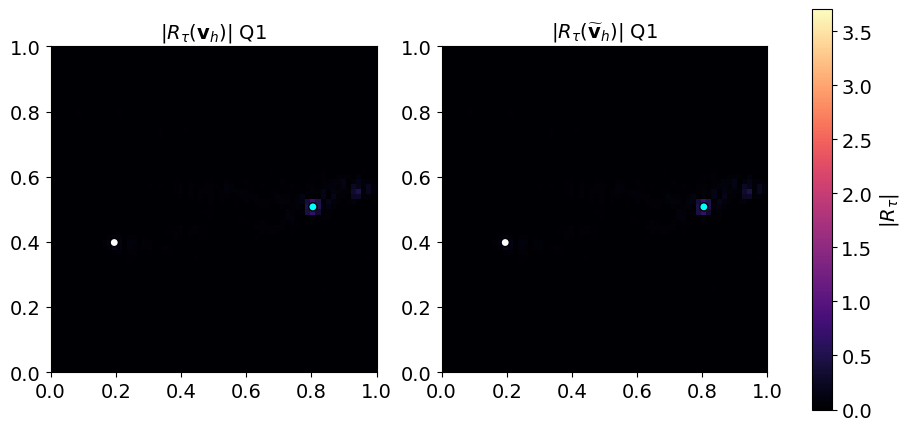

In [3]:
# Deng/Ginting local reconstruction on tensor-product rectangular nodal control volumes.
# Q1: 4 sub-CVs per primal cell.  Q2: 9 sub-CVs per primal cell.
# For Q2 each node-control subcell is bounded by midpoints between neighboring
# Q2 nodes, matching the P2-style centroid/midpoint construction in tensor form.
RUN_DENG_RECONSTRUCTION = True
segment_quad_order = max(3, 2 * CG_ORDER + 1)
_GL, _WL = np.polynomial.legendre.leggauss(segment_quad_order)
_GL = 0.5 * (_GL + 1.0)
_WL = 0.5 * _WL
cell_quad_order = max(3, 2 * CG_ORDER + 1)
_gb, _wb = np.polynomial.legendre.leggauss(cell_quad_order)
_gb = 0.5 * (_gb + 1.0)
_wb = 0.5 * _wb
_QB = np.array([[gx, gy] for gy in _gb for gx in _gb], dtype=float)
_WB = np.array([wx * wy for wy in _wb for wx in _wb], dtype=float)

# Compatibility for the existing Q1 transport cells.
edge_defs = [(0, 1), (1, 3), (3, 2), (2, 0)] if CG_ORDER == 1 else []
next_ccw = {0: 1, 1: 3, 3: 2, 2: 0}
prev_ccw = {0: 2, 2: 3, 3: 1, 1: 0}


def segment_key(a, b, decimals=12):
    ka = tuple(np.round(np.asarray(a, dtype=float), decimals))
    kb = tuple(np.round(np.asarray(b, dtype=float), decimals))
    return tuple(sorted((ka, kb)))


def physical_edge_defs(cell):
    cached = cell.get("physical_edges")
    if cached is not None:
        return cached
    x0, x1 = float(cell["x0"]), float(cell["x1"])
    y0, y1 = float(cell["y0"]), float(cell["y1"])
    edges = [
        ("bottom", np.array([x0, y0], dtype=float), np.array([x1, y0], dtype=float), np.array([0.0, -1.0], dtype=float)),
        ("right",  np.array([x1, y0], dtype=float), np.array([x1, y1], dtype=float), np.array([1.0, 0.0], dtype=float)),
        ("top",    np.array([x0, y1], dtype=float), np.array([x1, y1], dtype=float), np.array([0.0, 1.0], dtype=float)),
        ("left",   np.array([x0, y0], dtype=float), np.array([x0, y1], dtype=float), np.array([-1.0, 0.0], dtype=float)),
    ]
    return [{"side": side, "a": a, "b": b, "normal": n, "key": segment_key(a, b)} for side, a, b, n in edges]


def physical_edge_map(cell):
    cached = cell.get("physical_edge_map")
    if cached is not None:
        return cached
    return {edge["side"]: edge for edge in physical_edge_defs(cell)}


def _node_control_bounds(nodes, idx):
    nodes = np.asarray(nodes, dtype=float)
    idx = int(idx)
    lo = 0.0 if idx == 0 else 0.5 * (nodes[idx - 1] + nodes[idx])
    hi = 1.0 if idx == len(nodes) - 1 else 0.5 * (nodes[idx] + nodes[idx + 1])
    return float(lo), float(hi)


def cv_reference_bounds(cell, gi):
    ix = int(cell["dof_xi_idx"][gi])
    iy = int(cell["dof_eta_idx"][gi])
    xi_l, xi_r = _node_control_bounds(cell["xi_nodes"], ix)
    eta_b, eta_t = _node_control_bounds(cell["eta_nodes"], iy)
    return xi_l, xi_r, eta_b, eta_t


def cv_physical_bounds(cell, gi):
    cached = cell.get("cv_bounds")
    if cached is not None:
        return cached[int(gi)]
    xi_l, xi_r, eta_b, eta_t = cv_reference_bounds(cell, gi)
    x_l = cell["x0"] + xi_l * cell["hx"]
    x_r = cell["x0"] + xi_r * cell["hx"]
    y_b = cell["y0"] + eta_b * cell["hy"]
    y_t = cell["y0"] + eta_t * cell["hy"]
    return float(x_l), float(x_r), float(y_b), float(y_t)


def cv_polygon(cell, gi):
    cached = cell.get("cv_polygons")
    if cached is not None:
        return cached[int(gi)]
    x_l, x_r, y_b, y_t = cv_physical_bounds(cell, gi)
    return np.array([[x_l, y_b], [x_r, y_b], [x_r, y_t], [x_l, y_t]], dtype=float)


# Compatibility aliases for older debug cells.
def standard_cv_polygon(cell, gi):
    return cv_polygon(cell, gi)


def standard_cv_bounds(cell, gi):
    return cv_physical_bounds(cell, gi)


def cv_internal_segments(cell, gi, tol=1.0e-12):
    cached = cell.get("cv_internal_segments")
    if cached is not None:
        return cached[int(gi)]
    xi_l, xi_r, eta_b, eta_t = cv_reference_bounds(cell, gi)
    x_l, x_r, y_b, y_t = cv_physical_bounds(cell, gi)
    segments = []
    if xi_l > tol:
        segments.append((np.array([x_l, y_b], dtype=float), np.array([x_l, y_t], dtype=float), np.array([-1.0, 0.0], dtype=float)))
    if xi_r < 1.0 - tol:
        segments.append((np.array([x_r, y_b], dtype=float), np.array([x_r, y_t], dtype=float), np.array([1.0, 0.0], dtype=float)))
    if eta_b > tol:
        segments.append((np.array([x_l, y_b], dtype=float), np.array([x_r, y_b], dtype=float), np.array([0.0, -1.0], dtype=float)))
    if eta_t < 1.0 - tol:
        segments.append((np.array([x_l, y_t], dtype=float), np.array([x_r, y_t], dtype=float), np.array([0.0, 1.0], dtype=float)))
    return segments


def cv_physical_edge_segments(cell, gi, tol=1.0e-12):
    cached = cell.get("cv_physical_edge_segments")
    if cached is not None:
        return cached[int(gi)]
    xi_l, xi_r, eta_b, eta_t = cv_reference_bounds(cell, gi)
    x_l, x_r, y_b, y_t = cv_physical_bounds(cell, gi)
    edge_map = physical_edge_map(cell)
    segments = []
    if eta_b <= tol and edge_length([x_l, y_b], [x_r, y_b]) > tol:
        edge = edge_map["bottom"]
        segments.append((np.array([x_l, cell["y0"]], dtype=float), np.array([x_r, cell["y0"]], dtype=float), edge["normal"], edge["key"]))
    if eta_t >= 1.0 - tol and edge_length([x_l, y_t], [x_r, y_t]) > tol:
        edge = edge_map["top"]
        segments.append((np.array([x_l, cell["y1"]], dtype=float), np.array([x_r, cell["y1"]], dtype=float), edge["normal"], edge["key"]))
    if xi_l <= tol and edge_length([x_l, y_b], [x_l, y_t]) > tol:
        edge = edge_map["left"]
        segments.append((np.array([cell["x0"], y_b], dtype=float), np.array([cell["x0"], y_t], dtype=float), edge["normal"], edge["key"]))
    if xi_r >= 1.0 - tol and edge_length([x_r, y_b], [x_r, y_t]) > tol:
        edge = edge_map["right"]
        segments.append((np.array([cell["x1"], y_b], dtype=float), np.array([cell["x1"], y_t], dtype=float), edge["normal"], edge["key"]))
    return segments


def _segment_quadrature_points(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return a[None, :] + _GL[:, None] * (b - a)[None, :]


def quad_lagrange_values_grads_on_cell(cell, points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    xi = (pts[:, 0] - cell["x0"]) / cell["hx"]
    eta = (pts[:, 1] - cell["y0"]) / cell["hy"]
    vals, grads = tensor_lagrange_values_grads(cell["pressure_order"], np.column_stack([xi, eta]), cell["hx"], cell["hy"])
    return vals, grads


def segment_flux_basis(cell, a, b, n_out):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    n_out = np.asarray(n_out, dtype=float)
    seg_len = edge_length(a, b)
    if seg_len == 0.0:
        return np.zeros(len(cell["dofs"]), dtype=float)
    _, grads = quad_lagrange_values_grads_on_cell(cell, _segment_quadrature_points(a, b))
    normal_grads = np.einsum("qjd,d->qj", grads, n_out)
    return -cell["kappa"] * seg_len * np.einsum("q,qj->j", _WL, normal_grads)


def segment_flux_coeffs(cell, coeffs, a, b, n_out):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    n_out = np.asarray(n_out, dtype=float)
    seg_len = edge_length(a, b)
    if seg_len == 0.0:
        return 0.0
    _, grads = quad_lagrange_values_grads_on_cell(cell, _segment_quadrature_points(a, b))
    grad = np.einsum("qjd,j->qd", grads, coeffs)
    return float(-cell["kappa"] * seg_len * np.einsum("q,qd,d->", _WL, grad, n_out))


def grad_from_coeffs(cell, coeffs, x):
    pts = np.asarray(x, dtype=float)
    single = pts.ndim == 1
    pts = pts.reshape(-1, 2)
    _, grads = quad_lagrange_values_grads_on_cell(cell, pts)
    grad = np.einsum("qjd,j->qd", grads, coeffs)
    return grad[0] if single else grad


def averaged_kgrad_dot_n(rect, ci, edge_key, x, n_out):
    pts = np.asarray(x, dtype=float)
    single = pts.ndim == 1
    pts = pts.reshape(-1, 2)
    n_out = np.asarray(n_out, dtype=float)
    cell = rect["cells"][ci]
    val = cell["kappa"] * grad_from_coeffs(cell, cell["uvals"], pts)
    adj = [c for c, _ in rect["edge_to_cells"].get(edge_key, [])]
    if len(adj) == 2:
        nb = adj[0] if adj[1] == ci else adj[1]
        nb_cell = rect["cells"][nb]
        val_nb = nb_cell["kappa"] * grad_from_coeffs(nb_cell, nb_cell["uvals"], pts)
        val = 0.5 * (val + val_nb)
    dots = val @ n_out
    return float(dots[0]) if single else dots


def integrate_source_over_subrect(ci, x_l, x_r, y_b, y_t):
    return float(source_density_cell[ci] * max(0.0, x_r - x_l) * max(0.0, y_t - y_b))


def cell_volume_terms(cell):
    x_phys = np.column_stack([
        cell["x0"] + _QB[:, 0] * cell["hx"],
        cell["y0"] + _QB[:, 1] * cell["hy"],
    ])
    vals, grads = quad_lagrange_values_grads_on_cell(cell, x_phys)
    area = cell["hx"] * cell["hy"]
    f_val = float(source_density_cell[cell["cell_id"]])
    grad_u = np.einsum("qjd,j->qd", grads, cell["uvals"])
    source_phi = area * f_val * np.einsum("q,qi->i", _WB, vals)
    a_term = area * np.einsum("q,qjd,qd->j", _WB, cell["kappa"] * grads, grad_u)
    mass_vec = area * np.einsum("q,qi->i", _WB, vals)
    return source_phi, a_term, mass_vec


def prepare_deng_rect_data():
    pressure_order = int(CG_ORDER)
    nodes_1d = np.linspace(0.0, 1.0, pressure_order + 1)
    dof_xi_idx = np.array([i for j in range(pressure_order + 1) for i in range(pressure_order + 1)], dtype=np.int32)
    dof_eta_idx = np.array([j for j in range(pressure_order + 1) for i in range(pressure_order + 1)], dtype=np.int32)

    cells = []
    edge_to_cells = {}
    vtc = [[] for _ in range(n_nodes)]
    for cid, nodes in enumerate(quad_nodes):
        ix = cid % nx
        iy = cid // nx
        x0, x1 = xmin + ix * hx, xmin + (ix + 1) * hx
        y0, y1 = ymin + iy * hy, ymin + (iy + 1) * hy
        cell = {
            "cell_id": int(cid),
            "dofs": nodes.copy(),
            "vids": nodes.copy(),
            "dof_xy": fem_nodes[nodes].copy(),
            "xy": fem_nodes[nodes].copy(),
            "poly": quad_polys[cid].copy(),
            "x0": float(x0),
            "x1": float(x1),
            "y0": float(y0),
            "y1": float(y1),
            "hx": float(hx),
            "hy": float(hy),
            "xi_nodes": nodes_1d.copy(),
            "eta_nodes": nodes_1d.copy(),
            "dof_xi_idx": dof_xi_idx.copy(),
            "dof_eta_idx": dof_eta_idx.copy(),
            "centroid": xc_matrix[cid].copy(),
            "uvals": p_nodes[nodes].copy(),
            "pressure_order": pressure_order,
            "kappa": float(kappa_cell_dg0[cid]),
        }
        cell["physical_edges"] = physical_edge_defs(cell)
        cell["physical_edge_map"] = {edge["side"]: edge for edge in cell["physical_edges"]}
        cells.append(cell)
        for vid in nodes:
            vtc[int(vid)].append(int(cid))
        for edge in cell["physical_edges"]:
            edge_to_cells.setdefault(edge["key"], []).append((int(cid), edge["side"]))

    for cell in cells:
        nd = len(cell["dofs"])
        cell["cv_bounds"] = [cv_physical_bounds(cell, gi) for gi in range(nd)]
        cell["cv_polygons"] = [cv_polygon(cell, gi) for gi in range(nd)]
        cell["cv_internal_segments"] = [cv_internal_segments(cell, gi) for gi in range(nd)]
        cell["cv_physical_edge_segments"] = [cv_physical_edge_segments(cell, gi) for gi in range(nd)]

    return {
        "cells": cells,
        "vertices_xy": fem_nodes.copy(),
        "edge_to_cells": edge_to_cells,
        "vtc": vtc,
        "edge_defs": edge_defs,
        "num_cells": len(cells),
        "num_vertices": n_nodes,
        "pressure_order": pressure_order,
    }


def solve_deng_singular_system(B, rhs, rcond=1.0e-10):
    U, s, Vt = np.linalg.svd(B, full_matrices=False)
    if s.size == 0 or s[0] == 0.0:
        return np.zeros(B.shape[1], dtype=float), 0, s
    keep = s > rcond * s[0]
    coeffs = Vt[keep, :].T @ ((U[:, keep].T @ rhs) / s[keep])
    return coeffs, int(np.count_nonzero(keep)), s


def deng_postprocess_rect_source(rect):
    local_fluxes = {}
    coef_glob = {i: [] for i in range(rect["num_vertices"])}

    for ci in tqdm(range(rect["num_cells"]), desc=f"Deng Q{CG_ORDER} rectangular local solves"):
        cell = rect["cells"][ci]
        nd = len(cell["dofs"])
        B = np.zeros((nd, nd), dtype=float)
        source_t_matrix = np.zeros(nd, dtype=float)
        source_phi_matrix, a_term, mass_vec = cell_volume_terms(cell)
        e_I = np.zeros(nd, dtype=float)
        e_phi = np.zeros(nd, dtype=float)

        for gi in range(nd):
            x_l, x_r, y_b, y_t = cv_physical_bounds(cell, gi)
            source_t_matrix[gi] += integrate_source_over_subrect(ci, x_l, x_r, y_b, y_t)
            for a, b, n_out in cv_internal_segments(cell, gi):
                B[gi, :] += segment_flux_basis(cell, a, b, n_out)

        for edge in physical_edge_defs(cell):
            a = edge["a"]
            b = edge["b"]
            n_out = edge["normal"]
            edge_key = edge["key"]
            seg_len = edge_length(a, b)
            pts = _segment_quadrature_points(a, b)
            phi_edge = quad_lagrange_values_grads_on_cell(cell, pts)[0]
            avg = averaged_kgrad_dot_n(rect, ci, edge_key, pts, n_out)
            e_phi += seg_len * np.einsum("q,q,qi->i", _WL, avg, phi_edge)

        for gi in range(nd):
            for a, b, n_out, edge_key in cv_physical_edge_segments(cell, gi):
                seg_len = edge_length(a, b)
                pts = _segment_quadrature_points(a, b)
                avg = averaged_kgrad_dot_n(rect, ci, edge_key, pts, n_out)
                e_I[gi] += seg_len * float(np.dot(_WL, avg))

        source_t_matrix_raw = source_t_matrix.copy()
        source_defect = float(np.sum(source_phi_matrix) - np.sum(source_t_matrix))
        area = float(np.sum(mass_vec))
        if area > 0.0:
            source_t_matrix += source_defect * mass_vec / area

        source_t = source_t_matrix
        source_phi = source_phi_matrix
        rhs = source_t - source_phi + a_term + e_I - e_phi
        coeffs, local_solve_rank, local_solve_svals = solve_deng_singular_system(B, rhs)
        if area > 0.0:
            coeffs += (float(np.dot(mass_vec, cell["uvals"])) - float(np.dot(mass_vec, coeffs))) / area

        local_fluxes[ci] = {
            "coeffs": coeffs,
            "B": B.copy(),
            "source_t": source_t.copy(),
            "source_phi": source_phi.copy(),
            "source_t_matrix": source_t_matrix.copy(),
            "source_t_matrix_raw": source_t_matrix_raw.copy(),
            "source_compat_defect": source_defect,
            "source_phi_matrix": source_phi_matrix.copy(),
            "rhs": rhs.copy(),
            "local_solve_rank": int(local_solve_rank),
            "local_solve_singular_values": local_solve_svals.copy(),
        }
        for li, vid in enumerate(cell["vids"]):
            coef_glob[int(vid)].append(coeffs[li])

    p_rec = np.zeros(rect["num_vertices"], dtype=float)
    for vid, vals in coef_glob.items():
        p_rec[vid] = float(np.mean(vals)) if vals else np.nan
    return local_fluxes, coef_glob, p_rec


def averaged_physical_outflux(rect, ci, edge_key, a, b, n_out):
    # Deng's CV balance uses the averaged original K grad(p_h).n on primal-cell
    # edges, with Darcy outflux v.n = -K grad(p_h).n.
    seg_len = edge_length(a, b)
    if seg_len == 0.0:
        return 0.0
    pts = _segment_quadrature_points(a, b)
    avg = averaged_kgrad_dot_n(rect, ci, edge_key, pts, n_out)
    return float(-seg_len * np.dot(_WL, avg))


def compute_R_tau_rect(rect, local_fluxes, use_rec=True):
    R = np.zeros(rect["num_cells"], dtype=float)
    for ci, cell in enumerate(rect["cells"]):
        flux = 0.0
        if use_rec:
            for edge in physical_edge_defs(cell):
                flux += averaged_physical_outflux(rect, ci, edge["key"], edge["a"], edge["b"], edge["normal"])
        else:
            for edge in physical_edge_defs(cell):
                flux += segment_flux_coeffs(cell, cell["uvals"], edge["a"], edge["b"], edge["normal"])
        R[ci] = flux - source_rate_cell[ci]
    return R


def compute_R_xi_rect(rect, local_fluxes, use_rec=True):
    R = np.zeros(rect["num_vertices"], dtype=float)
    for vid in range(rect["num_vertices"]):
        flux_sum = 0.0
        source_sum = 0.0
        for ci in rect["vtc"][vid]:
            cell = rect["cells"][ci]
            loc = np.where(cell["vids"] == vid)[0]
            if len(loc) == 0:
                continue
            gi = int(loc[0])
            coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
            for a, b, n_out in cv_internal_segments(cell, gi):
                flux_sum += segment_flux_coeffs(cell, coeffs, a, b, n_out)
            for a, b, n_out, edge_key in cv_physical_edge_segments(cell, gi):
                if use_rec:
                    flux_sum += averaged_physical_outflux(rect, ci, edge_key, a, b, n_out)
                else:
                    flux_sum += segment_flux_coeffs(cell, coeffs, a, b, n_out)
            source_sum += local_fluxes[ci]["source_t"][gi]
        R[vid] = flux_sum - source_sum
    return R


def boundary_vertex_mask_rect(rect, tol=1.0e-12):
    xy = rect["vertices_xy"]
    return (
        np.isclose(xy[:, 0], xmin, atol=tol)
        | np.isclose(xy[:, 0], xmax, atol=tol)
        | np.isclose(xy[:, 1], ymin, atol=tol)
        | np.isclose(xy[:, 1], ymax, atol=tol)
    )


def q_nlr_on_rect_cell_numpy(points, cell_ids):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    if len(cids) != len(pts):
        raise ValueError("cell_ids must have the same length as points")
    out = np.zeros((len(pts), 2), dtype=float)
    for ci in np.unique(cids):
        mask = cids == ci
        cell = rect["cells"][int(ci)]
        coeffs = local_fluxes[int(ci)]["coeffs"]
        out[mask] = -cell["kappa"] * grad_from_coeffs(cell, coeffs, pts[mask])
    return out


def q_nlr_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cids, _, _ = locate_rect_cells(pts)
    return q_nlr_on_rect_cell_numpy(pts, cids)

start = time.time()
rect = prepare_deng_rect_data()
if RUN_DENG_RECONSTRUCTION:
    local_fluxes, coef_glob, p_rec = deng_postprocess_rect_source(rect)
else:
    local_fluxes, coef_glob, p_rec = {}, {}, np.full(rect["num_vertices"], np.nan)
print(f"Deng/NLR Q{CG_ORDER} reconstruction time: {time.time() - start:.2f}s")
p_nlr_nodes = p_rec.copy()

R_tau_cg = compute_R_tau_rect(rect, local_fluxes, use_rec=True)  # raw CG on element interfaces uses the two-sided average
R_tau_nlr = compute_R_tau_rect(rect, local_fluxes, use_rec=True)
R_xi_cg = compute_R_xi_rect(rect, local_fluxes, use_rec=False)
R_xi_nlr = compute_R_xi_rect(rect, local_fluxes, use_rec=True)
boundary_vids = boundary_vertex_mask_rect(rect)
source_vertex_ids = np.unique(np.concatenate([quad_nodes[int(cid)] for cid in source_cell_ids])).astype(np.int64)
interior_vids = ~boundary_vids
interior_vertex_ids = np.flatnonzero(interior_vids)
boundary_vertex_ids = np.flatnonzero(boundary_vids)

print(f"Deng/NLR Q{CG_ORDER} local conservation on primal cells R_tau:")
print("  CG (interface-averaged):", residual_stats(R_tau_cg))
print("  NLR                  :", residual_stats(R_tau_nlr))
print(f"Deng/NLR Q{CG_ORDER} local conservation on nodal dual CVs R_xi:")
print("  CG interior :", residual_stats(R_xi_cg, np.flatnonzero(interior_vids)))
print("  NLR interior:", residual_stats(R_xi_nlr, np.flatnonzero(interior_vids)))
print("  CG source nodes :", residual_stats(R_xi_cg, source_vertex_ids))
print("  NLR source nodes:", residual_stats(R_xi_nlr, source_vertex_ids))
if local_fluxes:
    ranks = np.array([lf.get("local_solve_rank", np.nan) for lf in local_fluxes.values()], dtype=float)
    compat = np.array([lf.get("source_compat_defect", 0.0) for lf in local_fluxes.values()], dtype=float)
    print(f"  local solve rank range: [{np.nanmin(ranks):.0f}, {np.nanmax(ranks):.0f}] of {(CG_ORDER + 1) ** 2}")
    print(f"  source compatibility max|defect|={np.max(np.abs(compat)):.3e}")
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    vmax = max(np.max(np.abs(R_tau_cg)), np.max(np.abs(R_tau_nlr)), 1.0e-14)
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), constrained_layout=True)
    for ax, data, title in zip(axes, [R_tau_cg, R_tau_nlr], [rf"$|R_\tau(\mathbf{{v}}_h)|$ Q{CG_ORDER}", rf"$|R_\tau(\widetilde{{\mathbf{{v}}}}_h)|$ Q{CG_ORDER}"]):
        pcm = ax.pcolormesh(x_edges, y_edges, cell_field_to_grid(np.abs(data)), cmap="magma", shading="flat", vmin=0.0, vmax=vmax)
        ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "cyan"], s=35, edgecolors="k", zorder=5)
        ax.set_title(title)
        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.grid(False)
    cbar = fig.colorbar(pcm, ax=axes, fraction=0.046, pad=0.04)
    cbar.set_label(r"$|R_\tau|$")
    plt.show()


In [4]:
# Vertex-centred CVFEM pressure solve on the active Deng Qk nodal dual control volumes.
# CG_ORDER=1 gives the old Q1 nodal dual mesh; CG_ORDER=2 gives the Q2/P2-style
# dual mesh built from midpoint-bounded sub-CVs around the Q2 nodes.
RUN_CVFEM_SOLVE = bool(globals().get("RUN_CVFEM_SOLVE", True))
CVFEM_ACTIVE = RUN_CVFEM_SOLVE


def assemble_cvfem_pressure_system():
    A_cv = lil_matrix((n_nodes, n_nodes), dtype=float)
    b_cv = np.zeros(n_nodes, dtype=float)
    for ci, cell in enumerate(rect["cells"]):
        nodes = cell["vids"]
        for gi, vid in enumerate(nodes):
            row = int(vid)
            b_cv[row] += local_fluxes[ci]["source_t"][gi]
            for a, bseg, n_out in cv_internal_segments(cell, gi):
                basis = segment_flux_basis(cell, a, bseg, n_out)
                for lid, gid in enumerate(nodes):
                    A_cv[row, int(gid)] += basis[lid]
    return A_cv, b_cv


if CVFEM_ACTIVE:
    A_cvfem, b_cvfem = assemble_cvfem_pressure_system()
    A_cvfem = A_cvfem.tolil()
    b_cvfem -= A_cvfem[:, boundary_nodes].dot(p_dirichlet[boundary_nodes])
    for idx in np.flatnonzero(boundary_nodes):
        A_cvfem.rows[idx] = [int(idx)]
        A_cvfem.data[idx] = [1.0]
    for idx in np.flatnonzero(boundary_nodes):
        A_cvfem[:, idx] = 0.0
        A_cvfem[idx, idx] = 1.0
        b_cvfem[idx] = p_dirichlet[idx]
    p_cvfem_nodes = np.asarray(spsolve(A_cvfem.tocsr(), b_cvfem), dtype=float)
else:
    A_cvfem = None
    b_cvfem = None
    p_cvfem_nodes = np.full(n_nodes, np.nan, dtype=float)


def p_cvfem_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, xi, eta = locate_rect_cells(pts)
    phi = tensor_lagrange_values_grads(CG_ORDER, np.column_stack([xi, eta]), hx, hy)[0]
    return np.einsum("ni,ni->n", phi, p_cvfem_nodes[quad_nodes[cid]])


def grad_p_cvfem_on_rect_cell_numpy(points, cell_ids):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    ix = np.clip(cids % nx, 0, nx - 1)
    iy = np.clip(cids // nx, 0, ny - 1)
    xi = (pts[:, 0] - (xmin + ix * hx)) / hx
    eta = (pts[:, 1] - (ymin + iy * hy)) / hy
    xi = np.clip(xi, 0.0, 1.0)
    eta = np.clip(eta, 0.0, 1.0)
    grads = tensor_lagrange_values_grads(CG_ORDER, np.column_stack([xi, eta]), hx, hy)[1]
    return np.einsum("nld,nl->nd", grads, p_cvfem_nodes[quad_nodes[cids]])


def grad_p_cvfem_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, _, _ = locate_rect_cells(pts)
    return grad_p_cvfem_on_rect_cell_numpy(pts, cid)


def q_cvfem_on_rect_cell_numpy(points, cell_ids):
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    return -kappa_cell_dg0[cids, None] * grad_p_cvfem_on_rect_cell_numpy(points, cids)


def q_cvfem_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, _, _ = locate_rect_cells(pts)
    return q_cvfem_on_rect_cell_numpy(pts, cid)


def compute_R_tau_coeffs_rect(rect, local_fluxes_like):
    R = np.zeros(rect["num_cells"], dtype=float)
    for ci, cell in enumerate(rect["cells"]):
        coeffs = local_fluxes_like[ci]["coeffs"]
        flux = 0.0
        for edge in physical_edge_defs(cell):
            flux += segment_flux_coeffs(cell, coeffs, edge["a"], edge["b"], edge["normal"])
        R[ci] = flux - source_rate_cell[ci]
    return R


if CVFEM_ACTIVE:
    p_matrix_cvfem = p_cvfem_numpy(xc_matrix)
    grad_cell_cvfem = grad_p_cvfem_numpy(xc_matrix)
    q_cell_cvfem = -kappa_cell_dg0[:, None] * grad_cell_cvfem
    local_fluxes_cvfem = {
        ci: {
            "coeffs": p_cvfem_nodes[cell["vids"]].copy(),
            "source_t": local_fluxes[ci]["source_t"].copy(),
        }
        for ci, cell in enumerate(rect["cells"])
    }
    R_tau_cvfem = compute_R_tau_coeffs_rect(rect, local_fluxes_cvfem)
    R_xi_cvfem = compute_R_xi_rect(rect, local_fluxes_cvfem, use_rec=True)

    print(f"CVFEM Q{CG_ORDER} pressure solve on nodal dual control volumes")
    print(f"  p range: [{p_cvfem_nodes.min():+.6e}, {p_cvfem_nodes.max():+.6e}]")
    print(f"  mean|p_CVFEM-p_CG|={np.mean(np.abs(p_matrix_cvfem - p_matrix_cg)):.3e}, max|p_CVFEM-p_CG|={np.max(np.abs(p_matrix_cvfem - p_matrix_cg)):.3e}")
    if MRST_REFERENCE_AVAILABLE:
        p_matrix_diff_cvfem_mrst = p_matrix_cvfem - p_matrix_mrst_export
        print(f"  matched MRST pressure mean|e|={np.mean(np.abs(p_matrix_diff_cvfem_mrst)):.3e}, max|e|={np.max(np.abs(p_matrix_diff_cvfem_mrst)):.3e}")
    print("  CVFEM conservation residuals")
    print("    R_tau CVFEM       :", residual_stats(R_tau_cvfem))
    print("    R_xi CVFEM int    :", residual_stats(R_xi_cvfem, interior_vertex_ids))
    print("    R_xi CVFEM source :", residual_stats(R_xi_cvfem, source_vertex_ids))
else:
    p_matrix_cvfem = np.full(ncell, np.nan, dtype=float)
    grad_cell_cvfem = np.full((ncell, 2), np.nan, dtype=float)
    q_cell_cvfem = np.full((ncell, 2), np.nan, dtype=float)
    local_fluxes_cvfem = {}
    R_tau_cvfem = np.full(ncell, np.nan, dtype=float)
    R_xi_cvfem = np.full(n_nodes, np.nan, dtype=float)
    print("CVFEM pressure solve skipped by RUN_CVFEM_SOLVE=False.")


CVFEM Q1 pressure solve on nodal dual control volumes
  p range: [-6.575262e-01, +2.455256e-01]
  mean|p_CVFEM-p_CG|=5.021e-04, max|p_CVFEM-p_CG|=9.286e-03
  matched MRST pressure mean|e|=7.490e-03, max|e|=2.993e-01
  CVFEM conservation residuals
    R_tau CVFEM       : n=4096 mean|R|=1.464844e-03 median|R|=0.000000e+00 rmse=7.967218e-02 max|R|=5.000000e+00 sum(R)=+4.000000e+00
    R_xi CVFEM int    : n=3969 mean|R|=3.985212e-16 median|R|=2.818926e-17 rmse=1.545639e-15 max|R|=2.944867e-14 sum(R)=-1.638879e-13
    R_xi CVFEM source : n=8 mean|R|=9.194034e-16 median|R|=3.885781e-16 rmse=1.426141e-15 max|R|=3.108624e-15 sum(R)=-5.800915e-15


In [5]:
# Rectangular-grid face flux diagnostic only.  The Deng transport below uses the nodal dual mesh C_z.
n1 = face_neighbors[:, 0].astype(int)
n2 = face_neighbors[:, 1].astype(int)
is_internal_face = (n1 > 0) & (n2 > 0)
is_boundary_face = ~is_internal_face

owner_int = n1[is_internal_face] - 1
neigh_int = n2[is_internal_face] - 1
owner_b = np.maximum(n1[is_boundary_face], n2[is_boundary_face]) - 1
sgn_b = np.ones(np.count_nonzero(is_boundary_face), dtype=float)
sgn_b[n1[is_boundary_face] == 0] = -1.0

owner = np.concatenate([owner_int, owner_b]).astype(int)
neigh = np.concatenate([neigh_int, -np.ones_like(owner_b)]).astype(int)
has_neighbor = neigh >= 0
is_boundary_conn = ~has_neighbor
inlet_s = np.full(owner.shape, BOUNDARY_INFLOW_S, dtype=float)


def global_face_flux_to_fout(global_face_flux):
    global_face_flux = np.asarray(global_face_flux, dtype=float).reshape(-1)
    return np.concatenate([
        global_face_flux[is_internal_face],
        global_face_flux[is_boundary_face] * sgn_b,
    ]).astype(float)


def _face_quadrature(n_quad=2):
    if n_quad == 1:
        return np.array([0.5], dtype=float), np.array([1.0], dtype=float)
    xi, wi = np.polynomial.legendre.leggauss(n_quad)
    return 0.5 * (xi + 1.0), 0.5 * wi


def face_global_flux_from_cell_velocity(velocity_on_cell_fn, n_quad=2, average_internal=True):
    xi, wi = _face_quadrature(n_quad)
    flux = np.zeros(face_len.size, dtype=float)
    edge = face_p2 - face_p1
    cell1 = face_neighbors[:, 0].astype(np.int64) - 1
    cell2 = face_neighbors[:, 1].astype(np.int64) - 1
    internal = (cell1 >= 0) & (cell2 >= 0)
    owner_cell = np.maximum(cell1, cell2)
    for s, w in zip(xi, wi):
        pts = face_p1 + s * edge
        vel = np.zeros_like(pts)
        if np.any(internal):
            q1v = velocity_on_cell_fn(pts[internal], cell1[internal])
            if average_internal:
                q2v = velocity_on_cell_fn(pts[internal], cell2[internal])
                vel[internal] = 0.5 * (q1v + q2v)
            else:
                vel[internal] = q1v
        if np.any(~internal):
            vel[~internal] = velocity_on_cell_fn(pts[~internal], owner_cell[~internal])
        flux += w * face_len * np.einsum("ij,ij->i", vel, face_normal)
    return flux


def face_global_flux_from_gradient_harmonic(gradient_fn, n_quad=2):
    xi, wi = _face_quadrature(n_quad)
    flux = np.zeros(face_len.size, dtype=float)
    edge = face_p2 - face_p1
    cell1 = face_neighbors[:, 0].astype(np.int64) - 1
    cell2 = face_neighbors[:, 1].astype(np.int64) - 1
    internal = (cell1 >= 0) & (cell2 >= 0)
    owner_cell = np.maximum(cell1, cell2)
    k_face = np.empty(face_len.size, dtype=float)
    k_face[internal] = harmonic_mean(kappa_cell_dg0[cell1[internal]], kappa_cell_dg0[cell2[internal]])
    k_face[~internal] = kappa_cell_dg0[owner_cell[~internal]]
    for s, w in zip(xi, wi):
        pts = face_p1 + s * edge
        grad = gradient_fn(pts)
        vel = -k_face[:, None] * grad
        flux += w * face_len * np.einsum("ij,ij->i", vel, face_normal)
    return flux

face_flux_cg_global = face_global_flux_from_cell_velocity(q_cg_on_rect_cell_numpy, n_quad=2, average_internal=True)
face_flux_nlr_global = face_global_flux_from_cell_velocity(q_nlr_on_rect_cell_numpy, n_quad=2, average_internal=True)
face_flux_cvfem_global = face_global_flux_from_cell_velocity(q_cvfem_on_rect_cell_numpy, n_quad=2, average_internal=True)
face_flux_pinn_global = None

Fout_CG = global_face_flux_to_fout(face_flux_cg_global)
Fout_NLR = global_face_flux_to_fout(face_flux_nlr_global)
Fout_CVFEM = global_face_flux_to_fout(face_flux_cvfem_global)
transport_fluxes = {"CG": Fout_CG, "NLR": Fout_NLR, "CVFEM": Fout_CVFEM}
face_flux_by_method = {"CG": face_flux_cg_global, "NLR": face_flux_nlr_global, "CVFEM": face_flux_cvfem_global}
if PINN_ACTIVE:
    face_flux_pinn_global = face_global_flux_from_gradient_harmonic(grad_rec_numpy, n_quad=2)
    Fout_PINN = global_face_flux_to_fout(face_flux_pinn_global)
    transport_fluxes["PINN"] = Fout_PINN
    face_flux_by_method["PINN"] = face_flux_pinn_global
else:
    print("PINN rectangular-face diagnostic skipped.")
if MRST_REFERENCE_AVAILABLE:
    Fout_MRST = global_face_flux_to_fout(face_flux_mrst_export)
    transport_fluxes["MRST"] = Fout_MRST
    face_flux_by_method["MRST"] = face_flux_mrst_export


def cell_single_phase_residual(Fout):
    residual = np.zeros(ncell, dtype=float)
    np.add.at(residual, owner, Fout)
    np.add.at(residual, neigh[has_neighbor], -Fout[has_neighbor])
    return residual - source_rate_cell

print("Rectangular-cell diagnostic only (not the Deng transport CV): sum outward face flux minus cell source int_K f:")
for name, Fout in transport_fluxes.items():
    r = cell_single_phase_residual(Fout)
    print(f"  {name:<5} {residual_stats(r)}")
if MRST_REFERENCE_AVAILABLE:
    print("Face-flux comparison relative to matched MRST/TPFA:")
    for name, Fout in transport_fluxes.items():
        err = Fout - Fout_MRST
        print(f"  {name:<5} mean|F-F_FV|={np.mean(np.abs(err)):.3e}, rmse={np.sqrt(np.mean(err**2)):.3e}, max|F-F_FV|={np.max(np.abs(err)):.3e}")

print("Boundary single-phase flux audit, signed outward sums:")
_boundary_masks = {
    "left": is_boundary_face & np.isclose(face_centroid[:, 0], xmin, atol=1.0e-12),
    "right": is_boundary_face & np.isclose(face_centroid[:, 0], xmax, atol=1.0e-12),
    "bottom": is_boundary_face & np.isclose(face_centroid[:, 1], ymin, atol=1.0e-12),
    "top": is_boundary_face & np.isclose(face_centroid[:, 1], ymax, atol=1.0e-12),
}
for side, mask in _boundary_masks.items():
    row = [f"  {side:<6}"]
    for name, flux in face_flux_by_method.items():
        row.append(f"{name} sum={np.sum(flux[mask]):+.3e}")
    print("; ".join(row))


PINN rectangular-face diagnostic skipped.
Rectangular-cell diagnostic only (not the Deng transport CV): sum outward face flux minus cell source int_K f:
  CG    n=4096 mean|R|=7.168217e-03 median|R|=8.541893e-04 rmse=6.621205e-02 max|R|=3.704930e+00 sum(R)=-1.629767e-04
  NLR   n=4096 mean|R|=7.254231e-03 median|R|=8.871654e-04 rmse=6.709944e-02 max|R|=3.760428e+00 sum(R)=-1.222325e-04
  CVFEM n=4096 mean|R|=7.325801e-03 median|R|=9.003179e-04 rmse=6.728260e-02 max|R|=3.769217e+00 sum(R)=-1.167133e-04
  MRST  n=4096 mean|R|=3.916778e-16 median|R|=2.233456e-17 rmse=1.785584e-15 max|R|=4.947431e-14 sum(R)=+1.727400e-13
Face-flux comparison relative to matched MRST/TPFA:
  CG    mean|F-F_FV|=3.023e-03, rmse=2.410e-02, max|F-F_FV|=1.326e+00
  NLR   mean|F-F_FV|=3.049e-03, rmse=2.449e-02, max|F-F_FV|=1.358e+00
  CVFEM mean|F-F_FV|=3.080e-03, rmse=2.460e-02, max|F-F_FV|=1.364e+00
  MRST  mean|F-F_FV|=0.000e+00, rmse=0.000e+00, max|F-F_FV|=0.000e+00
Boundary single-phase flux audit, signed ou

MRST transport is not included on this Deng nodal dual mesh unless a matching MRST dual export is loaded in the plotting cell.
Aggregated Deng P1 transport interfaces: 8580 from 16896 subfaces
Matched MRST dual-volume interfaces: 8580 / 8580
Aggregated P1 dual-volume flux error, int_e (v_w-v_FV).n ds:
  method        total L2      relL2      mean|e|        RMSE       max|e|
  CG       3.203079e-01  4.849e-02   9.3195e-04  3.4580e-03  6.6822e-02
  NLR      2.634960e-01  3.989e-02   8.1839e-04  2.8447e-03  4.9819e-02
  CVFEM    2.637928e-01  3.994e-02   8.3531e-04  2.8479e-03  4.8172e-02


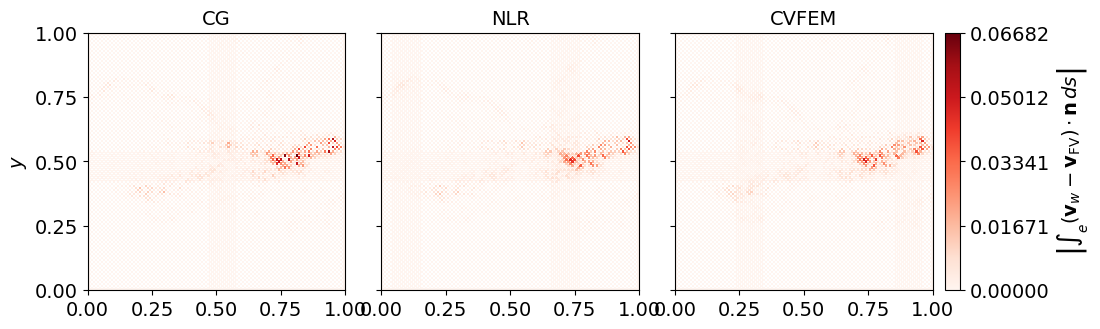

Deng Q1 nodal-dual single-phase balance, sum outward dual-face flux minus source:
  CG    all=n=4225 mean|R|=1.419603e-03 median|R|=2.244439e-04 rmse=5.838860e-03 max|R|=1.089557e-01 sum(R)=-1.629767e-04
        interior=n=3969 mean|R|=1.492500e-03 median|R|=2.516022e-04 rmse=6.015772e-03 max|R|=1.089557e-01 sum(R)=-4.074418e-05
  NLR   all=n=4225 mean|R|=1.839002e-05 median|R|=3.556183e-17 rmse=3.327835e-04 max|R|=1.434723e-02 sum(R)=-1.222325e-04
        interior=n=3969 mean|R|=4.178256e-16 median|R|=2.862294e-17 rmse=1.668433e-15 max|R|=4.045722e-14 sum(R)=+1.331863e-13
  CVFEM all=n=4225 mean|R|=1.637805e-05 median|R|=3.599551e-17 rmse=3.056673e-04 max|R|=1.307857e-02 sum(R)=-1.167133e-04
        interior=n=3969 mean|R|=3.984334e-16 median|R|=2.862294e-17 rmse=1.545874e-15 max|R|=2.944867e-14 sum(R)=-1.633054e-13


In [6]:
# Deng dual-volume flux assembly + MRST transport-flux error diagnostic.
# This is the transport mesh for which the Deng/NLR reconstruction is locally conservative.
from matplotlib.colors import Normalize
RUN_DUAL_TRANSPORT = bool(globals().get("RUN_DUAL_TRANSPORT", True))
dual_nx_nodes = nodes_per_axis_x
dual_ny_nodes = nodes_per_axis_y
dual_shape = (dual_ny_nodes, dual_nx_nodes)


def fractional_flow_bl(S):
    S = np.asarray(S, dtype=float)
    return S ** 2 / (S ** 2 + (1.0 - S) ** 2 + 1.0e-30)


def segment_flux_velocity_fn(velocity_fn, a, bpt, n_out):
    a = np.asarray(a, dtype=float)
    bpt = np.asarray(bpt, dtype=float)
    seg_len = edge_length(a, bpt)
    flux = 0.0
    for t, w in zip(_GL, _WL):
        x = a + t * (bpt - a)
        vel = velocity_fn(x[None, :])[0]
        flux += w * float(np.dot(vel, n_out)) * seg_len
    return float(flux)


def _local_index_map(cell):
    return {
        (int(cell["dof_xi_idx"][gi]), int(cell["dof_eta_idx"][gi])): int(gi)
        for gi in range(len(cell["vids"]))
    }


def _neighbor_gi_from_normal(cell, gi, n_out):
    ix = int(cell["dof_xi_idx"][gi])
    iy = int(cell["dof_eta_idx"][gi])
    if n_out[0] < -0.5:
        key = (ix - 1, iy)
    elif n_out[0] > 0.5:
        key = (ix + 1, iy)
    elif n_out[1] < -0.5:
        key = (ix, iy - 1)
    elif n_out[1] > 0.5:
        key = (ix, iy + 1)
    else:
        raise ValueError("Axis-aligned Qk dual segment normal expected.")
    return _local_index_map(cell)[key]


dual_pv = np.zeros(n_nodes, dtype=float)
dual_source_rate = np.zeros(n_nodes, dtype=float)
for ci, cell in enumerate(rect["cells"]):
    for gi, vid in enumerate(cell["vids"]):
        x_l, x_r, y_b, y_t = cv_physical_bounds(cell, gi)
        subarea = max(0.0, x_r - x_l) * max(0.0, y_t - y_b)
        dual_pv[int(vid)] += phi_matrix * subarea
        dual_source_rate[int(vid)] += local_fluxes[ci]["source_t"][gi]

dual_owner = []
dual_neigh = []
dual_face_p1 = []
dual_face_p2 = []
dual_face_centroid = []
dual_face_normal = []
dual_flux_by_method = {"CG": [], "NLR": []}
if CVFEM_ACTIVE:
    dual_flux_by_method["CVFEM"] = []
# Hard-curl PINN is added in the next cell after training on these CG dual fluxes.

for ci, cell in enumerate(rect["cells"]):
    coeffs_by_method = {"CG": cell["uvals"], "NLR": local_fluxes[ci]["coeffs"]}
    if CVFEM_ACTIVE:
        coeffs_by_method["CVFEM"] = p_cvfem_nodes[cell["vids"]]

    for gi, vid in enumerate(cell["vids"]):
        owner_vid = int(vid)
        for a, bseg, n_out in cv_internal_segments(cell, gi):
            gj = _neighbor_gi_from_normal(cell, gi, n_out)
            neigh_vid = int(cell["vids"][gj])
            if owner_vid > neigh_vid:
                continue
            dual_owner.append(owner_vid)
            dual_neigh.append(neigh_vid)
            dual_face_p1.append(np.asarray(a, dtype=float).copy())
            dual_face_p2.append(np.asarray(bseg, dtype=float).copy())
            dual_face_centroid.append(0.5 * (np.asarray(a, dtype=float) + np.asarray(bseg, dtype=float)))
            dual_face_normal.append(np.asarray(n_out, dtype=float).copy())
            for name, coeffs in coeffs_by_method.items():
                dual_flux_by_method[name].append(segment_flux_coeffs(cell, coeffs, a, bseg, n_out))

        for a, bseg, n_out, edge_key in cv_physical_edge_segments(cell, gi):
            if len(rect["edge_to_cells"].get(edge_key, [])) != 1:
                continue
            dual_owner.append(owner_vid)
            dual_neigh.append(-1)
            dual_face_p1.append(np.asarray(a, dtype=float).copy())
            dual_face_p2.append(np.asarray(bseg, dtype=float).copy())
            dual_face_centroid.append(0.5 * (np.asarray(a, dtype=float) + np.asarray(bseg, dtype=float)))
            dual_face_normal.append(np.asarray(n_out, dtype=float).copy())
            for name, coeffs in coeffs_by_method.items():
                dual_flux_by_method[name].append(segment_flux_coeffs(cell, coeffs, a, bseg, n_out))

dual_owner = np.asarray(dual_owner, dtype=np.int64)
dual_neigh = np.asarray(dual_neigh, dtype=np.int64)
dual_face_p1 = np.asarray(dual_face_p1, dtype=float).reshape(-1, 2)
dual_face_p2 = np.asarray(dual_face_p2, dtype=float).reshape(-1, 2)
dual_face_centroid = np.asarray(dual_face_centroid, dtype=float).reshape(-1, 2)
dual_face_normal = np.asarray(dual_face_normal, dtype=float).reshape(-1, 2)
dual_has_neighbor = dual_neigh >= 0
dual_is_boundary = ~dual_has_neighbor
dual_flux_by_method = {name: np.asarray(vals, dtype=float) for name, vals in dual_flux_by_method.items()}
if "MRST" in transport_fluxes:
    print("MRST transport is not included on this Deng nodal dual mesh unless a matching MRST dual export is loaded in the plotting cell.")

# Matched MRST comparison for the actual dual-volume fluxes used below.
# The P2 Deng CV boundary is stored as element-local subfaces.  MRST exports one
# flux per dual-volume interface, so aggregate subfaces with the same owner/neigh
# pair before subtracting the FV flux.
active_dual_face_flux_error = {}
active_dual_face_flux_error_l2 = {}
mrst_dual_flux_on_transport_faces = None
_transport_face_len = np.linalg.norm(dual_face_p2 - dual_face_p1, axis=1)
def _dual_boundary_side(pt, tol=1.0e-12):
    x, y = float(pt[0]), float(pt[1])
    if abs(x - xmin) <= tol:
        return "L"
    if abs(x - xmax) <= tol:
        return "R"
    if abs(y - ymin) <= tol:
        return "B"
    if abs(y - ymax) <= tol:
        return "T"
    return "?"

def _dual_interface_key(owner, neigh, centroid):
    owner = int(owner)
    neigh = int(neigh)
    if neigh >= 0:
        return (owner, neigh)
    return (owner, -1, _dual_boundary_side(centroid))

_agg_index = {}
_agg_owner = []
_agg_neigh = []
_agg_len = []
_agg_centroid_num = []
_agg_flux_by_method = {name: [] for name in dual_flux_by_method}
for _i, (_owner, _neigh) in enumerate(zip(dual_owner, dual_neigh)):
    _key = _dual_interface_key(_owner, _neigh, dual_face_centroid[_i])
    _j = _agg_index.get(_key)
    if _j is None:
        _j = len(_agg_owner)
        _agg_index[_key] = _j
        _agg_owner.append(_key[0])
        _agg_neigh.append(_key[1])
        _agg_len.append(0.0)
        _agg_centroid_num.append(np.zeros(2, dtype=float))
        for _name in dual_flux_by_method:
            _agg_flux_by_method[_name].append(0.0)
    _seg_len = float(_transport_face_len[_i])
    _agg_len[_j] += _seg_len
    _agg_centroid_num[_j] += _seg_len * dual_face_centroid[_i]
    for _name, _Fout in dual_flux_by_method.items():
        _agg_flux_by_method[_name][_j] += float(_Fout[_i])

_agg_keys = list(_agg_index.keys())
_agg_owner = np.asarray(_agg_owner, dtype=np.int64)
_agg_neigh = np.asarray(_agg_neigh, dtype=np.int64)
_agg_len = np.asarray(_agg_len, dtype=float)
_agg_centroid = np.vstack(_agg_centroid_num) / np.maximum(_agg_len[:, None], 1.0e-300)
_agg_flux_by_method = {name: np.asarray(vals, dtype=float) for name, vals in _agg_flux_by_method.items()}
print(f"Aggregated Deng P{CG_ORDER} transport interfaces: {len(_agg_owner)} from {len(dual_owner)} subfaces")

_mrst_dual_transport_flux_available = MRST_FINE_AVAILABLE and all(key in mrst_fine for key in ["face_flux", "face_neighbors", "face_centroid"])
if _mrst_dual_transport_flux_available:
    _mrst_face_flux = np.asarray(mrst_fine["face_flux"], dtype=float).reshape(-1)
    _mrst_face_neighbors = np.asarray(mrst_fine["face_neighbors"], dtype=np.int64).reshape(-1, 2)
    _mrst_face_centroid = np.asarray(mrst_fine["face_centroid"], dtype=float).reshape(-1, 2)
    _lookup = {}
    _duplicate_keys = 0
    for _F, (_nbr, _ctr) in enumerate(zip(_mrst_face_neighbors, _mrst_face_centroid)):
        _a, _b = _nbr
        _c1 = int(_a) - 1 if int(_a) > 0 else -1
        _c2 = int(_b) - 1 if int(_b) > 0 else -1
        if _c1 < 0 and _c2 < 0:
            continue
        _flux_val = float(_mrst_face_flux[_F])
        if _c1 >= 0 and _c2 >= 0:
            _items = [((_c1, _c2), _flux_val), ((_c2, _c1), -_flux_val)]
        elif _c1 >= 0:
            _items = [(_dual_interface_key(_c1, -1, _ctr), _flux_val)]
        else:
            _items = [(_dual_interface_key(_c2, -1, _ctr), -_flux_val)]
        for _key, _val in _items:
            if _key in _lookup and not np.isclose(_lookup[_key], _val, rtol=1.0e-10, atol=1.0e-12):
                _duplicate_keys += 1
            _lookup[_key] = _val
    mrst_dual_flux_on_transport_faces = np.full(len(_agg_owner), np.nan, dtype=float)
    for _i, (_owner, _neigh) in enumerate(zip(_agg_owner, _agg_neigh)):
        mrst_dual_flux_on_transport_faces[_i] = _lookup.get(_agg_keys[_i], np.nan)
    _matched = np.isfinite(mrst_dual_flux_on_transport_faces)
    print(f"Matched MRST dual-volume interfaces: {np.count_nonzero(_matched)} / {len(_agg_owner)}" + (f", duplicate orientation keys={_duplicate_keys}" if _duplicate_keys else ""))
    if np.any(_matched):
        _mrst_flux_l2 = float(np.sqrt(np.sum(mrst_dual_flux_on_transport_faces[_matched] ** 2)))
        print(rf"Aggregated P{CG_ORDER} dual-volume flux error, int_e (v_w-v_FV).n ds:")
        print("  method        total L2      relL2      mean|e|        RMSE       max|e|")
        for _name in [m for m in ["CG", "NLR", "CVFEM", "PINN"] if m in _agg_flux_by_method]:
            _err = _agg_flux_by_method[_name][_matched] - mrst_dual_flux_on_transport_faces[_matched]
            active_dual_face_flux_error[_name] = np.full(len(_agg_owner), np.nan, dtype=float)
            active_dual_face_flux_error[_name][_matched] = _err
            _l2 = float(np.sqrt(np.sum(_err ** 2)))
            active_dual_face_flux_error_l2[_name] = _l2
            _rel = _l2 / max(_mrst_flux_l2, 1.0e-300)
            print(f"  {_name:<6} {_l2:14.6e} {_rel:10.3e} {np.mean(np.abs(_err)):12.4e} {np.sqrt(np.mean(_err**2)):11.4e} {np.max(np.abs(_err)):11.4e}")
        _plot_order = [m for m in ["CG", "NLR", "CVFEM", "PINN"] if m in active_dual_face_flux_error]
        if _plot_order:
            _vmax = max(float(np.nanmax(np.abs(active_dual_face_flux_error[m]))) for m in _plot_order)
            _vmax = _vmax if np.isfinite(_vmax) and _vmax > 0.0 else 1.0e-14
            _norm = Normalize(vmin=0.0, vmax=_vmax)
            with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
                fig, axes = plt.subplots(1, len(_plot_order), figsize=(max(10.0, 3.25 * len(_plot_order)), 4.5), squeeze=False)
                axes = axes[0]
                _mappable = None
                for ax, _name in zip(axes, _plot_order):
                    _mappable = ax.scatter(
                        _agg_centroid[_matched, 0],
                        _agg_centroid[_matched, 1],
                        c=np.abs(active_dual_face_flux_error[_name][_matched]),
                        s=2.5,
                        marker="s",
                        cmap="Reds",
                        norm=_norm,
                        linewidths=0.0,
                        rasterized=True,
                    )
                    ax.set_title(_name)
                    ax.set_aspect("equal")
                    ax.set_xlim(xmin, xmax)
                    ax.set_ylim(ymin, ymax)
                    ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
                    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
                    ax.grid(False)
                axes[0].set_ylabel(r"$y$")
                for ax in axes[1:]:
                    ax.tick_params(labelleft=False)
                fig.subplots_adjust(left=0.055, right=0.90, bottom=0.08, top=0.90, wspace=0.14)
                fig.canvas.draw()
                _pos = axes[-1].get_position()
                _cax = fig.add_axes([_pos.x1 + 0.012, _pos.y0, 0.015, _pos.height])
                _cbar = fig.colorbar(_mappable, cax=_cax)
                _cbar.set_label(r"$\left|\int_e (\mathbf{v}_w-\mathbf{v}_{\mathrm{FV}})\cdot\mathbf{n}\,ds\right|$")
                _cbar.set_ticks(np.linspace(0.0, _vmax, 5))
                plt.show()
    else:
        print("MRST dual-volume face fluxes were present, but no transport interfaces could be matched by neighbor ids.")
else:
    print("Matching MRST dual-volume face flux data are unavailable; skipping actual transport-face flux comparison.")


def dual_single_phase_residual(Fout):
    residual = np.zeros(n_nodes, dtype=float)
    np.add.at(residual, dual_owner, Fout)
    np.add.at(residual, dual_neigh[dual_has_neighbor], -Fout[dual_has_neighbor])
    return residual - dual_source_rate

print(f"Deng Q{CG_ORDER} nodal-dual single-phase balance, sum outward dual-face flux minus source:")
for name, Fout in dual_flux_by_method.items():
    r = dual_single_phase_residual(Fout)
    print(f"  {name:<5} all={residual_stats(r)}")
    print(f"        interior={residual_stats(r, interior_vertex_ids)}")



In [7]:
# Hard-conservative stream-function PINN trained on Deng Q1 dual-volume CG face fluxes.
# q_theta = q_p + curl(psi_theta), with curl(psi)=(psi_y, -psi_x).
# Training is unweighted L2 projection of integrated dual-face fluxes onto the CG dual flux.
ENABLE_HARD_CURL_PINN = True
HARD_PINN_LOAD_CHECKPOINT = True  # load saved weights if the checkpoint exists; set False to force retraining
HARD_PINN_EPOCHS = 5000
HARD_PINN_LR = 2.0e-3
HARD_PINN_HIDDEN_DIM = 96
HARD_PINN_DEPTH = 4
HARD_PINN_FOURIER_FREQS = np.array([1, 2, 4, 8, 16, 32], dtype=float)
HARD_PINN_USE_LOGK = True
HARD_PINN_USE_RELATIVE_WEIGHTS = False
HARD_PINN_LBFGS_POLISH = True
HARD_PINN_LBFGS_MAX_ITER = 3000
HARD_PINN_LBFGS_HISTORY_SIZE = 50
HARD_PINN_LBFGS_TOL_GRAD = 1.0e-10
HARD_PINN_LBFGS_TOL_CHANGE = 1.0e-12
HARD_PINN_LBFGS_PRINT_EVERY = 25
HARD_PINN_WEIGHT_CLIP_FACTOR = 30.0
HARD_PINN_QP_QUAD_ORDER = 128
HARD_PINN_QP_AUDIT_QUAD_ORDER = 256
HARD_PINN_PRINT_EVERY = max(1, HARD_PINN_EPOCHS // 10)
HARD_PINN_LINEAR_RIDGE = 1.0e-10  # fallback only, used when torch is unavailable
HARD_PINN_LOGK_FEATURE_MODE = "nodal_bilinear"
HARD_PINN_RUN_FEATURE_TESTS = True
HARD_PINN_FEATURE_TEST_N = 100
HARD_PINN_TORCH_DTYPE = torch.float32 if TORCH_AVAILABLE else None

hard_pinn_loss_history = []
hard_pinn_unweighted_rmse_history = []
hard_pinn_dual_flux = None
hard_pinn_dual_flux_error = None
hard_pinn_agg_flux_error = None
hard_pinn_agg_flux_error_mrst = None
hard_pinn_flux_l2 = np.nan
hard_pinn_agg_flux_l2 = np.nan
hard_pinn_agg_flux_l2_mrst = np.nan
HARD_CURL_PINN_ACTIVE = False

# Analytic particular flux with div(q_p)=f for the cell-regularized wells.
# Each nonzero source cell is represented as a uniformly loaded rectangle.  This
# avoids the artificial row-wise ridges produced by the old prefix-integral q_p.
_qp_source_cell_ids = np.flatnonzero(np.abs(source_rate_cell) > 1.0e-300).astype(int)
_qp_source_rects = []
for _cid in _qp_source_cell_ids:
    _ix = int(_cid % nx)
    _iy = int(_cid // nx)
    _x0 = xmin + _ix * hx
    _x1 = _x0 + hx
    _y0 = ymin + _iy * hy
    _y1 = _y0 + hy
    _rate = float(source_rate_cell[_cid])
    _rho = _rate / float((_x1 - _x0) * (_y1 - _y0))
    _qp_source_rects.append((_x0, _x1, _y0, _y1, _rho, _rate, _cid))
_qp_source_rects = np.asarray(_qp_source_rects, dtype=float).reshape(-1, 7)
_logk_cell = np.log10(np.maximum(kappa_cell_dg0, 1.0e-300)).reshape(ny, nx)
_logk_cell_padded = np.pad(_logk_cell, 1, mode="edge")
_logk_node = 0.25 * (
    _logk_cell_padded[:-1, :-1]
    + _logk_cell_padded[:-1, 1:]
    + _logk_cell_padded[1:, :-1]
    + _logk_cell_padded[1:, 1:]
)
_logk_vals = _logk_node.reshape(-1)
_logk_mean = float(np.mean(_logk_vals))
_logk_std = float(np.std(_logk_vals) + 1.0e-12)


def _qp_antiderivative(u, v):
    u, v = np.broadcast_arrays(np.asarray(u, dtype=float), np.asarray(v, dtype=float))
    r2 = u * u + v * v
    out = np.zeros_like(r2, dtype=float)
    mask = r2 > 0.0
    out[mask] = 0.5 * v[mask] * np.log(r2[mask]) + u[mask] * np.arctan2(v[mask], u[mask])
    return out


def q_p_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    x = pts[:, 0]
    y = pts[:, 1]
    qx = np.zeros(len(pts), dtype=float)
    qy = np.zeros(len(pts), dtype=float)
    for x0, x1, y0, y1, rho, _rate, _cid in _qp_source_rects:
        xa = x - x0
        xb = x - x1
        yc = y - y0
        yd = y - y1
        # Sign chosen so outward flux over the loaded rectangle is the signed source rate.
        qx += -rho / (2.0 * np.pi) * (
            _qp_antiderivative(xa, yc) - _qp_antiderivative(xa, yd)
            - _qp_antiderivative(xb, yc) + _qp_antiderivative(xb, yd)
        )
        qy += -rho / (2.0 * np.pi) * (
            _qp_antiderivative(yc, xa) - _qp_antiderivative(yc, xb)
            - _qp_antiderivative(yd, xa) + _qp_antiderivative(yd, xb)
        )
    return np.column_stack([qx, qy])


def segment_flux_qp_batch(p1, p2, normals, n_quad=HARD_PINN_QP_QUAD_ORDER):
    xi, wi = _face_quadrature(n_quad)
    p1 = np.asarray(p1, dtype=float).reshape(-1, 2)
    p2 = np.asarray(p2, dtype=float).reshape(-1, 2)
    normals = np.asarray(normals, dtype=float).reshape(-1, 2)
    edge = p2 - p1
    length = np.linalg.norm(edge, axis=1)
    flux = np.zeros(len(p1), dtype=float)
    for s, w in zip(xi, wi):
        pts = p1 + s * edge
        qp = q_p_numpy(pts)
        flux += w * length * np.einsum("ij,ij->i", qp, normals)
    return flux


def _cell_qp_outward_flux(cell_ids, n_quad=HARD_PINN_QP_AUDIT_QUAD_ORDER):
    cell_ids = np.asarray(cell_ids, dtype=int).reshape(-1)
    flux = np.zeros(len(cell_ids), dtype=float)
    for i, cid in enumerate(cell_ids):
        ix = int(cid % nx)
        iy = int(cid // nx)
        x0 = xmin + ix * hx
        x1 = x0 + hx
        y0 = ymin + iy * hy
        y1 = y0 + hy
        p1 = np.array([[x0, y0], [x1, y0], [x0, y0], [x0, y1]], dtype=float)
        p2 = np.array([[x1, y0], [x1, y1], [x0, y1], [x1, y1]], dtype=float)
        normals = np.array([[0.0, -1.0], [1.0, 0.0], [-1.0, 0.0], [0.0, 1.0]], dtype=float)
        flux[i] = np.sum(segment_flux_qp_batch(p1, p2, normals, n_quad=n_quad))
    return flux


def audit_q_p_cell_balance(n_quad=HARD_PINN_QP_AUDIT_QUAD_ORDER):
    audit_ids = set(int(c) for c in _qp_source_cell_ids)
    for cid in _qp_source_cell_ids:
        ix = int(cid % nx)
        iy = int(cid // nx)
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            jx = ix + dx
            jy = iy + dy
            if 0 <= jx < nx and 0 <= jy < ny:
                audit_ids.add(int(jy * nx + jx))
    audit_ids = np.asarray(sorted(audit_ids), dtype=int)
    flux = _cell_qp_outward_flux(audit_ids, n_quad=n_quad)
    target = source_rate_cell[audit_ids]
    err = flux - target
    print(
        "Analytic rectangle q_p cell-balance audit "
        f"(Gauss n={n_quad}, source cells + neighbors): "
        f"max|sum_faces q_p.n - Q|={np.max(np.abs(err)):.3e}, "
        f"mean|.|={np.mean(np.abs(err)):.3e}"
    )
    for cid in _qp_source_cell_ids:
        loc = int(np.where(audit_ids == int(cid))[0][0])
        print(
            f"  source cell {int(cid)}: face flux={flux[loc]:+.12e}, "
            f"Q={target[loc]:+.12e}, err={err[loc]:+.3e}"
        )
    return {"cell_ids": audit_ids, "flux": flux, "target": target, "error": err}


q_p_cell_balance_audit = audit_q_p_cell_balance()


def hard_pinn_logk_feature_np(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    gx = (pts[:, 0] - xmin) / hx
    gy = (pts[:, 1] - ymin) / hy
    ix = np.floor(np.clip(gx, 0.0, np.nextafter(float(nx), 0.0))).astype(np.int64)
    iy = np.floor(np.clip(gy, 0.0, np.nextafter(float(ny), 0.0))).astype(np.int64)
    ix = np.clip(ix, 0, nx - 1)
    iy = np.clip(iy, 0, ny - 1)
    s = np.clip(gx - ix.astype(float), 0.0, 1.0)
    t = np.clip(gy - iy.astype(float), 0.0, 1.0)
    logk = (
        (1.0 - s) * (1.0 - t) * _logk_node[iy, ix]
        + s * (1.0 - t) * _logk_node[iy, ix + 1]
        + (1.0 - s) * t * _logk_node[iy + 1, ix]
        + s * t * _logk_node[iy + 1, ix + 1]
    )
    return ((logk - _logk_mean) / _logk_std).reshape(-1, 1)


def hard_pinn_features_np(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    x = pts[:, 0:1]
    y = pts[:, 1:2]
    feats = [x, y]
    for freq in HARD_PINN_FOURIER_FREQS:
        argx = 2.0 * np.pi * freq * x
        argy = 2.0 * np.pi * freq * y
        feats.extend([np.sin(argx), np.cos(argx), np.sin(argy), np.cos(argy)])
    if HARD_PINN_USE_LOGK:
        feats.append(hard_pinn_logk_feature_np(pts))
    return np.hstack(feats).astype(np.float32)


def hard_pinn_logk_feature_torch(x_t):
    gx = (x_t[:, 0] - xmin) / hx
    gy = (x_t[:, 1] - ymin) / hy
    ix = torch.clamp(torch.floor(gx.detach()).long(), 0, nx - 1)
    iy = torch.clamp(torch.floor(gy.detach()).long(), 0, ny - 1)
    s = torch.clamp(gx - ix.to(dtype=x_t.dtype), 0.0, 1.0)
    t = torch.clamp(gy - iy.to(dtype=x_t.dtype), 0.0, 1.0)
    tab = torch.as_tensor(_logk_node, dtype=x_t.dtype, device=x_t.device)
    logk = (
        (1.0 - s) * (1.0 - t) * tab[iy, ix]
        + s * (1.0 - t) * tab[iy, ix + 1]
        + (1.0 - s) * t * tab[iy + 1, ix]
        + s * t * tab[iy + 1, ix + 1]
    )
    return ((logk - _logk_mean) / _logk_std).unsqueeze(1)


def hard_pinn_features_torch(x_t):
    feats = [x_t[:, 0:1], x_t[:, 1:2]]
    for freq in HARD_PINN_FOURIER_FREQS:
        argx = x_t.new_tensor(2.0 * np.pi * float(freq)) * x_t[:, 0:1]
        argy = x_t.new_tensor(2.0 * np.pi * float(freq)) * x_t[:, 1:2]
        feats.extend([torch.sin(argx), torch.cos(argx), torch.sin(argy), torch.cos(argy)])
    if HARD_PINN_USE_LOGK:
        feats.append(hard_pinn_logk_feature_torch(x_t))
    return torch.cat(feats, dim=1)


def _curl_segment_sign(p1, p2, normals):
    edge = np.asarray(p2, dtype=float) - np.asarray(p1, dtype=float)
    length = np.linalg.norm(edge, axis=1)
    right_normal = np.column_stack([edge[:, 1], -edge[:, 0]]) / np.maximum(length[:, None], 1.0e-300)
    sign = np.einsum("ij,ij->i", np.asarray(normals, dtype=float), right_normal)
    return np.where(sign >= 0.0, 1.0, -1.0).astype(np.float64)


def _aggregate_by_transport_interface(flux_values):
    out = np.zeros(len(_agg_owner), dtype=float)
    for i, val in enumerate(np.asarray(flux_values, dtype=float).reshape(-1)):
        j = _agg_index[_dual_interface_key(dual_owner[i], dual_neigh[i], dual_face_centroid[i])]
        out[j] += float(val)
    return out


def make_hard_pinn_weights(target_flux):
    target_flux = np.asarray(target_flux, dtype=float).reshape(-1)
    if HARD_PINN_USE_RELATIVE_WEIGHTS:
        eps = 0.05 * float(np.quantile(np.abs(target_flux), 0.95) + 1.0e-12)
        raw = 1.0 / (target_flux ** 2 + eps ** 2)
        med = float(np.median(raw))
        lo = med / float(HARD_PINN_WEIGHT_CLIP_FACTOR)
        hi = med * float(HARD_PINN_WEIGHT_CLIP_FACTOR)
        weights = np.clip(raw, lo, hi)
    else:
        eps = np.nan
        raw = np.ones_like(target_flux)
        weights = raw.copy()
        med = 1.0
        lo = 1.0
        hi = 1.0
    weights /= float(np.mean(weights))
    return weights, eps, raw, med, lo, hi


def print_hard_pinn_weight_summary(label, target_flux, weights, eps, raw, med, lo, hi):
    raw_dynamic = float(np.max(raw) / max(np.min(raw), 1.0e-300))
    clipped_dynamic = float(np.max(weights) / max(np.min(weights), 1.0e-300))
    print(
        f"{label}: relative={HARD_PINN_USE_RELATIVE_WEIGHTS}, eps={eps:.3e}, "
        f"clip=[median/{HARD_PINN_WEIGHT_CLIP_FACTOR:g}, median*{HARD_PINN_WEIGHT_CLIP_FACTOR:g}], "
        f"raw_dynamic={raw_dynamic:.3e}, clipped_dynamic={clipped_dynamic:.3e}"
    )
    print(
        f"  |F| q50/q95/max={np.quantile(np.abs(target_flux), 0.50):.3e}/"
        f"{np.quantile(np.abs(target_flux), 0.95):.3e}/{np.max(np.abs(target_flux)):.3e}; "
        f"w_min/median/max={np.min(weights):.3e}/{np.median(weights):.3e}/{np.max(weights):.3e}"
    )


def _finish_hardcurl_diagnostics(pred_flux, target_flux, mode_label, loss_history=None, psi_model=None):
    global hard_pinn_dual_flux, hard_pinn_dual_flux_error, hard_pinn_agg_flux_error, hard_pinn_agg_flux_error_mrst
    global hard_pinn_flux_l2, hard_pinn_agg_flux_l2, hard_pinn_agg_flux_l2_mrst, hard_pinn_loss_history, hard_pinn_unweighted_rmse_history
    global hard_pinn_agg_flux, hard_cg_agg_flux, PINN_ACTIVE, HARD_CURL_PINN_ACTIVE, q_rec_numpy

    hard_pinn_dual_flux = np.asarray(pred_flux, dtype=float).reshape(-1)
    target_flux = np.asarray(target_flux, dtype=float).reshape(-1)
    hard_pinn_dual_flux_error = hard_pinn_dual_flux - target_flux
    hard_pinn_flux_l2 = float(np.sqrt(np.sum(hard_pinn_dual_flux_error ** 2)))
    hard_pinn_flux_rmse = float(np.sqrt(np.mean(hard_pinn_dual_flux_error ** 2)))
    hard_pinn_flux_rel_l2 = hard_pinn_flux_l2 / max(float(np.sqrt(np.sum(target_flux ** 2))), 1.0e-300)

    hard_pinn_agg_flux = _aggregate_by_transport_interface(hard_pinn_dual_flux)
    hard_cg_agg_flux = _aggregate_by_transport_interface(target_flux)
    hard_pinn_agg_flux_error = hard_pinn_agg_flux - hard_cg_agg_flux
    hard_pinn_agg_flux_l2 = float(np.sqrt(np.sum(hard_pinn_agg_flux_error ** 2)))
    hard_pinn_agg_flux_rmse = float(np.sqrt(np.mean(hard_pinn_agg_flux_error ** 2)))
    hard_pinn_agg_flux_rel_l2 = hard_pinn_agg_flux_l2 / max(float(np.sqrt(np.sum(hard_cg_agg_flux ** 2))), 1.0e-300)

    dual_flux_by_method["PINN"] = hard_pinn_dual_flux
    _agg_flux_by_method["PINN"] = hard_pinn_agg_flux
    hard_pinn_agg_flux_error_mrst = None
    hard_pinn_agg_flux_l2_mrst = np.nan
    if mrst_dual_flux_on_transport_faces is not None:
        _matched_pinn_mrst = np.isfinite(mrst_dual_flux_on_transport_faces)
        if np.any(_matched_pinn_mrst):
            hard_pinn_agg_flux_error_mrst = np.full(len(_agg_owner), np.nan, dtype=float)
            hard_pinn_agg_flux_error_mrst[_matched_pinn_mrst] = (
                hard_pinn_agg_flux[_matched_pinn_mrst] - mrst_dual_flux_on_transport_faces[_matched_pinn_mrst]
            )
            hard_pinn_agg_flux_l2_mrst = float(np.sqrt(np.sum(hard_pinn_agg_flux_error_mrst[_matched_pinn_mrst] ** 2)))
            active_dual_face_flux_error["PINN"] = hard_pinn_agg_flux_error_mrst.copy()
            active_dual_face_flux_error_l2["PINN"] = hard_pinn_agg_flux_l2_mrst
    PINN_ACTIVE = True
    HARD_CURL_PINN_ACTIVE = True
    if loss_history is not None:
        hard_pinn_loss_history = list(loss_history)

    def _print_decile_relative_rmse(label, err, ref):
        err = np.asarray(err, dtype=float).reshape(-1)
        ref = np.asarray(ref, dtype=float).reshape(-1)
        mag = np.abs(ref)
        qs = np.quantile(mag, np.linspace(0.0, 1.0, 11))
        print(f"  per-decile relative RMSE {label} by |F_CG|:")
        for ib in range(10):
            lo = qs[ib]
            hi = qs[ib + 1]
            if ib == 9:
                mask = (mag >= lo) & (mag <= hi)
            else:
                mask = (mag >= lo) & (mag < hi)
            if not np.any(mask):
                continue
            rmse = float(np.sqrt(np.mean(err[mask] ** 2)))
            ref_rms = float(np.sqrt(np.mean(ref[mask] ** 2)))
            rel = rmse / max(ref_rms, 1.0e-300)
            print(f"    d{ib + 1:02d}: n={np.count_nonzero(mask):5d}, |F|=[{lo:.3e},{hi:.3e}], RMSE={rmse:.3e}, rel={rel:.3e}")

    print(f"Hard-conservative stream reconstruction trained on Deng dual-volume CG fluxes ({mode_label}):")
    if hard_pinn_loss_history:
        print(f"  final training loss = {hard_pinn_loss_history[-1]:.6e}; best = {np.min(hard_pinn_loss_history):.6e}")
    print("  subface flux error vs CG:"
          f" L2={hard_pinn_flux_l2:.6e}, relL2={hard_pinn_flux_rel_l2:.3e},"
          f" RMSE={hard_pinn_flux_rmse:.6e}, max={np.max(np.abs(hard_pinn_dual_flux_error)):.6e}")
    print("  aggregated dual-interface flux error vs CG:"
          f" L2={hard_pinn_agg_flux_l2:.6e}, relL2={hard_pinn_agg_flux_rel_l2:.3e},"
          f" RMSE={hard_pinn_agg_flux_rmse:.6e}, max={np.max(np.abs(hard_pinn_agg_flux_error)):.6e}")
    _print_decile_relative_rmse("subfaces", hard_pinn_dual_flux_error, target_flux)
    _print_decile_relative_rmse("aggregated interfaces", hard_pinn_agg_flux_error, hard_cg_agg_flux)
    if hard_pinn_agg_flux_error_mrst is not None:
        _matched_mrst = np.isfinite(hard_pinn_agg_flux_error_mrst)
        _mrst_norm = float(np.sqrt(np.sum(mrst_dual_flux_on_transport_faces[_matched_mrst] ** 2)))
        _rmse_mrst = float(np.sqrt(np.mean(hard_pinn_agg_flux_error_mrst[_matched_mrst] ** 2)))
        _rel_mrst = hard_pinn_agg_flux_l2_mrst / max(_mrst_norm, 1.0e-300)
        print("  aggregated dual-interface flux error vs MRST:"
              f" L2={hard_pinn_agg_flux_l2_mrst:.6e}, relL2={_rel_mrst:.3e},"
              f" RMSE={_rmse_mrst:.6e}, max={np.nanmax(np.abs(hard_pinn_agg_flux_error_mrst)):.6e}")
    else:
        print("  aggregated dual-interface flux error vs MRST: skipped (matching MRST dual flux unavailable)")

    if psi_model is not None and TORCH_AVAILABLE:
        def q_hardcurl_pinn_numpy(points, batch=100000):
            pts = np.asarray(points, dtype=float).reshape(-1, 2)
            out = np.zeros_like(pts)
            psi_model.eval()
            model_dtype = next(psi_model.parameters()).dtype
            for start in range(0, len(pts), batch):
                pp = pts[start:start + batch]
                x_t = torch.as_tensor(pp, dtype=model_dtype, device=device).clone().detach().requires_grad_(True)
                psi = psi_model(hard_pinn_features_torch(x_t))
                grad = torch.autograd.grad(psi.sum(), x_t, create_graph=False)[0]
                curl = torch.stack([grad[:, 1], -grad[:, 0]], dim=1).detach().cpu().numpy()
                out[start:start + batch] = q_p_numpy(pp) + curl
            return out
        q_rec_numpy = q_hardcurl_pinn_numpy


if not ENABLE_HARD_CURL_PINN:
    print("Hard-curl PINN disabled; downstream transport will use CG/NLR/CVFEM only.")
else:
    _p1_np = np.asarray(dual_face_p1, dtype=float)
    _p2_np = np.asarray(dual_face_p2, dtype=float)
    _normal_np = np.asarray(dual_face_normal, dtype=float)
    _sign_np = _curl_segment_sign(_p1_np, _p2_np, _normal_np)
    _qp_flux_np = segment_flux_qp_batch(_p1_np, _p2_np, _normal_np, n_quad=HARD_PINN_QP_QUAD_ORDER)
    _target_flux_np = np.asarray(dual_flux_by_method["CG"], dtype=float).reshape(-1)
    _feat_a_np = hard_pinn_features_np(_p1_np)
    _feat_b_np = hard_pinn_features_np(_p2_np)

    if not TORCH_AVAILABLE:
        print("Torch is unavailable; using a linear Fourier stream-function least-squares fallback.")
        _A = _sign_np[:, None] * (_feat_b_np.astype(float) - _feat_a_np.astype(float))
        print(
            "Hard-curl fallback model complexity: "
            f"feature_dim={_feat_a_np.shape[1]}, coefficients={_A.shape[1]}, "
            f"Fourier frequencies={list(HARD_PINN_FOURIER_FREQS.astype(int))}, logK={HARD_PINN_USE_LOGK}, logK_mode={HARD_PINN_LOGK_FEATURE_MODE}"
        )
        _rhs = _target_flux_np - _qp_flux_np
        _weights_np, _eps, _raw_weights_np, _w_med, _w_lo, _w_hi = make_hard_pinn_weights(_target_flux_np)
        print_hard_pinn_weight_summary("Hard-curl fallback loss weighting", _target_flux_np, _weights_np, _eps, _raw_weights_np, _w_med, _w_lo, _w_hi)
        _sqrt_w = np.sqrt(_weights_np)[:, None]
        _Aw = _A * _sqrt_w
        _rhsw = _rhs * _sqrt_w[:, 0]
        _lhs = _Aw.T @ _Aw + HARD_PINN_LINEAR_RIDGE * np.eye(_A.shape[1])
        _coef = np.linalg.solve(_lhs, _Aw.T @ _rhsw)
        _pred = _qp_flux_np + _A @ _coef
        _loss = float(np.mean(_weights_np * (_pred - _target_flux_np) ** 2))
        _finish_hardcurl_diagnostics(_pred, _target_flux_np, "linear Fourier fallback", [_loss])
    else:
        class HardCurlPsiNet(nn.Module):
            def __init__(self, in_dim, hidden_dim=HARD_PINN_HIDDEN_DIM, depth=HARD_PINN_DEPTH):
                super().__init__()
                layers = [nn.Linear(in_dim, hidden_dim), nn.SiLU()]
                for _ in range(depth - 1):
                    layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.SiLU()])
                layers.append(nn.Linear(hidden_dim, 1))
                self.net = nn.Sequential(*layers)

            def forward(self, features):
                return self.net(features).squeeze(-1)

        _p1_t = torch.as_tensor(_p1_np, dtype=HARD_PINN_TORCH_DTYPE, device=device)
        _p2_t = torch.as_tensor(_p2_np, dtype=HARD_PINN_TORCH_DTYPE, device=device)
        _feat_a = hard_pinn_features_torch(_p1_t)
        _feat_b = hard_pinn_features_torch(_p2_t)
        _sign = torch.as_tensor(_sign_np, dtype=HARD_PINN_TORCH_DTYPE, device=device)
        _qp_flux = torch.as_tensor(_qp_flux_np, dtype=HARD_PINN_TORCH_DTYPE, device=device)
        _target_flux = torch.as_tensor(_target_flux_np, dtype=HARD_PINN_TORCH_DTYPE, device=device)

        _weights_np, _eps, _raw_weights_np, _w_med, _w_lo, _w_hi = make_hard_pinn_weights(_target_flux_np)
        _weights = torch.as_tensor(_weights_np, dtype=HARD_PINN_TORCH_DTYPE, device=device)
        print_hard_pinn_weight_summary("Hard-curl loss weighting", _target_flux_np, _weights_np, _eps, _raw_weights_np, _w_med, _w_lo, _w_hi)

        psi_net = HardCurlPsiNet(int(_feat_a.shape[1])).to(device=device, dtype=HARD_PINN_TORCH_DTYPE)
        hard_pinn_param_count = sum(p.numel() for p in psi_net.parameters() if p.requires_grad)
        hard_pinn_architecture = [int(_feat_a.shape[1])] + [HARD_PINN_HIDDEN_DIM] * HARD_PINN_DEPTH + [1]
        print("Hard-curl stream-function PINN complexity:")
        print(f"  architecture: {' -> '.join(str(int(v)) for v in hard_pinn_architecture)}")
        print(
            f"  hidden layers={HARD_PINN_DEPTH}, width={HARD_PINN_HIDDEN_DIM}, activation=SiLU, "
            f"trainable parameters={hard_pinn_param_count}"
        )
        print(
            f"  input features: x,y + {len(HARD_PINN_FOURIER_FREQS)} Fourier frequencies "
            f"({4 * len(HARD_PINN_FOURIER_FREQS)} sin/cos terms)"
            f" + continuous nodal-bilinear log10(kappa)={HARD_PINN_USE_LOGK}"
        )
        def _hard_pinn_psi_values_np(model, pts_np, dtype=torch.float64):
            pts_t = torch.as_tensor(pts_np, dtype=dtype, device=device)
            with torch.no_grad():
                vals = model(hard_pinn_features_torch(pts_t)).detach().cpu().numpy().astype(float)
            return vals

        def run_hard_pinn_feature_unit_tests(model):
            if not (HARD_PINN_RUN_FEATURE_TESTS and HARD_PINN_USE_LOGK):
                return
            rng = np.random.default_rng(24680)
            ntest = int(HARD_PINN_FEATURE_TEST_N)
            eps = 1.0e-6
            edge_pts_minus, edge_pts_plus = [], []
            for _ in range(ntest):
                if rng.random() < 0.5:
                    ix = int(rng.integers(1, nx))
                    y = float(ymin + rng.random() * (ymax - ymin))
                    x = float(xmin + ix * hx)
                    edge_pts_minus.append([x - eps, y])
                    edge_pts_plus.append([x + eps, y])
                else:
                    iy = int(rng.integers(1, ny))
                    x = float(xmin + rng.random() * (xmax - xmin))
                    y = float(ymin + iy * hy)
                    edge_pts_minus.append([x, y - eps])
                    edge_pts_plus.append([x, y + eps])
            edge_pts_minus = np.asarray(edge_pts_minus, dtype=float)
            edge_pts_plus = np.asarray(edge_pts_plus, dtype=float)

            test_model = HardCurlPsiNet(int(_feat_a.shape[1])).to(device=device, dtype=torch.float64)
            test_model.load_state_dict({k: v.detach().cpu().to(torch.float64) for k, v in model.state_dict().items()})
            test_model.eval()
            psi_minus = _hard_pinn_psi_values_np(test_model, edge_pts_minus, dtype=torch.float64)
            psi_plus = _hard_pinn_psi_values_np(test_model, edge_pts_plus, dtype=torch.float64)
            psi_jump = np.abs(psi_plus - psi_minus)
            logk_jump = np.abs(hard_pinn_logk_feature_np(edge_pts_plus)[:, 0] - hard_pinn_logk_feature_np(edge_pts_minus)[:, 0])
            print(
                "  continuous logK feature check: "
                f"max|Delta logKtilde|={np.max(logk_jump):.3e}, "
                f"max|Delta psi|={np.max(psi_jump):.3e}, max|Delta psi|/eps={np.max(psi_jump) / eps:.3e}"
            )

            hfd = 1.0e-4
            pts = []
            attempts = 0
            margin = 4.0 * hfd
            while len(pts) < ntest and attempts < 100000:
                attempts += 1
                x = float(xmin + rng.random() * (xmax - xmin))
                y = float(ymin + rng.random() * (ymax - ymin))
                gx = (x - xmin) / hx
                gy = (y - ymin) / hy
                dist_x = min(gx - np.floor(gx), np.ceil(gx) - gx) * hx
                dist_y = min(gy - np.floor(gy), np.ceil(gy) - gy) * hy
                if x - xmin > margin and xmax - x > margin and y - ymin > margin and ymax - y > margin and dist_x > margin and dist_y > margin:
                    pts.append([x, y])
            pts = np.asarray(pts, dtype=float)
            if len(pts) == 0:
                print("  continuous logK chain-rule check: skipped (no smooth test points found)")
                return
            x_t = torch.as_tensor(pts, dtype=torch.float64, device=device).clone().detach().requires_grad_(True)
            psi = test_model(hard_pinn_features_torch(x_t))
            grad_ad = torch.autograd.grad(psi.sum(), x_t, create_graph=False)[0].detach().cpu().numpy()
            ex = np.array([hfd, 0.0], dtype=float)
            ey = np.array([0.0, hfd], dtype=float)
            dpsi_dx = (_hard_pinn_psi_values_np(test_model, pts + ex, dtype=torch.float64) - _hard_pinn_psi_values_np(test_model, pts - ex, dtype=torch.float64)) / (2.0 * hfd)
            dpsi_dy = (_hard_pinn_psi_values_np(test_model, pts + ey, dtype=torch.float64) - _hard_pinn_psi_values_np(test_model, pts - ey, dtype=torch.float64)) / (2.0 * hfd)
            grad_fd = np.column_stack([dpsi_dx, dpsi_dy])
            err = grad_ad - grad_fd
            print(
                "  continuous logK chain-rule check: "
                f"n={len(pts)}, max|AD-FD|={np.max(np.abs(err)):.3e}, "
                f"RMSE={np.sqrt(np.mean(err ** 2)):.3e}"
            )

        _hard_pinn_loaded = False
        if HARD_PINN_LOAD_CHECKPOINT:
            _hard_pinn_ckpt_path = pathlib.Path(DATA_FILE).parent / f"hardcurl_pinn_spe10_Q{CG_ORDER}_{nx}x{ny}.pt"
            if _hard_pinn_ckpt_path.exists():
                try:
                    try:
                        _ckpt = torch.load(_hard_pinn_ckpt_path, map_location="cpu", weights_only=False)
                    except TypeError:
                        _ckpt = torch.load(_hard_pinn_ckpt_path, map_location="cpu")
                    _arch = _ckpt.get("architecture", {})
                    _arch_ok = (
                        int(_arch.get("input_dim", -1)) == int(_feat_a.shape[1])
                        and int(_arch.get("hidden_dim", -1)) == int(HARD_PINN_HIDDEN_DIM)
                        and int(_arch.get("depth", -1)) == int(HARD_PINN_DEPTH)
                        and bool(_arch.get("use_logk", not HARD_PINN_USE_LOGK)) == bool(HARD_PINN_USE_LOGK)
                        and np.allclose(
                            np.asarray(_arch.get("fourier_freqs", []), dtype=float).reshape(-1),
                            np.asarray(HARD_PINN_FOURIER_FREQS, dtype=float).reshape(-1),
                        )
                    )
                    if _arch_ok:
                        # reproduce the post-L-BFGS state: model and full-batch tensors in float64
                        psi_net = psi_net.to(dtype=torch.float64)
                        _feat_a = _feat_a.to(dtype=torch.float64)
                        _feat_b = _feat_b.to(dtype=torch.float64)
                        _sign = _sign.to(dtype=torch.float64)
                        _qp_flux = _qp_flux.to(dtype=torch.float64)
                        _target_flux = _target_flux.to(dtype=torch.float64)
                        _weights = _weights.to(dtype=torch.float64)
                        psi_net.load_state_dict({k: v.to(device=device, dtype=torch.float64) for k, v in _ckpt["state_dict"].items()})
                        psi_net.eval()
                        _train_meta = _ckpt.get("training", {})
                        hard_pinn_loss_history = list(np.asarray(_train_meta.get("loss_history", []), dtype=float))
                        hard_pinn_unweighted_rmse_history = list(np.asarray(_train_meta.get("unweighted_rmse_history", []), dtype=float))
                        hard_pinn_training_time = float(_train_meta.get("training_time", np.nan))
                        _hard_pinn_loaded = True
                        print(f"Loaded hard-curl PINN checkpoint (training skipped): {_hard_pinn_ckpt_path.name}")
                        print(
                            f"  saved dtype={_ckpt.get('state_dtype', '?')}, "
                            f"parameters={sum(int(v.numel()) for v in _ckpt['state_dict'].values())}, "
                            f"saved face-RMSE history end={hard_pinn_unweighted_rmse_history[-1]:.6e}"
                            if hard_pinn_unweighted_rmse_history else "  (no saved RMSE history)"
                        )
                    else:
                        print(f"Checkpoint {_hard_pinn_ckpt_path.name}: architecture mismatch with current settings; retraining.")
                except Exception as _ckpt_err:
                    print(f"Checkpoint load failed ({_ckpt_err!r}); retraining.")
            else:
                print(f"No checkpoint found at {_hard_pinn_ckpt_path.name}; training from scratch.")

        if not _hard_pinn_loaded:
            run_hard_pinn_feature_unit_tests(psi_net)

        opt = torch.optim.Adam(psi_net.parameters(), lr=HARD_PINN_LR)
        scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[int(0.55 * HARD_PINN_EPOCHS), int(0.82 * HARD_PINN_EPOCHS)], gamma=0.35)

        def _hard_pinn_prediction_torch():
            psi_a = psi_net(_feat_a)
            psi_b = psi_net(_feat_b)
            return _qp_flux + _sign * (psi_b - psi_a)

        def _hard_pinn_loss_torch():
            pred = _hard_pinn_prediction_torch()
            err = pred - _target_flux
            weighted_loss = torch.mean(_weights * err ** 2)
            unweighted_mse = torch.mean(err ** 2)
            return weighted_loss, pred, err, unweighted_mse

        t0 = time.perf_counter()
        best_state = None
        best_loss = np.inf
        best_score = np.inf  # model selection uses unweighted face MSE, not weighted training loss
        for epoch in tqdm(range(1, (0 if _hard_pinn_loaded else HARD_PINN_EPOCHS) + 1), desc=f"Hard-curl Q{CG_ORDER} stream PINN"):
            opt.zero_grad(set_to_none=True)
            loss, pred, err, unweighted_mse = _hard_pinn_loss_torch()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(psi_net.parameters(), max_norm=10.0)
            opt.step()
            scheduler.step()
            loss_val = float(loss.detach().cpu())
            unweighted_mse_val = float(unweighted_mse.detach().cpu())
            rmse = float(np.sqrt(unweighted_mse_val))
            hard_pinn_loss_history.append(loss_val)
            hard_pinn_unweighted_rmse_history.append(rmse)
            if unweighted_mse_val < best_score:
                best_score = unweighted_mse_val
                best_loss = loss_val
                best_state = {k: v.detach().cpu().clone() for k, v in psi_net.state_dict().items()}
            if epoch == 1 or epoch == HARD_PINN_EPOCHS or epoch % HARD_PINN_PRINT_EVERY == 0:
                print(f"  epoch {epoch:5d}: train-loss={loss_val:.6e}, face-rmse={rmse:.6e}")

        if best_state is not None:
            psi_net.load_state_dict(best_state)

        if HARD_PINN_LBFGS_POLISH and not _hard_pinn_loaded:
            print(
                "  starting L-BFGS polish: "
                f"max_iter={HARD_PINN_LBFGS_MAX_ITER}, history={HARD_PINN_LBFGS_HISTORY_SIZE}, dtype=float64"
            )
            psi_net = psi_net.to(dtype=torch.float64)
            _feat_a = _feat_a.to(dtype=torch.float64)
            _feat_b = _feat_b.to(dtype=torch.float64)
            _sign = _sign.to(dtype=torch.float64)
            _qp_flux = _qp_flux.to(dtype=torch.float64)
            _target_flux = _target_flux.to(dtype=torch.float64)
            _weights = _weights.to(dtype=torch.float64)
            print("  promoted model and full-batch training tensors to float64 for L-BFGS only")
            lbfgs = torch.optim.LBFGS(
                psi_net.parameters(),
                max_iter=HARD_PINN_LBFGS_MAX_ITER,
                history_size=HARD_PINN_LBFGS_HISTORY_SIZE,
                tolerance_grad=HARD_PINN_LBFGS_TOL_GRAD,
                tolerance_change=HARD_PINN_LBFGS_TOL_CHANGE,
                line_search_fn="strong_wolfe",
            )
            _lbfgs_calls = [0]
            _lbfgs_best_score = [best_score]
            _lbfgs_best_loss = [best_loss]
            _lbfgs_best_state = [best_state]

            def _lbfgs_closure():
                lbfgs.zero_grad(set_to_none=True)
                loss, _, _, unweighted_mse = _hard_pinn_loss_torch()
                loss.backward()
                loss_val = float(loss.detach().cpu())
                unweighted_mse_val = float(unweighted_mse.detach().cpu())
                hard_pinn_loss_history.append(loss_val)
                hard_pinn_unweighted_rmse_history.append(float(np.sqrt(unweighted_mse_val)))
                _lbfgs_calls[0] += 1
                rmse_val = float(np.sqrt(unweighted_mse_val))
                if unweighted_mse_val < _lbfgs_best_score[0]:
                    _lbfgs_best_score[0] = unweighted_mse_val
                    _lbfgs_best_loss[0] = loss_val
                    _lbfgs_best_state[0] = {k: v.detach().cpu().clone() for k, v in psi_net.state_dict().items()}
                if _lbfgs_calls[0] == 1 or _lbfgs_calls[0] % HARD_PINN_LBFGS_PRINT_EVERY == 0:
                    print(
                        f"  L-BFGS call {_lbfgs_calls[0]:5d}: "
                        f"train-loss={loss_val:.6e}, face-rmse={rmse_val:.6e}, "
                        f"best-rmse={np.sqrt(_lbfgs_best_score[0]):.6e}",
                        flush=True,
                    )
                return loss

            _loss_before_lbfgs, _pred_before_lbfgs, _, _mse_before_lbfgs = _hard_pinn_loss_torch()
            _loss_before_lbfgs_val = float(_loss_before_lbfgs.detach().cpu())
            _rmse_before_lbfgs_val = float(torch.sqrt(_mse_before_lbfgs).detach().cpu())
            print(f"  L-BFGS call {0:5d}: train-loss={_loss_before_lbfgs_val:.6e}, face-rmse={_rmse_before_lbfgs_val:.6e}", flush=True)
            lbfgs.step(_lbfgs_closure)
            best_score = _lbfgs_best_score[0]
            best_loss = _lbfgs_best_loss[0]
            best_state = _lbfgs_best_state[0]
            if best_state is not None:
                psi_net.load_state_dict(best_state)
            _loss_after_lbfgs, _pred_after_lbfgs, _, _mse_after_lbfgs = _hard_pinn_loss_torch()
            _loss_after_lbfgs_val = float(_loss_after_lbfgs.detach().cpu())
            _rmse_after_lbfgs_val = float(torch.sqrt(_mse_after_lbfgs).detach().cpu())
            print(
                f"  L-BFGS polish calls={_lbfgs_calls[0]}, "
                f"train-loss {_loss_before_lbfgs_val:.6e} -> {_loss_after_lbfgs_val:.6e}, "
                f"face-rmse {_rmse_before_lbfgs_val:.6e} -> {_rmse_after_lbfgs_val:.6e}"
            )

        if not _hard_pinn_loaded:
            hard_pinn_training_time = time.perf_counter() - t0
        with torch.no_grad():
            _pred = _hard_pinn_prediction_torch().detach().cpu().numpy().astype(float)
        print(f"  PINN training time = {hard_pinn_training_time:.3f} s")
        _finish_hardcurl_diagnostics(_pred, _target_flux_np, "MLP PINN (loaded checkpoint)" if _hard_pinn_loaded else "MLP PINN", hard_pinn_loss_history, psi_net)


Analytic rectangle q_p cell-balance audit (Gauss n=256, source cells + neighbors): max|sum_faces q_p.n - Q|=3.693e-10, mean|.|=1.330e-10
  source cell 1612: face flux=+9.999999999261e-01, Q=+1.000000000000e+00, err=-7.387e-11
  source cell 2099: face flux=-4.999999999631e+00, Q=-5.000000000000e+00, err=+3.693e-10
Hard-curl loss weighting: relative=False, eps=nan, clip=[median/30, median*30], raw_dynamic=1.000e+00, clipped_dynamic=1.000e+00
  |F| q50/q95/max=1.672e-03/3.257e-02/1.250e+00; w_min/median/max=1.000e+00/1.000e+00/1.000e+00
Hard-curl stream-function PINN complexity:
  architecture: 27 -> 96 -> 96 -> 96 -> 96 -> 1
  hidden layers=4, width=96, activation=SiLU, trainable parameters=30721
  input features: x,y + 6 Fourier frequencies (24 sin/cos terms) + continuous nodal-bilinear log10(kappa)=True
Loaded hard-curl PINN checkpoint (training skipped): hardcurl_pinn_spe10_Q1_64x64.pt
  saved dtype=float64, parameters=30721, saved face-RMSE history end=2.041749e-03


Hard-curl Q1 stream PINN: 0it [00:00, ?it/s]


  PINN training time = 880.929 s
Hard-conservative stream reconstruction trained on Deng dual-volume CG fluxes (MLP PINN (loaded checkpoint)):
  final training loss = 4.168738e-06; best = 4.168738e-06
  subface flux error vs CG: L2=2.653959e-01, relL2=4.871e-02, RMSE=2.041749e-03, max=2.268772e-02
  aggregated dual-interface flux error vs CG: L2=2.339838e-01, relL2=3.518e-02, RMSE=2.526052e-03, max=4.425883e-02
  per-decile relative RMSE subfaces by |F_CG|:
    d01: n= 1690, |F|=[3.817e-08,7.483e-05], RMSE=1.081e-03, rel=2.841e+01
    d02: n= 1689, |F|=[7.483e-05,2.337e-04], RMSE=1.133e-03, rel=7.343e+00
    d03: n= 1690, |F|=[2.337e-04,4.972e-04], RMSE=1.148e-03, rel=3.149e+00
    d04: n= 1689, |F|=[4.972e-04,9.281e-04], RMSE=1.198e-03, rel=1.709e+00
    d05: n= 1690, |F|=[9.281e-04,1.672e-03], RMSE=1.314e-03, rel=1.030e+00
    d06: n= 1690, |F|=[1.672e-03,2.970e-03], RMSE=1.506e-03, rel=6.543e-01
    d07: n= 1689, |F|=[2.970e-03,5.043e-03], RMSE=1.829e-03, rel=4.601e-01
    d08: n= 1

In [8]:
# Save hard-curl PINN checkpoint for reuse on the reference 512 transport mesh.
HARD_CURL_PINN_CHECKPOINT = pathlib.Path(DATA_FILE).parent / f"hardcurl_pinn_spe10_Q{CG_ORDER}_{nx}x{ny}.pt"

if not TORCH_AVAILABLE:
    raise RuntimeError("Torch is unavailable, so there is no PyTorch hard-curl network to save.")
if not HARD_CURL_PINN_ACTIVE or "psi_net" not in globals():
    raise RuntimeError("Run the hard-curl PINN training cell before saving the checkpoint.")

psi_net.eval()
_state_dict_cpu = {k: v.detach().cpu() for k, v in psi_net.state_dict().items()}
_first_param = next(psi_net.parameters())
_checkpoint = {
    "format": "hardcurl_stream_pinn_v1",
    "description": "q_theta = q_p + curl(psi_theta), trained on Deng Q1 dual-volume CG fluxes.",
    "state_dict": _state_dict_cpu,
    "state_dtype": str(_first_param.dtype).replace("torch.", ""),
    "model_class": "HardCurlPsiNet",
    "architecture": {
        "input_dim": int(hard_pinn_architecture[0]) if "hard_pinn_architecture" in globals() else int(hard_pinn_features_np(np.array([[0.5, 0.5]])).shape[1]),
        "hidden_dim": int(HARD_PINN_HIDDEN_DIM),
        "depth": int(HARD_PINN_DEPTH),
        "output_dim": 1,
        "activation": "SiLU",
        "fourier_freqs": np.asarray(HARD_PINN_FOURIER_FREQS, dtype=float),
        "use_logk": bool(HARD_PINN_USE_LOGK),
        "logk_feature_mode": str(HARD_PINN_LOGK_FEATURE_MODE),
    },
    "geometry": {
        "xmin": float(xmin),
        "xmax": float(xmax),
        "ymin": float(ymin),
        "ymax": float(ymax),
        "nx": int(nx),
        "ny": int(ny),
        "hx": float(hx),
        "hy": float(hy),
        "physdim": np.asarray(physdim, dtype=float),
        "cg_order": int(CG_ORDER),
    },
    "logk_feature": {
        "logk_node": np.asarray(_logk_node, dtype=float),
        "logk_mean": float(_logk_mean),
        "logk_std": float(_logk_std),
        "kappa_cell_dg0": np.asarray(kappa_cell_dg0, dtype=float),
    },
    "particular_flux_qp": {
        "source_rects": np.asarray(_qp_source_rects, dtype=float),
        "source_cell_ids": np.asarray(_qp_source_cell_ids, dtype=np.int64),
        "source_rate_cell": np.asarray(source_rate_cell, dtype=float),
        "source_density_cell": np.asarray(source_density_cell, dtype=float),
        "source_points_requested": np.asarray(SOURCE_POINTS_REQUESTED, dtype=float),
        "source_points_effective": np.asarray(source_points_effective, dtype=float),
        "source_rates": np.asarray(SOURCE_RATES, dtype=float),
    },
    "training": {
        "epochs": int(HARD_PINN_EPOCHS),
        "lr": float(HARD_PINN_LR),
        "use_relative_weights": bool(HARD_PINN_USE_RELATIVE_WEIGHTS),
        "lbfgs_polish": bool(HARD_PINN_LBFGS_POLISH),
        "loss_history": np.asarray(hard_pinn_loss_history, dtype=float),
        "unweighted_rmse_history": np.asarray(hard_pinn_unweighted_rmse_history, dtype=float),
        "training_time": float(hard_pinn_training_time) if "hard_pinn_training_time" in globals() else np.nan,
    },
    "diagnostics": {
        "dual_flux_l2_vs_cg": float(hard_pinn_flux_l2),
        "agg_flux_l2_vs_cg": float(hard_pinn_agg_flux_l2),
        "agg_flux_l2_vs_mrst": float(hard_pinn_agg_flux_l2_mrst),
        "dual_flux": np.asarray(hard_pinn_dual_flux, dtype=float),
        "dual_flux_error_vs_cg": np.asarray(hard_pinn_dual_flux_error, dtype=float),
        "agg_flux": np.asarray(hard_pinn_agg_flux, dtype=float) if "hard_pinn_agg_flux" in globals() else None,
        "agg_flux_error_vs_cg": np.asarray(hard_pinn_agg_flux_error, dtype=float),
        "agg_flux_error_vs_mrst": np.asarray(hard_pinn_agg_flux_error_mrst, dtype=float) if hard_pinn_agg_flux_error_mrst is not None else None,
    },
    "data_files": {
        "DATA_FILE": str(DATA_FILE),
        "FINE_MRST_FILE": str(FINE_MRST_FILE) if FINE_MRST_FILE is not None else "",
    },
}

HARD_CURL_PINN_CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)
torch.save(_checkpoint, HARD_CURL_PINN_CHECKPOINT)
print(f"Saved hard-curl PINN checkpoint to: {HARD_CURL_PINN_CHECKPOINT}")
print(f"  dtype={_checkpoint['state_dtype']}, parameters={sum(v.numel() for v in _state_dict_cpu.values())}, file={HARD_CURL_PINN_CHECKPOINT.name}")



Saved hard-curl PINN checkpoint to: case3_ecmor/hardcurl_pinn_spe10_Q1_64x64.pt
  dtype=float64, parameters=30721, file=hardcurl_pinn_spe10_Q1_64x64.pt


Hard-curl PINN aggregated dual-interface errors:
  vs CG   : L2=2.339838e-01, RMSE=2.526052e-03, max=4.425883e-02
  vs MRST : L2=3.093204e-01, RMSE=3.339373e-03, max=5.305391e-02


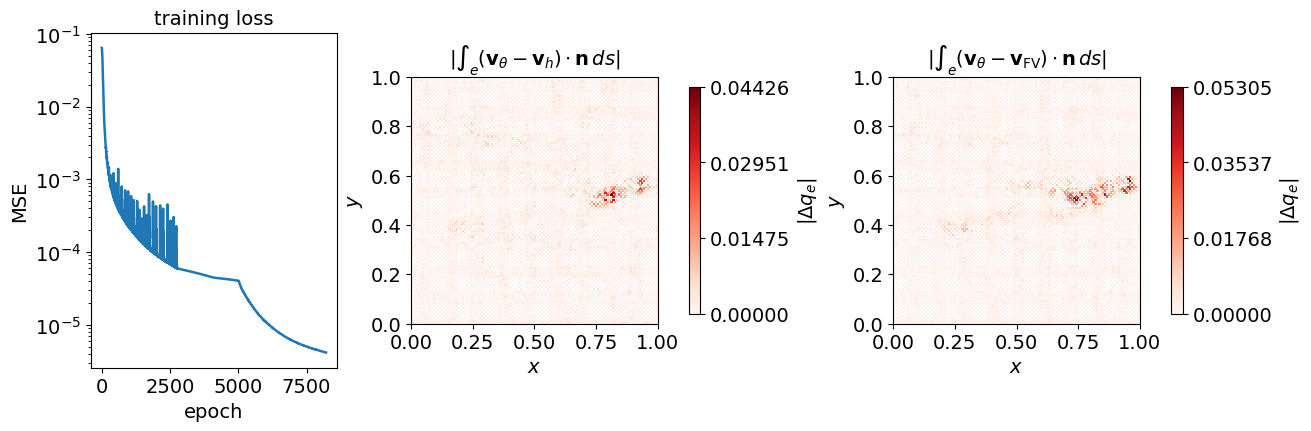

In [9]:
# Hard-curl PINN diagnostic plots (rerunnable; no retraining).
HARD_PINN_PLOT_POINT_SIZE = 3.0
HARD_PINN_PLOT_CMAP = "Reds"

if not HARD_CURL_PINN_ACTIVE:
    raise RuntimeError("Run the hard-conservative stream-function PINN training cell before this plot cell.")

_has_mrst_hard_pinn = hard_pinn_agg_flux_error_mrst is not None and np.any(np.isfinite(hard_pinn_agg_flux_error_mrst))
_ncols = 3 if _has_mrst_hard_pinn else 2
_figsize = (13.0, 4.2) if _has_mrst_hard_pinn else (9.0, 4.2)

print("Hard-curl PINN aggregated dual-interface errors:")
print(f"  vs CG   : L2={hard_pinn_agg_flux_l2:.6e}, RMSE={np.sqrt(np.mean(hard_pinn_agg_flux_error**2)):.6e}, max={np.max(np.abs(hard_pinn_agg_flux_error)):.6e}")
if _has_mrst_hard_pinn:
    _m = np.isfinite(hard_pinn_agg_flux_error_mrst)
    print(f"  vs MRST : L2={hard_pinn_agg_flux_l2_mrst:.6e}, RMSE={np.sqrt(np.mean(hard_pinn_agg_flux_error_mrst[_m]**2)):.6e}, max={np.nanmax(np.abs(hard_pinn_agg_flux_error_mrst)):.6e}")
else:
    print("  vs MRST : skipped; matching MRST dual flux unavailable")


def _add_flux_error_scatter(ax, values, title, mask=None):
    values = np.asarray(values, dtype=float)
    if mask is None:
        mask = np.isfinite(values)
    else:
        mask = np.asarray(mask, dtype=bool) & np.isfinite(values)
    if not np.any(mask):
        ax.axis("off")
        ax.set_title(title + " unavailable")
        return None
    abs_values = np.abs(values[mask])
    vmax = max(float(np.nanmax(abs_values)), 1.0e-14)
    sc = ax.scatter(
        _agg_centroid[mask, 0], _agg_centroid[mask, 1],
        c=abs_values, s=HARD_PINN_PLOT_POINT_SIZE, marker="s",
        cmap=HARD_PINN_PLOT_CMAP, vmin=0.0, vmax=vmax,
        linewidths=0.0, rasterized=True,
    )
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.grid(False)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    cbar = ax.figure.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"$|\Delta q_e|$")
    cbar.set_ticks(np.linspace(0.0, vmax, 4))
    return sc

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, _ncols, figsize=_figsize, constrained_layout=True)
    axes = np.atleast_1d(axes)

    if hard_pinn_loss_history:
        axes[0].semilogy(np.arange(1, len(hard_pinn_loss_history) + 1), hard_pinn_loss_history, lw=1.8)
        axes[0].set_xlabel("epoch" if TORCH_AVAILABLE else "step")
        axes[0].set_ylabel("MSE")
    else:
        axes[0].axis("off")
    axes[0].set_title("training loss")
    axes[0].grid(False)

    _add_flux_error_scatter(
        axes[1], hard_pinn_agg_flux_error,
        r"$|\int_e(\mathbf{v}_\theta-\mathbf{v}_h)\cdot\mathbf{n}\,ds|$",
    )
    if _has_mrst_hard_pinn:
        _add_flux_error_scatter(
            axes[2], hard_pinn_agg_flux_error_mrst,
            r"$|\int_e(\mathbf{v}_\theta-\mathbf{v}_{\mathrm{FV}})\cdot\mathbf{n}\,ds|$",
        )
    plt.show()


R_tau audit quadrature/evaluation: 1572864 points in 17.11 s
Element residual R_tau = sum_{e in partial K} int_e v.n ds - Q_K
  CG  (interface-averaged): n=4096 mean|R|=7.168217e-03 median|R|=8.541893e-04 rmse=6.621205e-02 max|R|=3.704930e+00 sum(R)=-1.629767e-04
  PINN: n=4096 mean|R|=2.160959e-11 median|R|=1.201813e-15 rmse=4.407150e-10 max|R|=1.843870e-08 sum(R)=+1.347651e-14


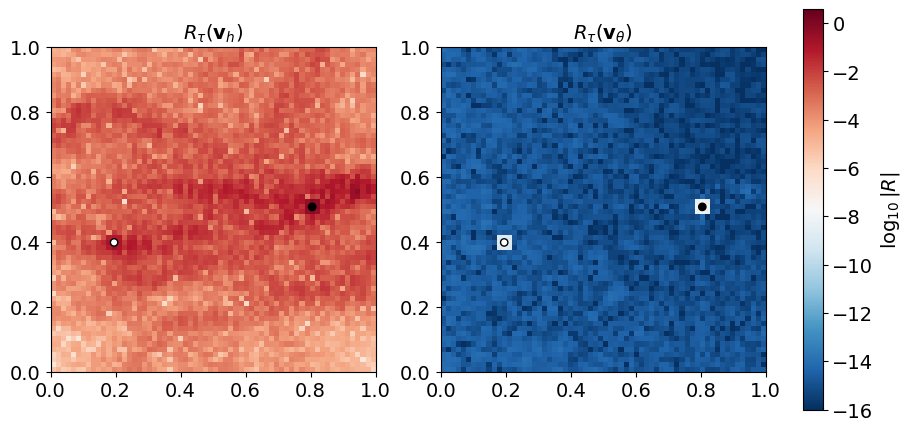

Nodal-dual residual R_xi on the transport CVs
  CG all      : n=4225 mean|R|=1.419603e-03 median|R|=2.244439e-04 rmse=5.838860e-03 max|R|=1.089557e-01 sum(R)=-1.629767e-04
  PINN all    : n=4225 mean|R|=4.037735e-09 median|R|=4.656613e-10 rmse=1.903144e-08 max|R|=2.267770e-07 sum(R)=+1.065200e-08
  CG interior : n=3969 mean|R|=1.492500e-03 median|R|=2.516022e-04 rmse=6.015772e-03 max|R|=1.089557e-01 sum(R)=-4.074418e-05
  PINN interior: n=3969 mean|R|=4.199608e-09 median|R|=4.656613e-10 rmse=1.951954e-08 max|R|=2.267770e-07 sum(R)=-2.095476e-08
  CG sources  : n=8 mean|R|=3.425976e-02 median|R|=2.173004e-02 rmse=4.332187e-02 max|R|=7.793421e-02 sum(R)=-1.822952e-01
  PINN sources: n=8 mean|R|=3.331661e-08 median|R|=2.195884e-08 rmse=4.632943e-08 max|R|=9.380165e-08 sum(R)=+1.415610e-07


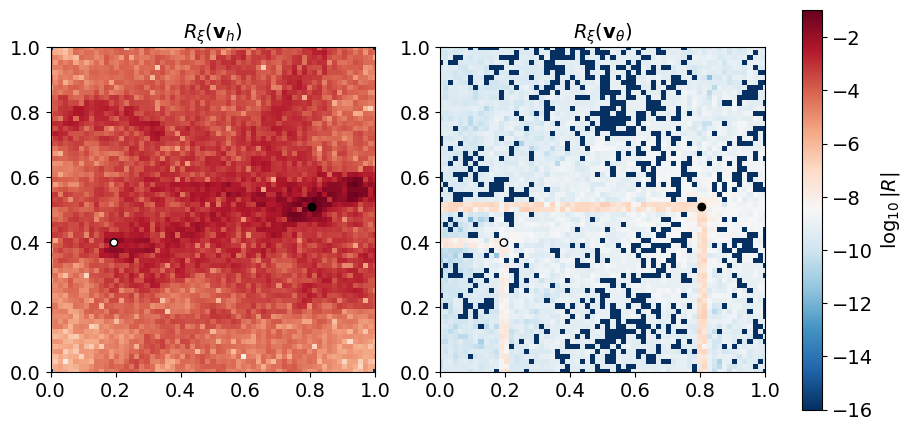

Rotated control-volume residual R_zeta
  zeta CVs: 4278, angle=45 deg, Hu=0.015625, Hv=0.015625
  CG  : n=4278 mean|R|=5.214428e-03 median|R|=6.027456e-04 rmse=3.169383e-02 max|R|=1.369681e+00 sum(R)=-1.629767e-04
  PINN: n=4278 mean|R|=3.242865e-10 median|R|=2.654904e-13 rmse=6.851788e-09 max|R|=2.762901e-07 sum(R)=+6.761579e-08
  CG   sum(R_zeta^2)=4.297245e+00, RMSE=3.169383e-02
  PINN sum(R_zeta^2)=2.008392e-13, RMSE=6.851788e-09


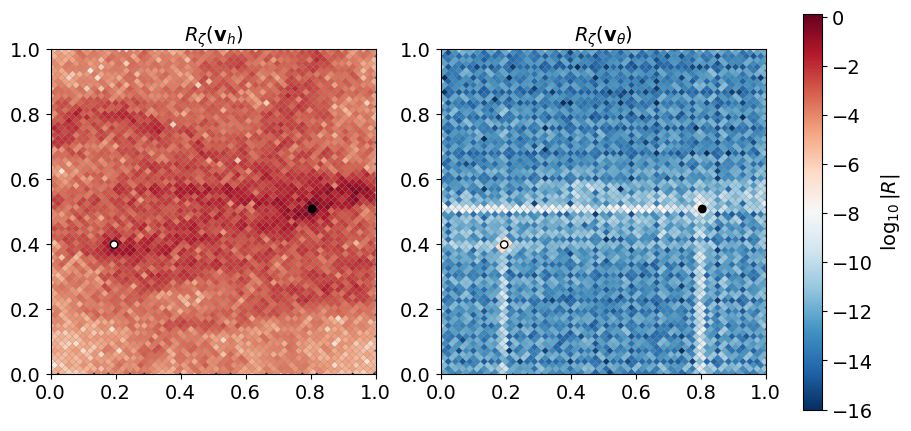

In [10]:
# Hard-curl PINN conservation residual diagnostics on tau, xi, and zeta control volumes.
# Run this after the hard-curl PINN diagnostic plot cell and before transport.
CONSERVATION_EPS = 1.0e-16
CONSERVATION_RTAU_EDGE_NQ = 96
CONSERVATION_RZETA_EDGE_NQ = 8
CONSERVATION_RZETA_ANGLE_DEG = 45.0
CONSERVATION_RZETA_HU = 1.0 * h_est
CONSERVATION_RZETA_HV = 1.0 * h_est
CONSERVATION_RZETA_SHIFT_FRACTION = np.asarray((0.31, 0.47), dtype=float)
CONSERVATION_RZETA_MIN_AREA = 1.0e-14
CONSERVATION_RZETA_COLORBAR_MODE = "shared"  # "shared" or "independent"
CONSERVATION_RZETA_LOG_CLIM = None
CONSERVATION_CMAP = "RdBu_r"
CONSERVATION_OUTLINE_COLOR = "0.35"
CONSERVATION_OUTLINE_WIDTH = 0.10

if "PINN" not in dual_flux_by_method:
    raise RuntimeError("Run the hard-curl PINN training cell before the conservation diagnostic cell.")
PINN_POINTWISE_AVAILABLE = "q_rec_numpy" in globals() and callable(q_rec_numpy)
if not PINN_POINTWISE_AVAILABLE:
    print("Pointwise q_rec_numpy is unavailable, so R_tau and R_zeta PINN maps are skipped. R_xi still uses stored PINN dual fluxes.")


def _legendre_01_local(nq):
    xi, wi = np.polynomial.legendre.leggauss(max(1, int(nq)))
    return 0.5 * (xi + 1.0), 0.5 * wi


def _integrate_velocity_segment(velocity_fn, a, b, normal, nq):
    q, w = _legendre_01_local(nq)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    normal = np.asarray(normal, dtype=float)
    edge = b - a
    seg_len = float(np.linalg.norm(edge))
    if seg_len <= 0.0:
        return 0.0
    pts = a[None, :] + q[:, None] * edge[None, :]
    vel = velocity_fn(pts)
    return float(seg_len * np.sum(w * np.einsum("ij,j->i", vel, normal)))


def q_cg_interface_average_numpy(points):
    # Vectorized two-sided average for CG values sampled on primal-cell interfaces.
    # Boundary points remain one-sided.  Points away from interfaces use their host cell.
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    out = np.zeros((len(pts), 2), dtype=float)
    counts = np.zeros(len(pts), dtype=float)
    if len(pts) == 0:
        return out

    tol = 1.0e-10 * h_est
    relx = (pts[:, 0] - xmin) / hx
    rely = (pts[:, 1] - ymin) / hy
    base_ix = np.floor(np.clip(relx, 0.0, np.nextafter(float(nx), 0.0))).astype(np.int64)
    base_iy = np.floor(np.clip(rely, 0.0, np.nextafter(float(ny), 0.0))).astype(np.int64)
    base_ix = np.clip(base_ix, 0, nx - 1)
    base_iy = np.clip(base_iy, 0, ny - 1)

    gx = np.rint(relx).astype(np.int64)
    gy = np.rint(rely).astype(np.int64)
    on_vertical = (gx > 0) & (gx < nx) & (np.abs(relx - gx) <= tol / hx)
    on_horizontal = (gy > 0) & (gy < ny) & (np.abs(rely - gy) <= tol / hy)

    def _add(mask, ix, iy):
        ids = np.flatnonzero(mask)
        if ids.size == 0:
            return
        cids = np.clip(iy[ids], 0, ny - 1) * nx + np.clip(ix[ids], 0, nx - 1)
        out[ids] += q_cg_on_rect_cell_numpy(pts[ids], cids)
        counts[ids] += 1.0

    both = on_vertical & on_horizontal
    vertical_only = on_vertical & ~on_horizontal
    horizontal_only = on_horizontal & ~on_vertical
    neither = ~(on_vertical | on_horizontal)

    _add(neither, base_ix, base_iy)
    _add(vertical_only, gx - 1, base_iy)
    _add(vertical_only, gx, base_iy)
    _add(horizontal_only, base_ix, gy - 1)
    _add(horizontal_only, base_ix, gy)
    _add(both, gx - 1, gy - 1)
    _add(both, gx, gy - 1)
    _add(both, gx - 1, gy)
    _add(both, gx, gy)

    counts = np.maximum(counts, 1.0)
    return out / counts[:, None]


def build_tau_quadrature(edge_nq=CONSERVATION_RTAU_EDGE_NQ):
    q, w = _legendre_01_local(edge_nq)
    edge_points, edge_nw, edge_ids = [], [], []
    for ci, cell in enumerate(rect["cells"]):
        for edge in physical_edge_defs(cell):
            a = np.asarray(edge["a"], dtype=float)
            b = np.asarray(edge["b"], dtype=float)
            normal = np.asarray(edge["normal"], dtype=float)
            seg = b - a
            seg_len = float(np.linalg.norm(seg))
            if seg_len <= 0.0:
                continue
            pts = a[None, :] + q[:, None] * seg[None, :]
            edge_points.append(pts)
            edge_nw.append(w[:, None] * (seg_len * normal)[None, :])
            edge_ids.append(np.full(len(q), int(ci), dtype=np.int32))
    return {
        "edge_points": np.vstack(edge_points) if edge_points else np.zeros((0, 2), dtype=float),
        "edge_nw": np.vstack(edge_nw) if edge_nw else np.zeros((0, 2), dtype=float),
        "edge_ids": np.concatenate(edge_ids) if edge_ids else np.zeros(0, dtype=np.int32),
    }


def compute_R_tau_batched_velocity(velocity_fn, tau_data):
    vel = velocity_fn(tau_data["edge_points"])
    flux_q = np.sum(vel * tau_data["edge_nw"], axis=1)
    flux = np.zeros(ncell, dtype=float)
    np.add.at(flux, tau_data["edge_ids"], flux_q)
    return flux - source_rate_cell


def compute_R_tau_pointwise_velocity(velocity_fn, edge_nq=CONSERVATION_RTAU_EDGE_NQ):
    # Kept for quick debugging/reference; the audit below uses the batched version.
    return compute_R_tau_batched_velocity(velocity_fn, build_tau_quadrature(edge_nq))


_t_tau0 = time.perf_counter()
tau_data_diag = build_tau_quadrature(CONSERVATION_RTAU_EDGE_NQ)
R_tau_diag_cg = compute_R_tau_batched_velocity(q_cg_interface_average_numpy, tau_data_diag)
R_tau_diag_pinn = compute_R_tau_batched_velocity(q_rec_numpy, tau_data_diag) if PINN_POINTWISE_AVAILABLE else np.full_like(R_tau_diag_cg, np.nan)
print(f"R_tau audit quadrature/evaluation: {len(tau_data_diag['edge_points'])} points in {time.perf_counter() - _t_tau0:.2f} s")


print("Element residual R_tau = sum_{e in partial K} int_e v.n ds - Q_K")
print("  CG  (interface-averaged):", residual_stats(R_tau_diag_cg))
if PINN_POINTWISE_AVAILABLE:
    print("  PINN:", residual_stats(R_tau_diag_pinn))
else:
    print("  PINN: skipped (pointwise q_rec_numpy unavailable)")


def _log_abs(vals):
    return np.log10(np.maximum(np.abs(np.asarray(vals, dtype=float)), CONSERVATION_EPS))


def _shared_log_clim(*arrays, default=(-16.0, -2.0)):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float).reshape(-1)
        arr = arr[np.isfinite(arr)]
        if arr.size:
            vals.append(arr)
    if not vals:
        return default
    vals = np.concatenate(vals)
    vmin, vmax = float(np.min(vals)), float(np.max(vals))
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return default
    if vmin >= vmax:
        pad = 0.5
        return vmin - pad, vmax + pad
    return vmin, vmax


def _plot_rect_cell_residual_pair(R_cg, R_pinn):
    log_cg = _log_abs(R_cg)
    log_pinn = _log_abs(R_pinn)
    vmin, vmax = _shared_log_clim(log_cg, log_pinn)
    with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
        fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.2), constrained_layout=True)
        panels = [(log_cg, r"$R_\tau(\mathbf{v}_h)$"), (log_pinn, r"$R_\tau(\mathbf{v}_\theta)$")]
        pcm = None
        for ax, (vals, title) in zip(axes, panels):
            pcm = ax.pcolormesh(x_edges, y_edges, cell_field_to_grid(vals), cmap=CONSERVATION_CMAP, vmin=vmin, vmax=vmax, shading="flat")
            ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=28, edgecolors="k", zorder=5)
            ax.set_aspect("equal")
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.set_title(title)
            ax.grid(False)
        cbar = fig.colorbar(pcm, ax=axes.ravel().tolist(), fraction=0.046, pad=0.03)
        cbar.set_label(r"$\log_{10}|R|$")
        plt.show()


if PINN_POINTWISE_AVAILABLE:
    _plot_rect_cell_residual_pair(R_tau_diag_cg, R_tau_diag_pinn)

# R_xi on the nodal dual mesh used by transport.  This uses the actual integrated
# dual-face fluxes that drive the saturation solve.
R_xi_diag_cg = dual_single_phase_residual(dual_flux_by_method["CG"])
R_xi_diag_pinn = dual_single_phase_residual(dual_flux_by_method["PINN"])
print("Nodal-dual residual R_xi on the transport CVs")
print("  CG all      :", residual_stats(R_xi_diag_cg))
print("  PINN all    :", residual_stats(R_xi_diag_pinn))
print("  CG interior :", residual_stats(R_xi_diag_cg, interior_vertex_ids))
print("  PINN interior:", residual_stats(R_xi_diag_pinn, interior_vertex_ids))
print("  CG sources  :", residual_stats(R_xi_diag_cg, source_vertex_ids))
print("  PINN sources:", residual_stats(R_xi_diag_pinn, source_vertex_ids))

x_dual_diag_edges = np.concatenate([[xmin], 0.5 * (x_nodes[:-1] + x_nodes[1:]), [xmax]])
y_dual_diag_edges = np.concatenate([[ymin], 0.5 * (y_nodes[:-1] + y_nodes[1:]), [ymax]])
log_xi_cg = _log_abs(R_xi_diag_cg).reshape(dual_shape)
log_xi_pinn = _log_abs(R_xi_diag_pinn).reshape(dual_shape)
_xi_vmin, _xi_vmax = _shared_log_clim(log_xi_cg, log_xi_pinn)
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.2), constrained_layout=True)
    pcm = None
    for ax, vals, title in [
        (axes[0], log_xi_cg, r"$R_\xi(\mathbf{v}_h)$"),
        (axes[1], log_xi_pinn, r"$R_\xi(\mathbf{v}_\theta)$"),
    ]:
        pcm = ax.pcolormesh(x_dual_diag_edges, y_dual_diag_edges, vals, cmap=CONSERVATION_CMAP, vmin=_xi_vmin, vmax=_xi_vmax, shading="flat")
        ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=28, edgecolors="k", zorder=5)
        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_title(title)
        ax.grid(False)
    cbar = fig.colorbar(pcm, ax=axes.ravel().tolist(), fraction=0.046, pad=0.03)
    cbar.set_label(r"$\log_{10}|R|$")
    plt.show()

# Rotated zeta control volumes.
def clip_polygon_axis_bound_zeta(poly, axis, bound, keep_less, tol=1.0e-12):
    poly = [np.asarray(p, dtype=float) for p in poly]
    if not poly:
        return []

    def inside(p):
        return p[axis] <= bound + tol if keep_less else p[axis] >= bound - tol

    out = []
    prev = poly[-1]
    prev_in = inside(prev)
    for cur in poly:
        cur_in = inside(cur)
        if cur_in != prev_in:
            denom = cur[axis] - prev[axis]
            if abs(denom) > 1.0e-15:
                t = (bound - prev[axis]) / denom
                out.append(prev + t * (cur - prev))
        if cur_in:
            out.append(cur)
        prev, prev_in = cur, cur_in
    return out


def clip_polygon_to_rect_zeta(poly, x0, x1, y0, y1):
    out = [np.asarray(p, dtype=float) for p in poly]
    for axis, bound, keep_less in [(0, x0, False), (0, x1, True), (1, y0, False), (1, y1, True)]:
        out = clip_polygon_axis_bound_zeta(out, axis, bound, keep_less)
        if len(out) == 0:
            return np.zeros((0, 2), dtype=float)
    return order_polygon_vertices(np.asarray(out, dtype=float)) if len(out) >= 3 else np.zeros((0, 2), dtype=float)


def clip_polygon_to_domain_zeta(poly):
    return clip_polygon_to_rect_zeta(poly, xmin, xmax, ymin, ymax)


def integrate_source_polygon_exact(poly):
    poly = np.asarray(poly, dtype=float).reshape(-1, 2)
    if len(poly) < 3:
        return 0.0
    total = 0.0
    for cid in np.flatnonzero(np.abs(source_rate_cell) > 1.0e-300):
        ix = int(cid % nx)
        iy = int(cid // nx)
        x0 = xmin + ix * hx
        x1 = x0 + hx
        y0 = ymin + iy * hy
        y1 = y0 + hy
        clipped = clip_polygon_to_rect_zeta(poly, x0, x1, y0, y1)
        if len(clipped) >= 3:
            total += abs(polygon_signed_area(clipped)) * source_density_cell[int(cid)]
    return float(total)


def rotated_rect_grid_lines_zeta(lo, hi, H, shift, tol=1.0e-12):
    H = float(H)
    if H <= 0.0:
        raise ValueError("Rotated-CV spacing must be positive.")
    shift = float(np.mod(shift, H))
    lines = [float(lo), float(hi)]
    x = float(lo) + shift
    if x <= lo + tol:
        x += H
    while x < hi - tol:
        lines.append(float(x))
        x += H
    return np.asarray(sorted(lines), dtype=float)


def build_rotated_zeta_polygons():
    theta = np.deg2rad(CONSERVATION_RZETA_ANGLE_DEG)
    e_u = np.array([np.cos(theta), np.sin(theta)], dtype=float)
    e_v = np.array([-np.sin(theta), np.cos(theta)], dtype=float)
    origin = np.array([xmin, ymin], dtype=float)
    bbox_poly = np.array([[xmin, ymin], [xmax, ymin], [xmax, ymax], [xmin, ymax]], dtype=float)
    bbox_uv = np.column_stack(((bbox_poly - origin) @ e_u, (bbox_poly - origin) @ e_v))
    shift_u = float(CONSERVATION_RZETA_SHIFT_FRACTION[0] * CONSERVATION_RZETA_HU)
    shift_v = float(CONSERVATION_RZETA_SHIFT_FRACTION[1] * CONSERVATION_RZETA_HV)
    u_lines = rotated_rect_grid_lines_zeta(bbox_uv[:, 0].min(), bbox_uv[:, 0].max(), CONSERVATION_RZETA_HU, shift_u)
    v_lines = rotated_rect_grid_lines_zeta(bbox_uv[:, 1].min(), bbox_uv[:, 1].max(), CONSERVATION_RZETA_HV, shift_v)
    polys, centers, areas = [], [], []
    for u0, u1 in zip(u_lines[:-1], u_lines[1:]):
        for v0, v1 in zip(v_lines[:-1], v_lines[1:]):
            corners_uv = np.array([[u0, v0], [u1, v0], [u1, v1], [u0, v1]], dtype=float)
            rect_xy = origin + corners_uv[:, 0:1] * e_u[None, :] + corners_uv[:, 1:2] * e_v[None, :]
            poly = clip_polygon_to_domain_zeta(rect_xy)
            if len(poly) < 3:
                continue
            area = abs(polygon_signed_area(poly))
            if area <= CONSERVATION_RZETA_MIN_AREA:
                continue
            polys.append(poly)
            centers.append(poly.mean(axis=0))
            areas.append(area)
    return polys, np.asarray(centers, dtype=float), np.asarray(areas, dtype=float)


def segment_grid_breakpoints(a, b, tol=1.0e-12):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    d = b - a
    ts = [0.0, 1.0]
    if abs(d[0]) > tol:
        lo, hi = sorted([a[0], b[0]])
        for xline in x_edges[1:-1]:
            if lo + tol < xline < hi - tol:
                ts.append(float((xline - a[0]) / d[0]))
    if abs(d[1]) > tol:
        lo, hi = sorted([a[1], b[1]])
        for yline in y_edges[1:-1]:
            if lo + tol < yline < hi - tol:
                ts.append(float((yline - a[1]) / d[1]))
    ts = np.asarray(sorted(ts), dtype=float)
    keep = [ts[0]]
    for t in ts[1:]:
        if t - keep[-1] > 1.0e-12:
            keep.append(float(t))
    return np.asarray(keep, dtype=float)


def build_zeta_quadrature(polys):
    q, w = _legendre_01_local(CONSERVATION_RZETA_EDGE_NQ)
    edge_points, edge_nw, edge_ids, edge_cell_ids = [], [], [], []
    source = np.zeros(len(polys), dtype=float)
    for rid, poly in enumerate(polys):
        poly = order_polygon_vertices(poly)
        source[rid] = integrate_source_polygon_exact(poly)
        centroid = poly.mean(axis=0)
        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            edge = x1 - x0
            breaks = segment_grid_breakpoints(x0, x1)
            for t0, t1 in zip(breaks[:-1], breaks[1:]):
                if t1 - t0 <= 1.0e-14:
                    continue
                a = x0 + t0 * edge
                b = x0 + t1 * edge
                seg = b - a
                seg_len = float(np.linalg.norm(seg))
                if seg_len <= 1.0e-15:
                    continue
                n_len = outward_edge_normal(a, b, centroid) * seg_len
                mid = 0.5 * (a + b)
                cell_id = int(locate_rect_cells(mid[None, :])[0][0])
                for qq, ww in zip(q, w):
                    edge_points.append(a + qq * seg)
                    edge_nw.append(ww * n_len)
                    edge_ids.append(int(rid))
                    edge_cell_ids.append(cell_id)
    return {
        "edge_points": np.asarray(edge_points, dtype=float),
        "edge_nw": np.asarray(edge_nw, dtype=float),
        "edge_ids": np.asarray(edge_ids, dtype=np.int32),
        "edge_cell_ids": np.asarray(edge_cell_ids, dtype=np.int64),
        "source": source,
    }


def compute_zeta_residuals(zeta_data, n_polys):
    q_cg = q_cg_on_rect_cell_numpy(zeta_data["edge_points"], zeta_data["edge_cell_ids"])
    flux_cg_q = np.sum(q_cg * zeta_data["edge_nw"], axis=1)
    flux_cg = np.zeros(n_polys, dtype=float)
    np.add.at(flux_cg, zeta_data["edge_ids"], flux_cg_q)
    R_cg = flux_cg - zeta_data["source"]
    if PINN_POINTWISE_AVAILABLE:
        q_pin = q_rec_numpy(zeta_data["edge_points"])
        flux_pin_q = np.sum(q_pin * zeta_data["edge_nw"], axis=1)
        flux_pin = np.zeros(n_polys, dtype=float)
        np.add.at(flux_pin, zeta_data["edge_ids"], flux_pin_q)
        R_pin = flux_pin - zeta_data["source"]
    else:
        R_pin = np.full(n_polys, np.nan, dtype=float)
    return R_cg, R_pin


zeta_polys_diag, zeta_centers_diag, zeta_areas_diag = build_rotated_zeta_polygons()
zeta_data_diag = build_zeta_quadrature(zeta_polys_diag)
R_zeta_diag_cg, R_zeta_diag_pinn = compute_zeta_residuals(zeta_data_diag, len(zeta_polys_diag))

print("Rotated control-volume residual R_zeta")
print(f"  zeta CVs: {len(zeta_polys_diag)}, angle={CONSERVATION_RZETA_ANGLE_DEG:g} deg, Hu={CONSERVATION_RZETA_HU:.6g}, Hv={CONSERVATION_RZETA_HV:.6g}")
print("  CG  :", residual_stats(R_zeta_diag_cg))
if PINN_POINTWISE_AVAILABLE:
    print("  PINN:", residual_stats(R_zeta_diag_pinn))
    for _name, _R in [("CG", R_zeta_diag_cg), ("PINN", R_zeta_diag_pinn)]:
        print(f"  {_name:<4} sum(R_zeta^2)={np.sum(_R**2):.6e}, RMSE={np.sqrt(np.mean(_R**2)):.6e}")
else:
    print("  PINN: skipped (pointwise q_rec_numpy unavailable)")

if PINN_POINTWISE_AVAILABLE:
    log_zeta_cg = _log_abs(R_zeta_diag_cg)
    log_zeta_pinn = _log_abs(R_zeta_diag_pinn)
    _zeta_panels = [(log_zeta_cg, r"$R_\zeta(\mathbf{v}_h)$"), (log_zeta_pinn, r"$R_\zeta(\mathbf{v}_\theta)$")]
    _mode = str(CONSERVATION_RZETA_COLORBAR_MODE).strip().lower()
    if _mode not in {"shared", "independent"}:
        raise ValueError('CONSERVATION_RZETA_COLORBAR_MODE must be "shared" or "independent"')
    with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
        fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.2), constrained_layout=True)
        if _mode == "shared":
            if CONSERVATION_RZETA_LOG_CLIM is None:
                _zvmin, _zvmax = _shared_log_clim(log_zeta_cg, log_zeta_pinn)
            else:
                _zvmin, _zvmax = map(float, CONSERVATION_RZETA_LOG_CLIM)
        for ax, (vals, title) in zip(axes, _zeta_panels):
            if _mode == "independent":
                _zvmin, _zvmax = _shared_log_clim(vals)
            pc = PolyCollection(
                zeta_polys_diag,
                edgecolors=CONSERVATION_OUTLINE_COLOR,
                linewidths=CONSERVATION_OUTLINE_WIDTH,
                cmap=CONSERVATION_CMAP,
            )
            pc.set_array(vals)
            pc.set_clim(_zvmin, _zvmax)
            ax.add_collection(pc)
            ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=28, edgecolors="k", zorder=5)
            ax.set_aspect("equal")
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.set_title(title)
            ax.grid(False)
            if _mode == "independent":
                cbar = fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.03)
                cbar.set_label(r"$\log_{10}|R|$")
        if _mode == "shared":
            cbar = fig.colorbar(pc, ax=axes.ravel().tolist(), fraction=0.046, pad=0.03)
            cbar.set_label(r"$\log_{10}|R|$")
        plt.show()


R_ref(v_theta) faces: 100%|██████████| 11/11 [00:11<00:00,  1.00s/batch]


Reference-dual residual R_ref on the fine CVFEM/MRST transport mesh
  mesh file: case3_mrst_export_spe10_ref_cvfem.mat, CVs=263169, faces=527364, face quadrature=2
  evaluation time: 11.03 s
  PINN all    : n=263169 mean|R|=9.056208e-08 median|R|=2.328329e-09 rmse=6.552460e-07 max|R|=3.661705e-05 sum(R)=+4.824662e-04
  PINN sources: n=162 mean|R|=2.859833e-06 median|R|=5.793213e-07 rmse=6.582120e-06 max|R|=3.018941e-05 sum(R)=+1.933657e-04
  PINN sum(R_ref^2)=1.129909e-07, RMSE=6.552460e-07


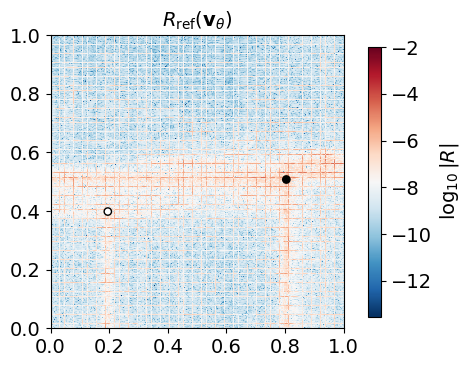

In [11]:
# R_ref on the fine 512^2 CVFEM/MRST-dual reference transport mesh.
CONSERVATION_RREF_FACE_NQ = 2
CONSERVATION_RREF_FACE_BATCH = 50000
R_REF_MESH_FILE = pathlib.Path(DATA_FILE).parent / "case3_mrst_export_spe10_ref_cvfem.mat"
R_ref_diag_pinn = None
if PINN_POINTWISE_AVAILABLE and R_REF_MESH_FILE.exists():
    _rref = loadmat(R_REF_MESH_FILE, squeeze_me=True, struct_as_record=False)
    _rref_p1 = np.asarray(_rref["face_p1"], dtype=float).reshape(-1, 2)
    _rref_p2 = np.asarray(_rref["face_p2"], dtype=float).reshape(-1, 2)
    _rref_normal = np.asarray(_rref["face_normal"], dtype=float).reshape(-1, 2)
    _rref_neighbors = np.asarray(_rref["face_neighbors"], dtype=np.int64).reshape(-1, 2)
    _rref_source = np.asarray(_rref["dual_source_rate"], dtype=float).reshape(-1)
    _rref_owner = _rref_neighbors[:, 0] - 1
    _rref_neigh = _rref_neighbors[:, 1] - 1
    _rref_has_neigh = _rref_neigh >= 0
    _rref_ncv = int(_rref_source.size)

    _rq, _rw = _legendre_01_local(CONSERVATION_RREF_FACE_NQ)
    _rref_flux = np.zeros(len(_rref_owner), dtype=float)
    _t_rref = time.perf_counter()
    for _start in tqdm(range(0, len(_rref_owner), CONSERVATION_RREF_FACE_BATCH), desc=r"R_ref(v_theta) faces", unit="batch"):
        _stop = min(len(_rref_owner), _start + CONSERVATION_RREF_FACE_BATCH)
        _a = _rref_p1[_start:_stop]
        _b = _rref_p2[_start:_stop]
        _seg = _b - _a
        _seg_len = np.linalg.norm(_seg, axis=1)
        _pts = (_a[:, None, :] + _rq[None, :, None] * _seg[:, None, :]).reshape(-1, 2)
        _vel = q_rec_numpy(_pts).reshape(_stop - _start, len(_rq), 2)
        _dot = np.einsum("fqd,fd->fq", _vel, _rref_normal[_start:_stop])
        _rref_flux[_start:_stop] = _seg_len * np.sum(_dot * _rw[None, :], axis=1)

    _rref_balance = np.zeros(_rref_ncv, dtype=float)
    _owner_ok = (_rref_owner >= 0) & (_rref_owner < _rref_ncv)
    np.add.at(_rref_balance, _rref_owner[_owner_ok], _rref_flux[_owner_ok])
    _neigh_ok = _rref_has_neigh & (_rref_neigh < _rref_ncv)
    np.add.at(_rref_balance, _rref_neigh[_neigh_ok], -_rref_flux[_neigh_ok])
    R_ref_diag_pinn = _rref_balance - _rref_source

    _rref_side = int(round(np.sqrt(_rref_ncv)))
    _rref_source_ids = np.flatnonzero(np.abs(_rref_source) > 1.0e-300)
    print("Reference-dual residual R_ref on the fine CVFEM/MRST transport mesh")
    print(f"  mesh file: {R_REF_MESH_FILE.name}, CVs={_rref_ncv}, faces={len(_rref_owner)}, face quadrature={CONSERVATION_RREF_FACE_NQ}")
    print(f"  evaluation time: {time.perf_counter() - _t_rref:.2f} s")
    print("  PINN all    :", residual_stats(R_ref_diag_pinn))
    print("  PINN sources:", residual_stats(R_ref_diag_pinn, _rref_source_ids))
    print(f"  PINN sum(R_ref^2)={np.sum(R_ref_diag_pinn**2):.6e}, RMSE={np.sqrt(np.mean(R_ref_diag_pinn**2)):.6e}")

    if _rref_side * _rref_side == _rref_ncv:
        _rref_log = _log_abs(R_ref_diag_pinn).reshape(_rref_side, _rref_side)
        _rref_vmin, _ = _shared_log_clim(_rref_log, default=(-16.0, -2.0))
        _rref_vmax = -2.0  # log10(1e-2), matching the residual-map colorbar convention.
        if _rref_vmin >= _rref_vmax:
            _rref_vmin = _rref_vmax - 1.0
        with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
            fig, ax = plt.subplots(1, 1, figsize=(4.6, 4.2), constrained_layout=True)
            _x_ref = np.linspace(xmin, xmax, _rref_side)
            _y_ref = np.linspace(ymin, ymax, _rref_side)
            pc = ax.pcolormesh(_x_ref, _y_ref, _rref_log, cmap=CONSERVATION_CMAP, vmin=_rref_vmin, vmax=_rref_vmax, shading="auto")
            ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=28, edgecolors="k", zorder=5)
            ax.set_aspect("equal")
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.set_title(r"$R_{\mathrm{ref}}(\mathbf{v}_\theta)$")
            ax.grid(False)
            cbar = fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.03)
            cbar.set_label(r"$\log_{10}|R|$")
            plt.show()
elif not R_REF_MESH_FILE.exists():
    print(f"Reference-dual residual R_ref skipped: missing {R_REF_MESH_FILE}")
else:
    print("Reference-dual residual R_ref skipped: pointwise q_rec_numpy unavailable.")


In [12]:
# Explicit upwind Buckley-Leverett transport on the active Deng Qk nodal dual mesh C_z.
# Run this after the pre-transport dual-flux diagnostic cell above.

def compute_dual_transport_dt(Fout):
    outflow = np.zeros(n_nodes, dtype=float)
    np.add.at(outflow, dual_owner, np.maximum(Fout, 0.0))
    np.add.at(outflow, dual_neigh[dual_has_neighbor], np.maximum(-Fout[dual_has_neighbor], 0.0))
    outflow += np.abs(dual_source_rate)
    active = (outflow > 1.0e-30) & (dual_pv > 0.0)
    if not np.any(active):
        raise RuntimeError("No dual-CV outflow/source terms found for the fixed flux field.")
    return CFL * np.min(dual_pv[active] / (FPRIME_MAX * outflow[active]))


def dual_source_water_rate(S):
    S = np.asarray(S, dtype=float)
    out = np.zeros_like(S)
    pos = dual_source_rate > 0.0
    neg = dual_source_rate < 0.0
    out[pos] = dual_source_rate[pos] * fractional_flow_bl(SOURCE_SATURATION)
    out[neg] = dual_source_rate[neg] * fractional_flow_bl(S[neg])
    return out


def advance_dual_transport(Fout, t_final, clip=True, nsteps_override=None):
    Fout = np.asarray(Fout, dtype=float)
    dt_cfl = compute_dual_transport_dt(Fout)
    if nsteps_override is None:
        if TRANSPORT_USE_FIXED_DT:
            nsteps = max(1, int(np.ceil(float(t_final) / TRANSPORT_DT)))
            dt_source = "fixed dt"
        else:
            nsteps = max(1, int(np.ceil(float(t_final) / dt_cfl)))
            dt_source = "method CFL"
    else:
        nsteps = max(1, int(nsteps_override))
        dt_source = "shared nsteps"
    dt = float(t_final) / nsteps
    dt_over_pv = np.zeros_like(dual_pv)
    active_pv = dual_pv > 0.0
    dt_over_pv[active_pv] = dt / dual_pv[active_pv]

    outward = Fout >= 0.0
    incoming_boundary = (~outward) & dual_is_boundary
    up_cv = np.empty_like(dual_owner)
    up_cv[outward] = dual_owner[outward]
    interior_negative = (~outward) & dual_has_neighbor
    up_cv[interior_negative] = dual_neigh[interior_negative]
    up_cv[incoming_boundary] = dual_owner[incoming_boundary]
    boundary_water_flux = fractional_flow_bl(BOUNDARY_INFLOW_S) * Fout

    S = np.zeros(n_nodes, dtype=float)
    cumulative_in = 0.0
    cumulative_out = 0.0
    cumulative_source = 0.0
    preclip_min = 0.0
    preclip_max = 0.0
    clipped_count = 0
    clip_mass_delta = 0.0

    for _ in range(nsteps):
        water_flux = fractional_flow_bl(S[up_cv]) * Fout
        water_flux[incoming_boundary] = boundary_water_flux[incoming_boundary]
        wb = water_flux[dual_is_boundary]
        cumulative_in += dt * float(np.sum(np.maximum(-wb, 0.0)))
        cumulative_out += dt * float(np.sum(np.maximum(wb, 0.0)))

        div = np.zeros(n_nodes, dtype=float)
        np.add.at(div, dual_owner, water_flux)
        np.add.at(div, dual_neigh[dual_has_neighbor], -water_flux[dual_has_neighbor])
        sw = dual_source_water_rate(S)
        cumulative_source += dt * float(np.sum(sw))
        S_new = S - dt_over_pv * (div - sw)
        preclip_min = min(preclip_min, float(np.min(S_new)))
        preclip_max = max(preclip_max, float(np.max(S_new)))
        if clip:
            S_clip = np.clip(S_new, 0.0, 1.0)
            clipped_count += int(np.count_nonzero(S_clip != S_new))
            clip_mass_delta += float(np.sum((S_clip - S_new) * dual_pv))
            S = S_clip
        else:
            S = S_new

    mass = float(np.sum(S * dual_pv))
    net = float(cumulative_in - cumulative_out + cumulative_source)
    denom = max(abs(cumulative_source) + cumulative_in, 1.0e-30)
    return S, {
        "T": float(t_final),
        "dt": float(dt),
        "dt_cfl": float(dt_cfl),
        "nsteps": int(nsteps),
        "dt_source": dt_source,
        "water_in": float(cumulative_in),
        "water_out": float(cumulative_out),
        "water_source": float(cumulative_source),
        "water_net": net,
        "water_mass": mass,
        "water_balance_error": float(mass - net),
        "water_balance_error_pct": float(100.0 * (mass - net) / denom),
        "preclip_min": float(preclip_min),
        "preclip_max": float(preclip_max),
        "clip_mass_delta": float(clip_mass_delta),
        "clipped_count": int(clipped_count),
        "pvi": float(t_final * source_rate_positive / PV_matrix),
    }

transport_cases = [(f"T{T:g}", float(T), float(T * source_rate_positive / PV_matrix)) for T in TRANSPORT_T_VALUES]
if TRANSPORT_CASE_KEY not in {key for key, _, _ in transport_cases}:
    TRANSPORT_CASE_KEY = transport_cases[0][0]

if RUN_DUAL_TRANSPORT:
    reference_dt = min(compute_dual_transport_dt(Fout) for Fout in dual_flux_by_method.values())
    reference_nsteps = {key: max(1, int(np.ceil(T / (TRANSPORT_DT if TRANSPORT_USE_FIXED_DT else reference_dt)))) for key, T, _ in transport_cases}
    transport_results = {}
    for key, tfinal, pvi in transport_cases:
        transport_results[key] = {}
        nsteps_ref = reference_nsteps[key]
        for name, Fout in dual_flux_by_method.items():
            S, meta = advance_dual_transport(Fout, tfinal, clip=TRANSPORT_CLIP, nsteps_override=nsteps_ref)
            transport_results[key][name] = {"S": S, "meta": meta}
else:
    reference_dt = np.nan
    transport_results = {key: {} for key, _, _ in transport_cases}

transport_rect_method_names = np.asarray(list(dual_flux_by_method.keys()), dtype=object)
transport_rect_saturation = {name: transport_results[TRANSPORT_CASE_KEY][name]["S"] for name in dual_flux_by_method} if RUN_DUAL_TRANSPORT else {}
transport_rect_meta = {name: transport_results[TRANSPORT_CASE_KEY][name]["meta"] for name in dual_flux_by_method} if RUN_DUAL_TRANSPORT else {}
transport_rect_S = np.vstack([transport_rect_saturation[name] for name in transport_rect_method_names]) if RUN_DUAL_TRANSPORT else np.zeros((0, n_nodes), dtype=float)
transport_rect_water_mass = np.asarray([transport_rect_meta[name]["water_mass"] for name in transport_rect_method_names], dtype=float) if RUN_DUAL_TRANSPORT else np.asarray([], dtype=float)
transport_rect_water_net = np.asarray([transport_rect_meta[name]["water_net"] for name in transport_rect_method_names], dtype=float) if RUN_DUAL_TRANSPORT else np.asarray([], dtype=float)
transport_rect_water_balance_error = np.asarray([transport_rect_meta[name]["water_balance_error"] for name in transport_rect_method_names], dtype=float) if RUN_DUAL_TRANSPORT else np.asarray([], dtype=float)
transport_rect_water_balance_error_pct = np.asarray([transport_rect_meta[name]["water_balance_error_pct"] for name in transport_rect_method_names], dtype=float) if RUN_DUAL_TRANSPORT else np.asarray([], dtype=float)

print(f"Transport mesh: Deng Q{CG_ORDER} nodal dual C_z, CVs={n_nodes}, faces={len(dual_owner)}, shape={dual_shape}")
print(f"Transport clipping enabled: {TRANSPORT_CLIP}")
print(f"Transport dt mode: {'fixed' if TRANSPORT_USE_FIXED_DT else 'CFL'}, requested dt={TRANSPORT_DT:.3e}, most restrictive CFL dt={reference_dt:.3e}")
if RUN_DUAL_TRANSPORT:
    print("Transport diagnostics:")
    print("  case    method  nsteps        dt       CFL dt      PVI    min(S)    max(S)  preclip min  preclip max    clip dM    balance%")
    for key, _, _ in transport_cases:
        for name in transport_rect_method_names:
            item = transport_results[key][str(name)]
            S = item["S"]
            meta = item["meta"]
            print(
                f"  {key:<7} {str(name):<5} {meta['nsteps']:7d} {meta['dt']:10.4e} {meta['dt_cfl']:10.4e} {meta['pvi']:8.4f} "
                f"{np.nanmin(S):8.3e} {np.nanmax(S):8.3e} {meta['preclip_min']:12.3e} {meta['preclip_max']:12.3e} "
                f"{meta['clip_mass_delta']:11.3e} {meta['water_balance_error_pct']:10.3e}"
            )
else:
    print("Dual transport skipped by RUN_DUAL_TRANSPORT=False.")


Transport mesh: Deng Q1 nodal dual C_z, CVs=4225, faces=16896, shape=(np.int64(65), np.int64(65))
Transport clipping enabled: True
Transport dt mode: CFL, requested dt=1.000e-04, most restrictive CFL dt=2.034e-05
Transport diagnostics:
  case    method  nsteps        dt       CFL dt      PVI    min(S)    max(S)  preclip min  preclip max    clip dM    balance%
  T0.02   CG        984 2.0325e-05 2.0392e-05   0.0200 0.000e+00 1.000e+00    0.000e+00    1.001e+00  -4.198e-04 -2.099e+00
  T0.02   NLR       984 2.0325e-05 2.0344e-05   0.0200 0.000e+00 9.618e-01    0.000e+00    9.618e-01   0.000e+00  3.123e-13
  T0.02   CVFEM     984 2.0325e-05 2.0415e-05   0.0200 0.000e+00 9.618e-01    0.000e+00    9.618e-01   0.000e+00  3.123e-13
  T0.02   PINN      984 2.0325e-05 2.0492e-05   0.0200 0.000e+00 9.618e-01    0.000e+00    9.618e-01   0.000e+00  2.949e-13
  T0.05   CG       2458 2.0342e-05 2.0392e-05   0.0500 0.000e+00 1.000e+00    0.000e+00    1.001e+00  -1.921e-03 -3.842e+00
  T0.05   NLR     

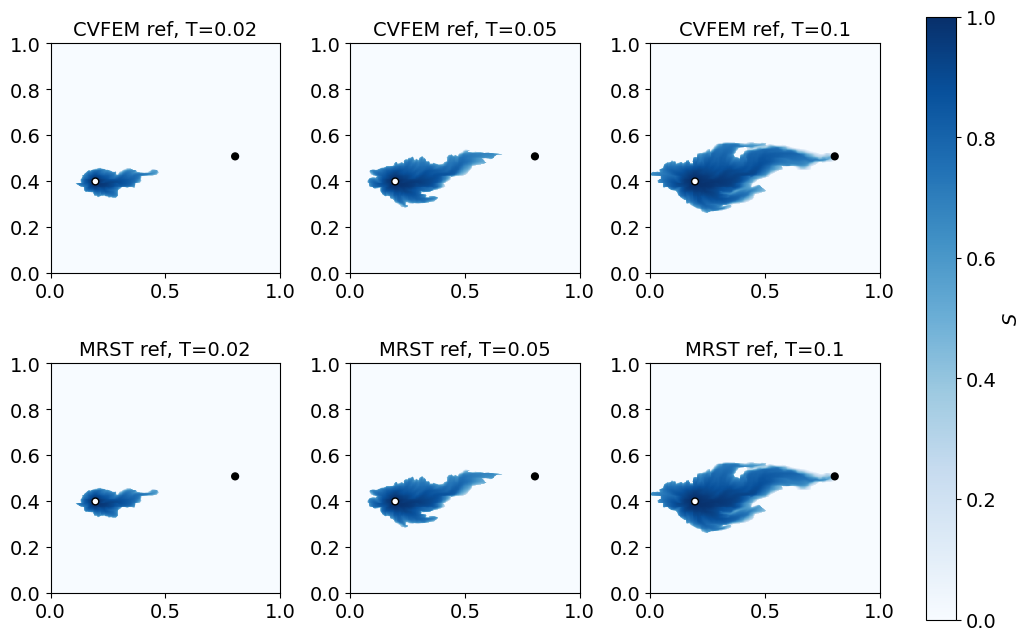

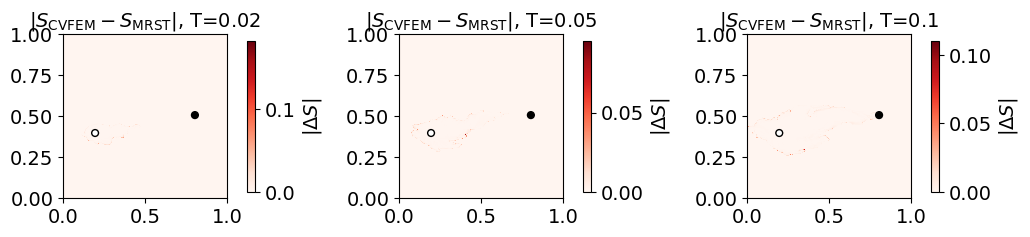

Fine-reference saturation comparison on the shared CVFEM/MRST dual mesh:
  T        MRST key      L2 error       RMSE      max|e|
  0.02     sw_T002      1.031762e-03 1.029751e-03 1.814267e-01
  0.05     sw_T005      9.539746e-04 9.521150e-04 9.519794e-02
  0.1      sw_T010      1.225162e-03 1.224951e-03 1.099450e-01


In [13]:
# Fine-reference saturation comparison: CVFEM 512 reference versus MRST on the same reference dual mesh.
REFERENCE_CVFEM_FILE = pathlib.Path(DATA_FILE).parent / "case3_cvfem_reference_spe10_512.mat"
REFERENCE_MRST_CVFEM_FILE = pathlib.Path(DATA_FILE).parent / "case3_mrst_export_spe10_ref_cvfem.mat"
reference_cvfem_data = loadmat(REFERENCE_CVFEM_FILE, squeeze_me=True, struct_as_record=False) if REFERENCE_CVFEM_FILE.exists() else None
reference_mrst_cvfem_data = loadmat(REFERENCE_MRST_CVFEM_FILE, squeeze_me=True, struct_as_record=False) if REFERENCE_MRST_CVFEM_FILE.exists() else None
reference_saturation_l2 = {}
reference_saturation_rmse = {}
reference_saturation_max = {}

def reference_snapshot_key_for_time(data, T):
    keys = set(data.keys())
    candidates = []
    for scale in (100, 1000):
        candidates.append(f"sw_T{int(round(float(T) * scale)):03d}")
        candidates.append(f"sw_T{int(round(float(T) * scale)):03d}_exp")
    if "snap_times" in data:
        times = np.asarray(data["snap_times"], dtype=float).reshape(-1)
        if times.size:
            idx = int(np.argmin(np.abs(times - float(T))))
            if abs(times[idx] - float(T)) < 1.0e-8:
                for scale in (100, 1000):
                    candidates.append(f"sw_T{int(round(times[idx] * scale)):03d}")
                    candidates.append(f"sw_T{int(round(times[idx] * scale)):03d}_exp")
    for key in candidates:
        if key in keys:
            return key
    return None

def reference_dual_area_weights(n_side):
    n_elem = int(n_side) - 1
    h = 1.0 / n_elem
    centers = np.linspace(0.0, 1.0, n_side)
    left = np.maximum(0.0, centers - 0.5 * h)
    right = np.minimum(1.0, centers + 0.5 * h)
    w = right - left
    return np.outer(w, w)

if reference_cvfem_data is not None and reference_mrst_cvfem_data is not None:
    _ref_times = np.asarray(reference_cvfem_data.get("T_values", []), dtype=float).reshape(-1)
    _ref_cvfem_all = np.asarray(reference_cvfem_data["S_ref_dual"], dtype=float)
    if _ref_cvfem_all.ndim == 1:
        _ref_cvfem_all = _ref_cvfem_all.reshape(1, -1)
    _ref_plot_times = [float(t) for t in _ref_times[:3]]
    _ref_records = []
    for _i, _t in enumerate(_ref_plot_times):
        _mrst_key = reference_snapshot_key_for_time(reference_mrst_cvfem_data, _t)
        if _mrst_key is None:
            print(f"Reference saturation comparison: MRST snapshot missing for T={_t:g}")
            continue
        _S_cvfem = np.asarray(_ref_cvfem_all[_i], dtype=float).reshape(-1)
        _S_mrst = np.asarray(reference_mrst_cvfem_data[_mrst_key], dtype=float).reshape(-1)
        if _S_cvfem.size != _S_mrst.size:
            print(f"Reference saturation comparison skipped at T={_t:g}: size mismatch CVFEM={_S_cvfem.size}, MRST={_S_mrst.size}")
            continue
        _n_side = int(round(np.sqrt(_S_cvfem.size)))
        if _n_side * _n_side != _S_cvfem.size:
            print(f"Reference saturation comparison skipped at T={_t:g}: non-square reference size {_S_cvfem.size}")
            continue
        _err = _S_cvfem - _S_mrst
        _area_w = reference_dual_area_weights(_n_side)
        _l2 = float(np.sqrt(np.sum((_err.reshape(_n_side, _n_side) ** 2) * _area_w)))
        _rmse = float(np.sqrt(np.mean(_err ** 2)))
        _mx = float(np.max(np.abs(_err)))
        reference_saturation_l2[_t] = _l2
        reference_saturation_rmse[_t] = _rmse
        reference_saturation_max[_t] = _mx
        _ref_records.append((_t, _mrst_key, _n_side, _S_cvfem, _S_mrst, np.abs(_err)))

    if _ref_records:
        _ncols = len(_ref_records)
        with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
            fig, axes = plt.subplots(2, _ncols, figsize=(max(10.0, 3.4 * _ncols), 6.4), squeeze=False, constrained_layout=True)
            _im = None
            for _j, (_t, _mrst_key, _n_side, _S_cvfem, _S_mrst, _abs_err) in enumerate(_ref_records):
                _x_ref = np.linspace(0.0, 1.0, _n_side)
                _y_ref = np.linspace(0.0, 1.0, _n_side)
                _im = axes[0, _j].pcolormesh(_x_ref, _y_ref, _S_cvfem.reshape(_n_side, _n_side), shading="auto", cmap="Blues", vmin=0.0, vmax=1.0)
                axes[1, _j].pcolormesh(_x_ref, _y_ref, _S_mrst.reshape(_n_side, _n_side), shading="auto", cmap="Blues", vmin=0.0, vmax=1.0)
                axes[0, _j].set_title(f"CVFEM ref, T={_t:g}")
                axes[1, _j].set_title(f"MRST ref, T={_t:g}")
                for _ax in axes[:, _j]:
                    _ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=24, edgecolors="k", zorder=5)
                    _ax.set_aspect("equal")
                    _ax.set_xlim(0.0, 1.0)
                    _ax.set_ylim(0.0, 1.0)
                    _ax.grid(False)
            _cbar = fig.colorbar(_im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.03)
            _cbar.set_label(r"$S$")
            plt.show()

        with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
            fig, axes = plt.subplots(1, _ncols, figsize=(max(10.0, 3.4 * _ncols), 3.6), squeeze=False, constrained_layout=True)
            axes = axes[0]
            _im = None
            for _ax, (_t, _mrst_key, _n_side, _S_cvfem, _S_mrst, _abs_err) in zip(axes, _ref_records):
                _x_ref = np.linspace(0.0, 1.0, _n_side)
                _y_ref = np.linspace(0.0, 1.0, _n_side)
                _local_vmax = float(np.max(_abs_err))
                _local_vmax = _local_vmax if np.isfinite(_local_vmax) and _local_vmax > 0.0 else 1.0e-14
                _im = _ax.pcolormesh(_x_ref, _y_ref, _abs_err.reshape(_n_side, _n_side), shading="auto", cmap="Reds", vmin=0.0, vmax=_local_vmax)
                _ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=24, edgecolors="k", zorder=5)
                _ax.set_aspect("equal")
                _ax.set_xlim(0.0, 1.0)
                _ax.set_ylim(0.0, 1.0)
                _ax.set_title(rf"$|S_{{\mathrm{{CVFEM}}}}-S_{{\mathrm{{MRST}}}}|$, T={_t:g}")
                _ax.grid(False)
                _cbar = fig.colorbar(_im, ax=_ax, fraction=0.046, pad=0.03)
                _cbar.set_label(r"$|\Delta S|$")
            plt.show()

        print("Fine-reference saturation comparison on the shared CVFEM/MRST dual mesh:")
        print("  T        MRST key      L2 error       RMSE      max|e|")
        for _t, _mrst_key, *_ in _ref_records:
            print(f"  {_t:<8.4g} {_mrst_key:<12} {reference_saturation_l2[_t]:12.6e} {reference_saturation_rmse[_t]:10.6e} {reference_saturation_max[_t]:10.6e}")
else:
    print(
        "Fine-reference saturation comparison skipped: "
        f"CVFEM file exists={REFERENCE_CVFEM_FILE.exists()}, MRST file exists={REFERENCE_MRST_CVFEM_FILE.exists()}"
    )


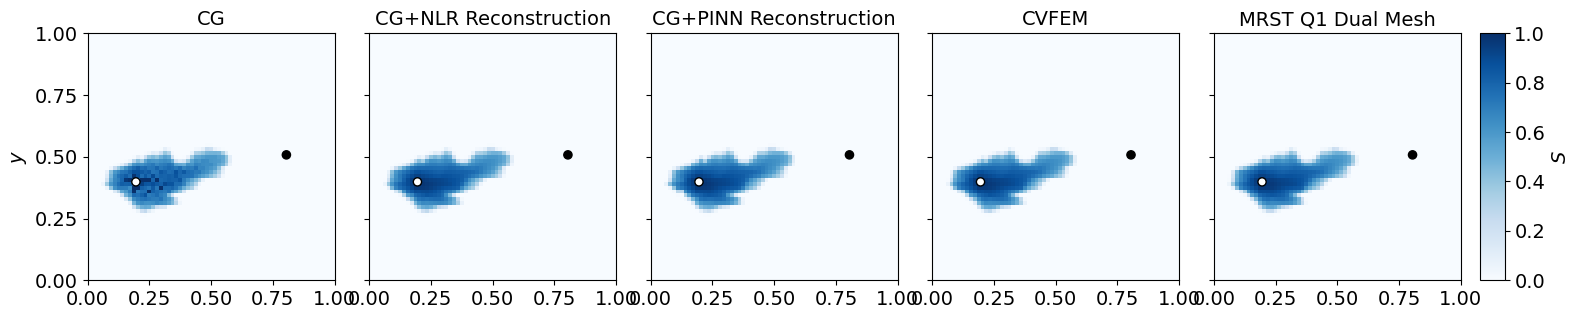

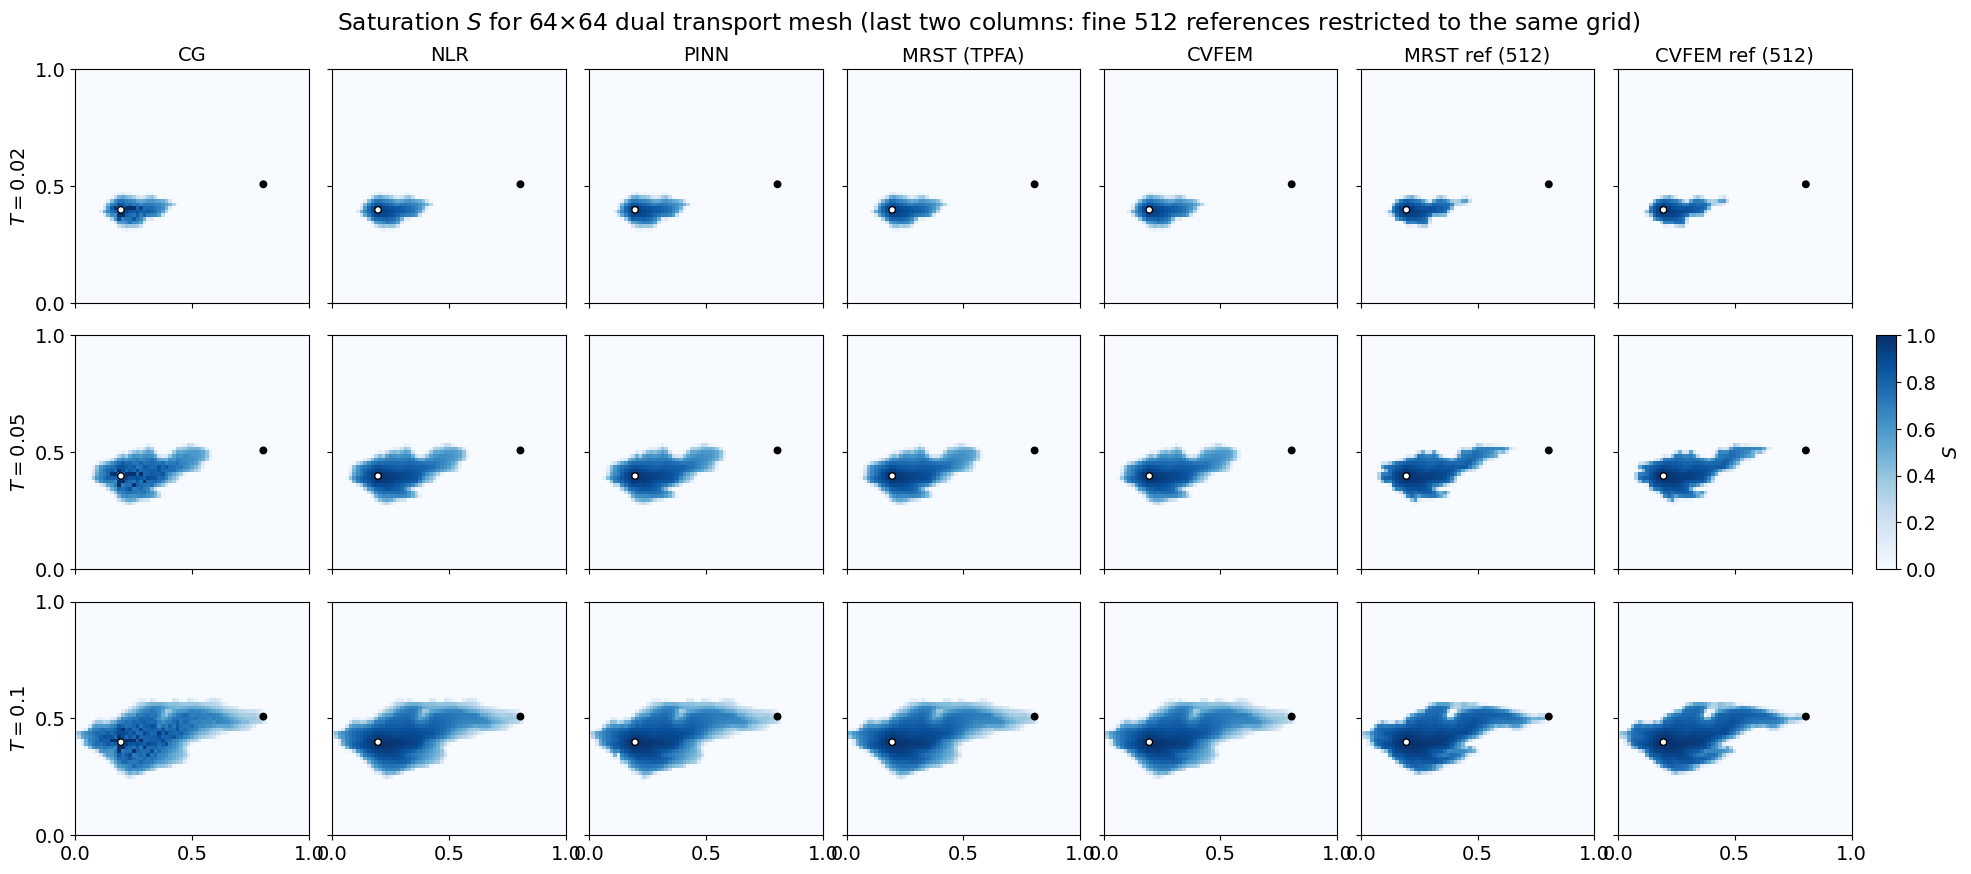

Multi-time saturation maps plotted for: T=0.02, T=0.05, T=0.1


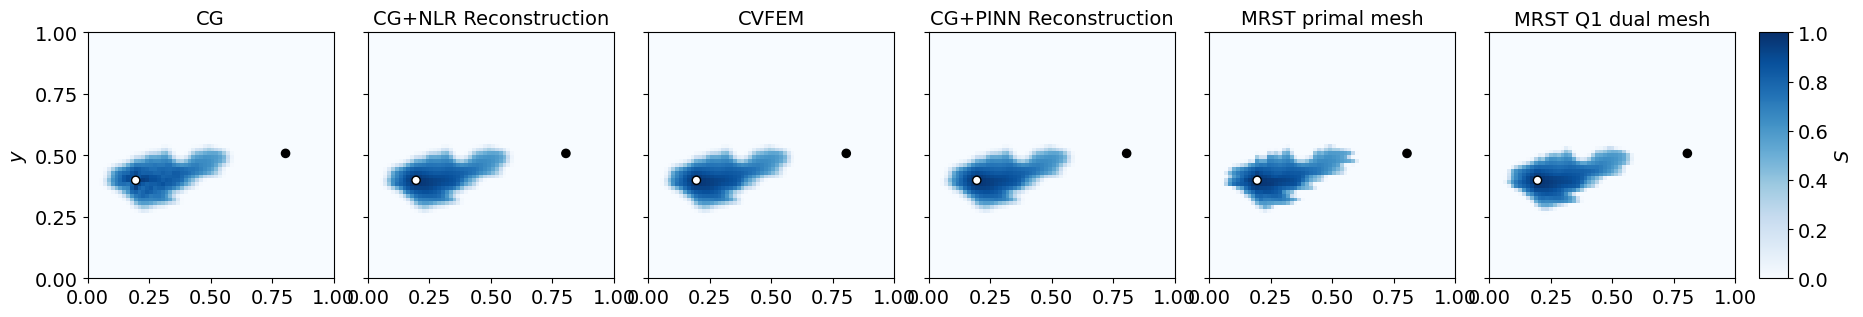

MRST primal rectangular-snapshot comparison at T=5.00000000e-02 using sw_T005_exp (explicitTransport).
  method     mean|e|        RMSE       max|e|
  CG       5.6027e-03  2.5168e-02  3.8625e-01
  NLR      4.3299e-03  2.2486e-02  3.8799e-01
  CVFEM    4.3164e-03  2.2468e-02  3.8726e-01
  PINN     4.3458e-03  2.2431e-02  3.8426e-01
  MRST primal alternate snapshot (sw_T005 - sw_T005_exp): RMSE=1.2314e-03, max|e|=2.4237e-02
MRST fine/dual-transport snapshot at T=5.00000000e-02 using sw_T005.
  MRST dual-transport dt=2.04778157e-05, cumulative nsteps=2442
Selected case: T0.05, T=5.00000000e-02, PVI=0.050000
Global water mass balance on the Deng Q1 nodal dual mesh:
  method        stored water      boundary net       source term        total net    balance error       clip dM    error%       nsteps       dt
  CG         4.807905e-02    -7.066183e-92     5.000000e-02     5.000000e-02  -1.920946e-03 -1.920946e-03 -3.842e+00     2458 2.0342e-05
  NLR        5.000000e-02    -2.057663e-90     5

In [26]:
# Saturation plots and water-balance table on the active Deng Qk nodal dual mesh.
def dual_field_to_grid(field):
    return np.asarray(field, dtype=float).reshape(dual_shape)

x_dual_edges = np.concatenate([[xmin], 0.5 * (x_nodes[:-1] + x_nodes[1:]), [xmax]])
y_dual_edges = np.concatenate([[ymin], 0.5 * (y_nodes[:-1] + y_nodes[1:]), [ymax]])
case_lookup = {key: (tfinal, pvi) for key, tfinal, pvi in transport_cases}
selected_T, selected_PVI = case_lookup[TRANSPORT_CASE_KEY]
plot_methods = list(dual_flux_by_method.keys())
plot_method_order = ["CG", "NLR", "PINN", "CVFEM"]
plot_titles = {"CG": "CG", "NLR": "CG+NLR Reconstruction", "CVFEM": "CVFEM", "PINN": "CG+PINN Reconstruction"}
plot_math_labels = {"CG": r"h", "NLR": r"\mathrm{NLR}", "CVFEM": r"\mathrm{CVFEM}", "PINN": r"\theta"}
transport_plot_methods = [
    m for m in plot_method_order
    if m in plot_methods and m in transport_results.get(TRANSPORT_CASE_KEY, {})
]
if "PINN" in plot_methods and "PINN" not in transport_results.get(TRANSPORT_CASE_KEY, {}):
    print("PINN flux is available, but PINN saturation is missing. Rerun the transport cell after the hard-curl PINN training cell.")


def snapshot_key_for_time(data, T, explicit=False):
    suffix = f"T{int(round(100.0 * float(T))):03d}"
    candidates = [f"sw_{suffix}_exp", f"sw_{suffix}"] if explicit else [f"sw_{suffix}", f"sw_{suffix}_exp"]
    for key in candidates:
        if key in data:
            arr = np.asarray(data[key]).reshape(-1)
            if arr.size:
                return key
    if "snap_times" in data:
        times = np.asarray(data["snap_times"], dtype=float).reshape(-1)
        if times.size:
            i = int(np.argmin(np.abs(times - float(T))))
            suffix = f"T{int(round(100.0 * float(times[i]))):03d}"
            candidates = [f"sw_{suffix}_exp", f"sw_{suffix}"] if explicit else [f"sw_{suffix}", f"sw_{suffix}_exp"]
            for key in candidates:
                if key in data:
                    arr = np.asarray(data[key]).reshape(-1)
                    if arr.size:
                        return key
    return None

MRST_PRIMAL_USE_EXPLICIT_TRANSPORT = True
MRST_DUAL_USE_EXPLICIT_TRANSPORT = True
_mrst_sw_key = snapshot_key_for_time(mrst, selected_T, explicit=MRST_PRIMAL_USE_EXPLICIT_TRANSPORT) if MRST_REFERENCE_AVAILABLE else None
_fine_sw_key = snapshot_key_for_time(mrst_fine, selected_T, explicit=MRST_DUAL_USE_EXPLICIT_TRANSPORT) if MRST_FINE_AVAILABLE else None

first_plot_entries = []
if RUN_DUAL_TRANSPORT:
    for name in transport_plot_methods:
        first_plot_entries.append({
            "title": plot_titles.get(name, name),
            "x_edges": x_dual_edges,
            "y_edges": y_dual_edges,
            "grid": dual_field_to_grid(transport_results[TRANSPORT_CASE_KEY][name]["S"]),
        })
_first_mrst_dual_for_plot = None
if _fine_sw_key is not None:
    _first_mrst_dual_for_plot = np.asarray(mrst_fine[_fine_sw_key], dtype=float).reshape(-1)
    if _first_mrst_dual_for_plot.size == n_nodes:
        first_plot_entries.append({
            "title": f"MRST Q{CG_ORDER} Dual Mesh",
            "x_edges": x_dual_edges,
            "y_edges": y_dual_edges,
            "grid": dual_field_to_grid(_first_mrst_dual_for_plot),
        })
    else:
        print(f"Skipping MRST dual panel in first figure: expected {n_nodes} Q{CG_ORDER} dual cells, got {_first_mrst_dual_for_plot.size}.")

if first_plot_entries:
    fig_w = max(10.0, 3.25 * len(first_plot_entries))
    with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
        fig, axes = plt.subplots(1, len(first_plot_entries), figsize=(fig_w, 4.5), squeeze=False)
        axes = axes[0]
        pcm = None
        for ax, item in zip(axes, first_plot_entries):
            pcm = ax.pcolormesh(item["x_edges"], item["y_edges"], item["grid"], cmap="Blues", vmin=0.0, vmax=1.0, shading="flat")
            ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=35, edgecolors="k", zorder=5)
            ax.set_aspect("equal")
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.set_title(item["title"])
            ax.grid(False)
        axes[0].set_ylabel(r"$y$")
        for ax in axes[1:]:
            ax.tick_params(labelleft=False)
        fig.subplots_adjust(left=0.055, right=0.90, bottom=0.08, top=0.92, wspace=0.14)
        fig.canvas.draw()
        pos = axes[-1].get_position()
        cax = fig.add_axes([pos.x1 + 0.012, pos.y0, 0.015, pos.height])
        cbar = fig.colorbar(pcm, cax=cax)
        cbar.set_label(r"$S$")
        plt.show()
else:
    print("No dual-transport saturation fields available to plot.")


# Multi-time saturation maps on the native 65 x 65 dual mesh.
# Columns: CG, NLR, PINN, MRST (TPFA dual transport), CVFEM, then the two fine 512
# references restricted to the same coarse dual CVs (loaded in the fine-reference cell).
SAT_MAP_METHOD_ORDER = ["CG", "NLR", "PINN", "MRST", "CVFEM"]
SAT_MAP_TITLES = {
    "CG": "CG",
    "NLR": "NLR",
    "PINN": "PINN",
    "MRST": "MRST (TPFA)",
    "CVFEM": "CVFEM",
    "MRST_ref": "MRST ref (512)",
    "CVFEM_ref": "CVFEM ref (512)",
}


def _satmap_overlap_1d(n_fine_nodes, target_edges, lo, hi):
    h_f = (float(hi) - float(lo)) / float(int(n_fine_nodes) - 1)
    centers = np.linspace(float(lo), float(hi), int(n_fine_nodes))
    fine_left = np.maximum(float(lo), centers - 0.5 * h_f)
    fine_right = np.minimum(float(hi), centers + 0.5 * h_f)
    target_edges = np.asarray(target_edges, dtype=float).reshape(-1)
    W = np.zeros((target_edges.size - 1, int(n_fine_nodes)), dtype=float)
    for j, (a, b) in enumerate(zip(target_edges[:-1], target_edges[1:])):
        W[j, :] = np.maximum(0.0, np.minimum(fine_right, b) - np.maximum(fine_left, a))
    return W


def _satmap_restrict_fine_dual(S_fine):
    S_fine = np.asarray(S_fine, dtype=float).reshape(-1)
    n_side = int(round(np.sqrt(S_fine.size)))
    if n_side * n_side != S_fine.size:
        raise ValueError(f"Fine dual field is not square: size={S_fine.size}")
    Wx = _satmap_overlap_1d(n_side, x_dual_edges, xmin, xmax)
    Wy = _satmap_overlap_1d(n_side, y_dual_edges, ymin, ymax)
    area = np.outer(np.diff(y_dual_edges), np.diff(x_dual_edges))
    return (Wy @ S_fine.reshape(n_side, n_side) @ Wx.T) / area


_satmap_grids = {}
if RUN_DUAL_TRANSPORT:
    for _key, _T, _pvi in transport_cases:
        for _m in SAT_MAP_METHOD_ORDER:
            if _m == "MRST":
                if MRST_FINE_AVAILABLE:
                    _k = snapshot_key_for_time(mrst_fine, _T, explicit=MRST_DUAL_USE_EXPLICIT_TRANSPORT)
                    if _k is not None:
                        _arr_m = np.asarray(mrst_fine[_k], dtype=float).reshape(-1)
                        if _arr_m.size == n_nodes:
                            _satmap_grids[(_m, _key)] = _arr_m.reshape(dual_shape)
            elif _m in transport_results.get(_key, {}):
                _satmap_grids[(_m, _key)] = dual_field_to_grid(transport_results[_key][_m]["S"])
        if "reference_mrst_cvfem_data" in globals() and reference_mrst_cvfem_data is not None:
            _k = reference_snapshot_key_for_time(reference_mrst_cvfem_data, _T)
            if _k is not None:
                _satmap_grids[("MRST_ref", _key)] = _satmap_restrict_fine_dual(reference_mrst_cvfem_data[_k])
        if "reference_cvfem_data" in globals() and reference_cvfem_data is not None and "S_ref_dual" in reference_cvfem_data:
            _Tv = np.asarray(reference_cvfem_data.get("T_values", []), dtype=float).reshape(-1)
            _Sa = np.asarray(reference_cvfem_data["S_ref_dual"], dtype=float)
            if _Sa.ndim == 1:
                _Sa = _Sa.reshape(1, -1)
            if _Tv.size:
                _j = int(np.argmin(np.abs(_Tv - float(_T))))
                if abs(float(_Tv[_j]) - float(_T)) < 1.0e-8:
                    _satmap_grids[("CVFEM_ref", _key)] = _satmap_restrict_fine_dual(_Sa[_j])

_satmap_cols = [
    _m for _m in SAT_MAP_METHOD_ORDER + ["MRST_ref", "CVFEM_ref"]
    if any((_m, _key) in _satmap_grids for _key, _T, _pvi in transport_cases)
]
if _satmap_cols:
    _nrows = len(transport_cases)
    _ncols = len(_satmap_cols)
    with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
        fig, axes = plt.subplots(_nrows, _ncols, figsize=(2.9 * _ncols, 2.95 * _nrows), squeeze=False)
        fig.subplots_adjust(left=0.05, right=0.925, bottom=0.05, top=0.92, wspace=0.10, hspace=0.12)
        pcm = None
        for irow, (_key, _T, _pvi) in enumerate(transport_cases):
            for icol, _m in enumerate(_satmap_cols):
                ax = axes[irow, icol]
                _grid = _satmap_grids.get((_m, _key))
                if _grid is None:
                    ax.axis("off")
                    continue
                pcm = ax.pcolormesh(x_dual_edges, y_dual_edges, _grid, cmap="Blues", vmin=0.0, vmax=1.0, shading="flat")
                ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=22, edgecolors="k", zorder=5)
                ax.set_aspect("equal")
                ax.set_xlim(xmin, xmax)
                ax.set_ylim(ymin, ymax)
                ax.set_xticks([0.0, 0.5, 1.0])
                ax.set_yticks([0.0, 0.5, 1.0])
                ax.grid(False)
                if irow == 0:
                    ax.set_title(SAT_MAP_TITLES.get(_m, _m))
                if icol == 0:
                    ax.set_ylabel(rf"$T = {_T:g}$")
                else:
                    ax.tick_params(labelleft=False)
                if irow < _nrows - 1:
                    ax.tick_params(labelbottom=False)
        for _ax in axes.ravel():
            _ax.apply_aspect()
        _mid = axes[(_nrows - 1) // 2, -1].get_position()
        _cax = fig.add_axes([axes[0, -1].get_position().x1 + 0.012, _mid.y0, 0.010, _mid.height])
        cbar = fig.colorbar(pcm, cax=_cax)
        cbar.set_label(r"$S$")
        fig.suptitle(
            r"Saturation $S$ for 64$\times$64 dual transport mesh "
            r"(last two columns: fine 512 references restricted to the same grid)",
            y=0.985,
        )
        plt.show()
    print("Multi-time saturation maps plotted for: " + ", ".join(f"T={_T:g}" for _key, _T, _pvi in transport_cases))


# Multi-time saturation error comparisons against fine references are in the next cell.
# There the fine MRST/CVFEM reference solutions are restricted to the native 65 x 65 dual mesh.


def dual_to_rect_cell_average(S_dual):
    S = np.asarray(S_dual, dtype=float).reshape(-1)
    C = np.zeros(ncell, dtype=float)
    for ci, cell in enumerate(rect["cells"]):
        total = 0.0
        for gi, vid in enumerate(cell["vids"]):
            x_l, x_r, y_b, y_t = cv_physical_bounds(cell, gi)
            subarea = max(0.0, x_r - x_l) * max(0.0, y_t - y_b)
            total += S[int(vid)] * subarea
        C[ci] = total / cell_area[ci]
    return C


def cell_field_to_grid_from_centroids(field, xc, nx_grid, ny_grid, phys=(1.0, 1.0)):
    field = np.asarray(field, dtype=float).reshape(-1)
    xc = np.asarray(xc, dtype=float).reshape(-1, 2)
    hx_grid = float(phys[0]) / int(nx_grid)
    hy_grid = float(phys[1]) / int(ny_grid)
    ix = np.rint((xc[:, 0] - 0.5 * hx_grid) / hx_grid).astype(int)
    iy = np.rint((xc[:, 1] - 0.5 * hy_grid) / hy_grid).astype(int)
    ix = np.clip(ix, 0, int(nx_grid) - 1)
    iy = np.clip(iy, 0, int(ny_grid) - 1)
    grid = np.full((int(ny_grid), int(nx_grid)), np.nan, dtype=float)
    grid[iy, ix] = field
    return grid


def fine_grid_info(data, S=None):
    if "xc_matrix" not in data:
        return None
    xc = np.asarray(data["xc_matrix"], dtype=float).reshape(-1, 2)
    size = int(np.asarray(S).size) if S is not None else int(xc.shape[0])
    if size == n_nodes:
        return {
            "kind": "dual",
            "title": rf"MRST Q{CG_ORDER} dual mesh",
            "xc": xc,
            "nx": dual_nx_nodes,
            "ny": dual_ny_nodes,
            "x_edges": x_dual_edges,
            "y_edges": y_dual_edges,
        }
    n = int(round(np.sqrt(size)))
    return {
        "kind": "uniform",
        "title": rf"MRST mesh ({n}x{n})",
        "xc": xc,
        "nx": n,
        "ny": n,
        "x_edges": np.linspace(0.0, physdim[0], n + 1),
        "y_edges": np.linspace(0.0, physdim[1], n + 1),
    }


def mrst_reference_grid(data, S):
    info = fine_grid_info(data, S)
    if info is None:
        raise ValueError("MRST reference export has no xc_matrix.")
    S = np.asarray(S, dtype=float).reshape(-1)
    if info["kind"] == "dual":
        grid = S.reshape(dual_shape)
    else:
        grid = cell_field_to_grid_from_centroids(S, info["xc"], info["nx"], info["ny"], phys=physdim)
    return info, grid

if (_mrst_sw_key is not None or _fine_sw_key is not None) and RUN_DUAL_TRANSPORT:
    rect_avg_by_method = {name: dual_to_rect_cell_average(transport_results[TRANSPORT_CASE_KEY][name]["S"]) for name in transport_plot_methods}
    comparison_entries = []
    for name in [m for m in ["CG", "NLR", "CVFEM", "PINN"] if m in rect_avg_by_method]:
        comparison_entries.append({
            "title": plot_titles.get(name, name),
            "x_edges": x_edges,
            "y_edges": y_edges,
            "grid": cell_field_to_grid(rect_avg_by_method[name]),
        })
    if _mrst_sw_key is not None:
        mrst_S_rect = _arr(_mrst_sw_key, float).reshape(-1)
        comparison_entries.append({
            "title": "MRST primal mesh",
            "x_edges": x_edges,
            "y_edges": y_edges,
            "grid": cell_field_to_grid(mrst_S_rect),
        })
    else:
        mrst_S_rect = None
    if _fine_sw_key is not None:
        fine_S = np.asarray(mrst_fine[_fine_sw_key], dtype=float).reshape(-1)
        fine_info, fine_grid = mrst_reference_grid(mrst_fine, fine_S)
        fine_xc = fine_info["xc"]
        fine_nx = fine_info["nx"]
        fine_ny = fine_info["ny"]
        fine_x_edges = fine_info["x_edges"]
        fine_y_edges = fine_info["y_edges"]
        comparison_entries.append({
            "title": fine_info["title"],
            "x_edges": fine_x_edges,
            "y_edges": fine_y_edges,
            "grid": fine_grid,
        })
    else:
        fine_S = None

    with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
        fig, axes = plt.subplots(1, len(comparison_entries), figsize=(max(13.0, 3.25 * len(comparison_entries)), 4.5), squeeze=False)
        axes = axes[0]
        pcm = None
        for ax, item in zip(axes, comparison_entries):
            pcm = ax.pcolormesh(item["x_edges"], item["y_edges"], item["grid"], cmap="Blues", vmin=0.0, vmax=1.0, shading="flat")
            ax.set_title(item["title"])
            ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=35, edgecolors="k", zorder=5)
            ax.set_aspect("equal")
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.grid(False)
        axes[0].set_ylabel(r"$y$")
        for ax in axes[1:]:
            ax.tick_params(labelleft=False)
        fig.subplots_adjust(left=0.055, right=0.90, bottom=0.08, top=0.92, wspace=0.14)
        fig.canvas.draw()
        pos = axes[-1].get_position()
        cax = fig.add_axes([pos.x1 + 0.012, pos.y0, 0.015, pos.height])
        cbar = fig.colorbar(pcm, cax=cax)
        cbar.set_label(r"$S$")
        plt.show()

    if _mrst_sw_key is not None:
        _mrst_primal_kind = "explicitTransport" if str(_mrst_sw_key).endswith("_exp") else "hand-code"
        print(f"MRST primal rectangular-snapshot comparison at T={selected_T:.8e} using {_mrst_sw_key} ({_mrst_primal_kind}).")
        print("  method     mean|e|        RMSE       max|e|")
        for name in [m for m in ["CG", "NLR", "CVFEM", "PINN"] if m in rect_avg_by_method]:
            err = rect_avg_by_method[name] - mrst_S_rect
            print(f"  {name:<6} {np.mean(np.abs(err)):12.4e} {np.sqrt(np.mean(err**2)):11.4e} {np.max(np.abs(err)):11.4e}")
        _alt_key = snapshot_key_for_time(mrst, selected_T, explicit=not MRST_PRIMAL_USE_EXPLICIT_TRANSPORT)
        if _alt_key is not None and _alt_key != _mrst_sw_key:
            alt_S = _arr(_alt_key, float).reshape(-1)
            print(f"  MRST primal alternate snapshot ({_alt_key} - {_mrst_sw_key}): RMSE={np.sqrt(np.mean((alt_S-mrst_S_rect)**2)):.4e}, max|e|={np.max(np.abs(alt_S-mrst_S_rect)):.4e}")
    if _fine_sw_key is not None:
        print(f"MRST fine/dual-transport snapshot at T={selected_T:.8e} using {_fine_sw_key}.")
        if fine_S is not None and fine_S.size != n_nodes:
            print(f"  Note: MRST snapshot has {fine_S.size} cells, not the active Q{CG_ORDER} dual size {n_nodes}.")
        if "meta_dt" in mrst_fine and "meta_nsteps" in mrst_fine:
            _times = np.asarray(mrst_fine.get("snap_times", []), dtype=float).reshape(-1)
            _idx = int(np.argmin(np.abs(_times - selected_T))) if _times.size else 0
            _dt = np.asarray(mrst_fine["meta_dt"], dtype=float).reshape(-1)
            _ns = np.asarray(mrst_fine["meta_nsteps"]).reshape(-1)
            if _idx < _dt.size and _idx < _ns.size:
                print(f"  MRST dual-transport dt={_dt[_idx]:.8e}, cumulative nsteps={int(_ns[_idx])}")
else:
    rect_avg_by_method = {}
    mrst_S_rect = None
    fine_S = None
    print("No matching MRST saturation snapshot found for the selected T, or dual transport was skipped.")

print(f"Selected case: {TRANSPORT_CASE_KEY}, T={selected_T:.8e}, PVI={selected_PVI:.6f}")
print(f"Global water mass balance on the Deng Q{CG_ORDER} nodal dual mesh:")
print("  method        stored water      boundary net       source term        total net    balance error       clip dM    error%       nsteps       dt")
if RUN_DUAL_TRANSPORT:
    for name in transport_rect_method_names:
        meta = transport_rect_meta[str(name)]
        boundary_net = meta["water_in"] - meta["water_out"]
        print(
            f"  {str(name):<6} {meta['water_mass']:16.6e} {boundary_net:16.6e} "
            f"{meta['water_source']:16.6e} {meta['water_net']:16.6e} "
            f"{meta['water_balance_error']:14.6e} {meta['clip_mass_delta']:13.6e} "
            f"{meta['water_balance_error_pct']:10.3e} "
            f"{meta['nsteps']:8d} {meta['dt']:10.4e}"
        )
else:
    print("  dual transport skipped")





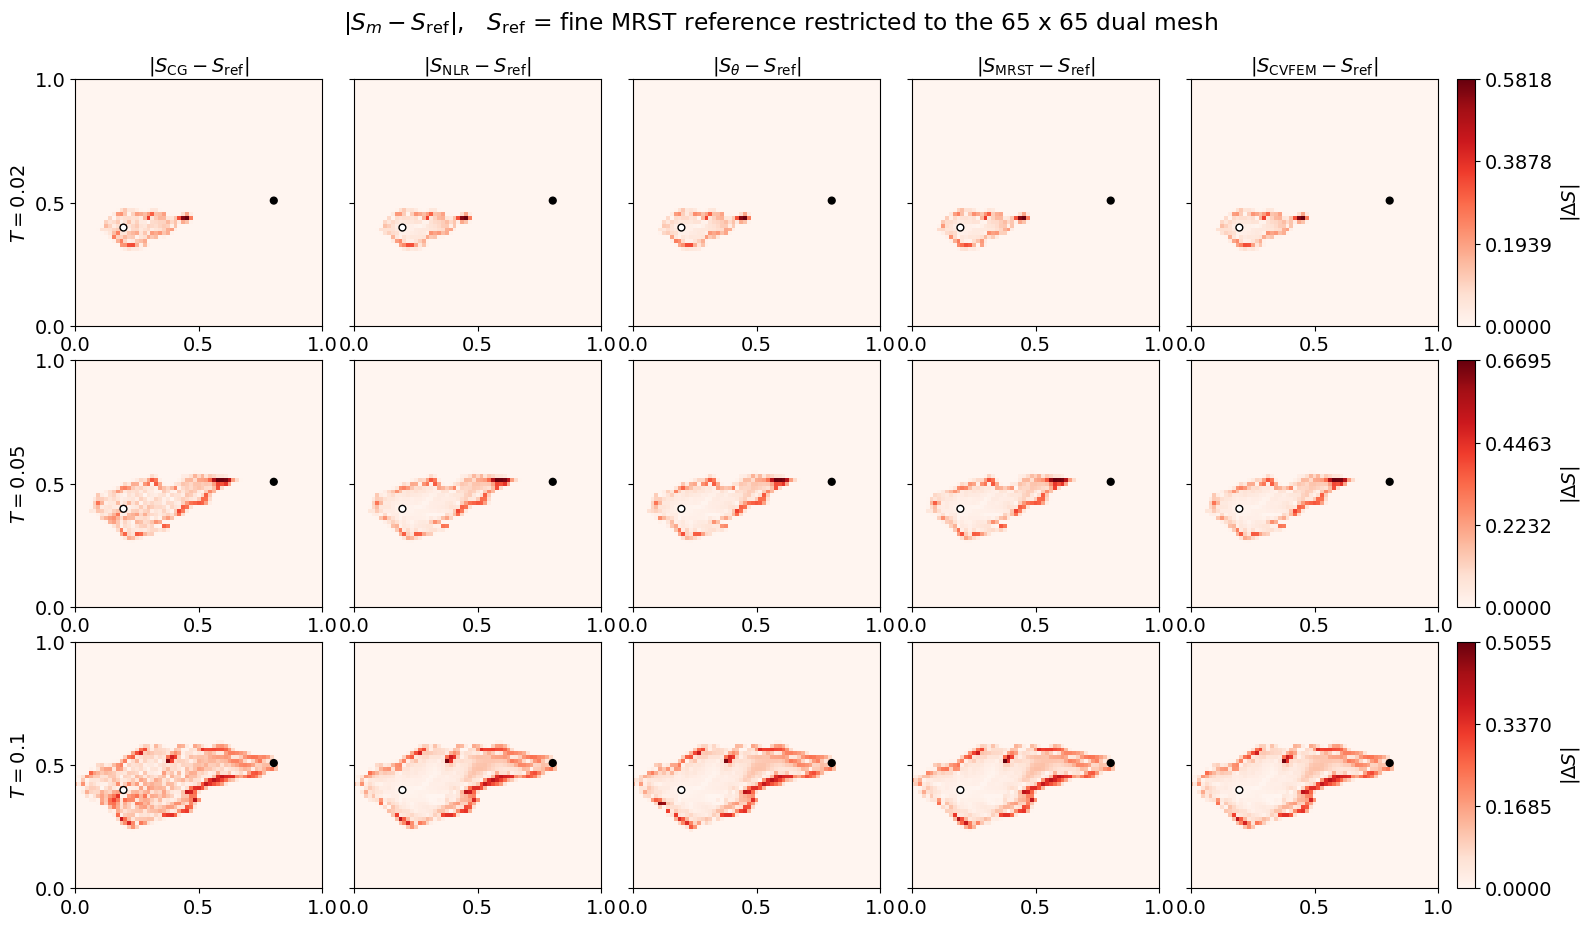

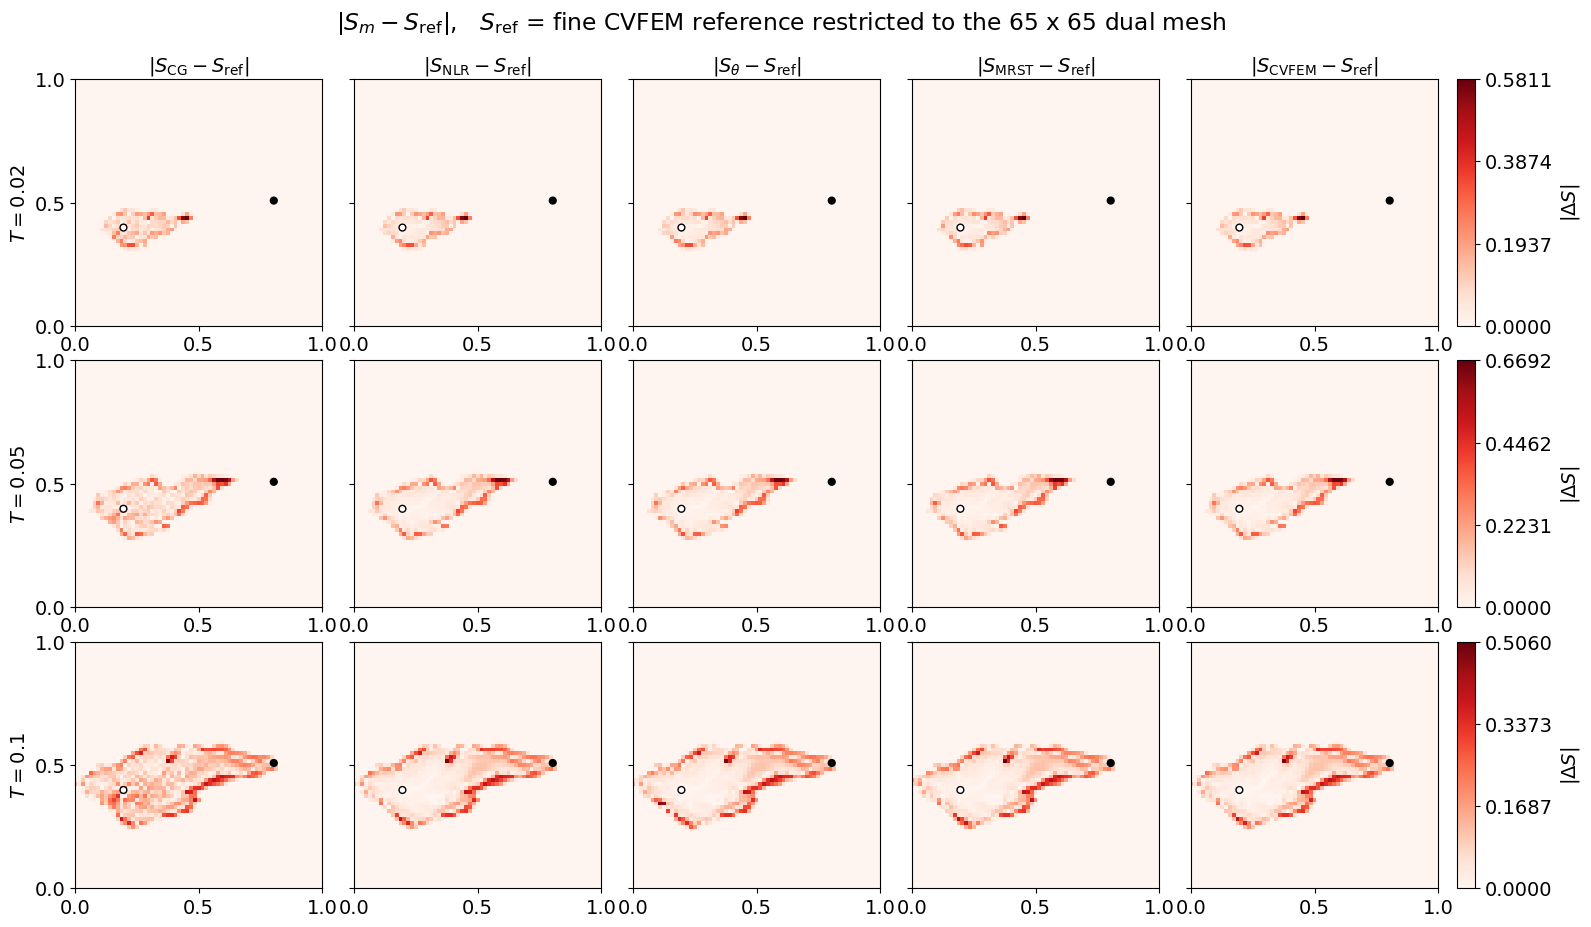

Multi-time saturation errors on the native 65 x 65 dual mesh relative to restricted fine references:
  reference  time      method    family        L2 error       area RMSE   point RMSE    max|e|
  MRST512       0.02  CG       dual    2.829547e-02 2.829547e-02 2.786015e-02 5.817737e-01
  MRST512       0.02  NLR      dual    2.608926e-02 2.608926e-02 2.568789e-02 5.817737e-01
  MRST512       0.02  PINN     dual    2.627674e-02 2.627674e-02 2.587248e-02 5.817737e-01
  MRST512       0.02  MRST     dual    2.662615e-02 2.662615e-02 2.621652e-02 5.817737e-01
  MRST512       0.02  CVFEM    dual    2.609235e-02 2.609235e-02 2.569093e-02 5.817737e-01
  MRST512       0.05  CG       dual    4.915566e-02 4.915566e-02 4.839942e-02 6.669163e-01
  MRST512       0.05  NLR      dual    4.547932e-02 4.547932e-02 4.477963e-02 6.663418e-01
  MRST512       0.05  PINN     dual    4.546777e-02 4.546777e-02 4.476827e-02 6.648432e-01
  MRST512       0.05  MRST     dual    4.671010e-02 4.671010e-02 4.599148e-0

In [27]:
# Multi-time saturation absolute-error comparison on the native 65 x 65 dual mesh.
# CG/NLR/PINN/CVFEM are used exactly on their transport dual CVs.
# MRST is taken from case3_mrst_export_finep_dualT.mat, which is already on the same 65 x 65 dual mesh.
# Only the fine 513 x 513 references are restricted to the coarse dual CVs.
FINE_REF_MRST_FILE = pathlib.Path(DATA_FILE).parent / "case3_mrst_export_spe10_ref_cvfem.mat"
FINE_REF_CVFEM_FILE = pathlib.Path(DATA_FILE).parent / "case3_cvfem_reference_spe10_512.mat"
MRST_DUAL65_FILE = pathlib.Path(DATA_FILE).parent / "case3_mrst_export_finep_dualT.mat"
SAT_NATIVE_METHOD_ORDER = ["CG", "NLR", "PINN", "MRST", "CVFEM"]
SAT_NATIVE_DUAL_METHODS = ["CG", "NLR", "PINN", "CVFEM"]
SAT_NATIVE_METHOD_TITLES = {
    "CG": "CG",
    "NLR": "NLR",
    "PINN": "PINN",
    "CVFEM": "CVFEM",
    "MRST": "MRST (TPFA)",
}
SAT_NATIVE_METHOD_LABELS = {
    "CG": r"\mathrm{CG}",
    "NLR": r"\mathrm{NLR}",
    "PINN": r"\theta",
    "CVFEM": r"\mathrm{CVFEM}",
    "MRST": r"\mathrm{MRST}",
}

if "x_dual_edges" not in globals():
    x_dual_edges = np.concatenate([[xmin], 0.5 * (x_nodes[:-1] + x_nodes[1:]), [xmax]])
if "y_dual_edges" not in globals():
    y_dual_edges = np.concatenate([[ymin], 0.5 * (y_nodes[:-1] + y_nodes[1:]), [ymax]])
if "MRST_DUAL_USE_EXPLICIT_TRANSPORT" not in globals():
    MRST_DUAL_USE_EXPLICIT_TRANSPORT = True


def _sat_native_suffix(T):
    return f"T{int(round(100.0 * float(T))):03d}"


def _snapshot_key_for_time_local(data, T, explicit=False):
    if "snapshot_key_for_time" in globals():
        return snapshot_key_for_time(data, T, explicit=explicit)
    suffix = _sat_native_suffix(T)
    candidates = [f"sw_{suffix}_exp", f"sw_{suffix}"] if explicit else [f"sw_{suffix}", f"sw_{suffix}_exp"]
    for key in candidates:
        if key in data:
            return key
    if "snap_times" in data:
        times = np.asarray(data["snap_times"], dtype=float).reshape(-1)
        if times.size:
            j = int(np.argmin(np.abs(times - float(T))))
            if abs(float(times[j]) - float(T)) < 1.0e-8:
                suffix = _sat_native_suffix(float(times[j]))
                candidates = [f"sw_{suffix}_exp", f"sw_{suffix}"] if explicit else [f"sw_{suffix}", f"sw_{suffix}_exp"]
                for key in candidates:
                    if key in data:
                        return key
    return None


def _overlap_matrix_from_fine_nodal_dual_to_edges(n_fine_nodes, target_edges, lo=0.0, hi=1.0):
    n_fine_nodes = int(n_fine_nodes)
    target_edges = np.asarray(target_edges, dtype=float).reshape(-1)
    if n_fine_nodes < 2:
        raise ValueError("Need at least two fine nodes for nodal-dual restriction.")
    h_f = (float(hi) - float(lo)) / float(n_fine_nodes - 1)
    fine_centers = np.linspace(float(lo), float(hi), n_fine_nodes)
    fine_left = np.maximum(float(lo), fine_centers - 0.5 * h_f)
    fine_right = np.minimum(float(hi), fine_centers + 0.5 * h_f)
    W = np.zeros((target_edges.size - 1, n_fine_nodes), dtype=float)
    for j, (a, b) in enumerate(zip(target_edges[:-1], target_edges[1:])):
        W[j, :] = np.maximum(0.0, np.minimum(fine_right, b) - np.maximum(fine_left, a))
    return W


def restrict_fine_nodal_dual_to_target_edges(S_fine_dual, target_x_edges, target_y_edges):
    S_fine_dual = np.asarray(S_fine_dual, dtype=float).reshape(-1)
    n_side = int(round(np.sqrt(S_fine_dual.size)))
    if n_side * n_side != S_fine_dual.size:
        raise ValueError(f"Fine dual field is not square: size={S_fine_dual.size}")
    S_grid = S_fine_dual.reshape(n_side, n_side)  # x-fastest: row=y, col=x
    Wx = _overlap_matrix_from_fine_nodal_dual_to_edges(n_side, target_x_edges, xmin, xmax)
    Wy = _overlap_matrix_from_fine_nodal_dual_to_edges(n_side, target_y_edges, ymin, ymax)
    dx = np.diff(np.asarray(target_x_edges, dtype=float))
    dy = np.diff(np.asarray(target_y_edges, dtype=float))
    area = np.outer(dy, dx)
    return (Wy @ S_grid @ Wx.T) / area


def _reference_keys_for_time(data, T):
    suffixes = [_sat_native_suffix(T)]
    if "snap_times" in data:
        times = np.asarray(data["snap_times"], dtype=float).reshape(-1)
        if times.size:
            j = int(np.argmin(np.abs(times - float(T))))
            if abs(float(times[j]) - float(T)) < 1.0e-8:
                suffixes.append(_sat_native_suffix(float(times[j])))
    out = []
    for suffix in suffixes:
        out.extend([f"sw_{suffix}", f"sw_{suffix}_exp"])
    return out


def _load_fine_mrst_reference_dual(path, times):
    if not pathlib.Path(path).exists():
        print(f"Fine MRST reference missing: {path}")
        return {}
    data = loadmat(path, squeeze_me=True, struct_as_record=False)
    out = {}
    for T in times:
        for key in _reference_keys_for_time(data, T):
            if key in data:
                arr = np.asarray(data[key], dtype=float).reshape(-1)
                if arr.size:
                    out[f"T{float(T):g}"] = restrict_fine_nodal_dual_to_target_edges(arr, x_dual_edges, y_dual_edges)
                    break
    return out


def _load_fine_cvfem_reference_dual(path, times):
    if not pathlib.Path(path).exists():
        print(f"Fine CVFEM reference missing: {path}")
        return {}
    data = loadmat(path, squeeze_me=True, struct_as_record=False)
    if "S_ref_dual" not in data or "T_values" not in data:
        print(f"Fine CVFEM reference file lacks S_ref_dual/T_values: {path}")
        return {}
    S_dual_all = np.asarray(data["S_ref_dual"], dtype=float)
    T_all = np.asarray(data["T_values"], dtype=float).reshape(-1)
    if S_dual_all.ndim == 1:
        S_dual_all = S_dual_all.reshape(1, -1)
    if S_dual_all.shape[0] != T_all.size and S_dual_all.shape[1] == T_all.size:
        S_dual_all = S_dual_all.T
    out = {}
    for T in times:
        j = int(np.argmin(np.abs(T_all - float(T))))
        if abs(float(T_all[j]) - float(T)) < 1.0e-8:
            arr = np.asarray(S_dual_all[j], dtype=float).reshape(-1)
            out[f"T{float(T):g}"] = restrict_fine_nodal_dual_to_target_edges(arr, x_dual_edges, y_dual_edges)
    return out


def _load_mrst_dual65_by_time(path, times):
    if not pathlib.Path(path).exists():
        print(f"MRST dual 65 transport file missing: {path}")
        return {}, {}
    data = loadmat(path, squeeze_me=True, struct_as_record=False)
    out = {}
    keys_used = {}
    for T in times:
        key = _snapshot_key_for_time_local(data, T, explicit=MRST_DUAL_USE_EXPLICIT_TRANSPORT)
        if key is None:
            key = _snapshot_key_for_time_local(data, T, explicit=False)
        if key is None:
            continue
        arr = np.asarray(data[key], dtype=float).reshape(-1)
        if arr.size != n_nodes:
            print(f"Skipping MRST dual snapshot {key}: expected {n_nodes} dual CVs, got {arr.size}.")
            continue
        time_key = f"T{float(T):g}"
        out[time_key] = arr.reshape(dual_shape)
        keys_used[time_key] = key
    return out, keys_used


def _method_saturation_dual_by_time(mrst_dual_by_time):
    out = {}
    for key, T, _pvi in transport_cases:
        methods = {}
        if RUN_DUAL_TRANSPORT:
            for name in SAT_NATIVE_DUAL_METHODS:
                if name in transport_results.get(key, {}):
                    methods[name] = np.asarray(transport_results[key][name]["S"], dtype=float).reshape(dual_shape)
        if key in mrst_dual_by_time:
            methods["MRST"] = mrst_dual_by_time[key]
        out[key] = methods
    return out


_ref_times = [float(T) for _key, T, _pvi in transport_cases]
mrst_dual65_by_time, mrst_dual65_snapshot_keys = _load_mrst_dual65_by_time(MRST_DUAL65_FILE, _ref_times)
method_dual_by_time = _method_saturation_dual_by_time(mrst_dual65_by_time)
fine_reference_dual_by_name = {
    "MRST512": {
        "title": "fine MRST reference restricted to the 65 x 65 dual mesh",
        "math": r"\mathrm{MRST512\to dual}",
        "fields": _load_fine_mrst_reference_dual(FINE_REF_MRST_FILE, _ref_times),
    },
    "CVFEM512": {
        "title": "fine CVFEM reference restricted to the 65 x 65 dual mesh",
        "math": r"\mathrm{CVFEM512\to dual}",
        "fields": _load_fine_cvfem_reference_dual(FINE_REF_CVFEM_FILE, _ref_times),
    },
}

dual_area_grid_native = np.outer(np.diff(y_dual_edges), np.diff(x_dual_edges))
saturation_native_error_rows = []
saturation_native_abs_errors = {}

for ref_name, ref_info in fine_reference_dual_by_name.items():
    for key, T, _pvi in transport_cases:
        S_ref = ref_info["fields"].get(key)
        if S_ref is None:
            print(f"{ref_name}: missing dual-restricted reference at T={T:g}")
            continue
        for method in SAT_NATIVE_METHOD_ORDER:
            S_method = method_dual_by_time.get(key, {}).get(method)
            if S_method is None:
                continue
            diff = np.asarray(S_method, dtype=float) - np.asarray(S_ref, dtype=float)
            abs_diff = np.abs(diff)
            l2 = float(np.sqrt(np.sum((diff ** 2) * dual_area_grid_native)))
            area_rmse = float(np.sqrt(np.sum((diff ** 2) * dual_area_grid_native) / max(float(np.sum(dual_area_grid_native)), 1.0e-300)))
            point_rmse = float(np.sqrt(np.mean(diff ** 2)))
            maxe = float(np.max(abs_diff))
            saturation_native_abs_errors[(ref_name, key, method)] = abs_diff
            saturation_native_error_rows.append({
                "reference": ref_name,
                "time_key": key,
                "T": float(T),
                "method": method,
                "family": "dual",
                "L2": l2,
                "RMSE": area_rmse,
                "point_RMSE": point_rmse,
                "max_abs": maxe,
            })


def _plot_saturation_native_errors(ref_name, ref_info):
    available_rows = [(_key, _T, _pvi) for _key, _T, _pvi in transport_cases if _key in ref_info["fields"]]
    if not available_rows:
        print(f"No times available for {ref_name}; skipping plot.")
        return
    nrows = len(available_rows)
    ncols = len(SAT_NATIVE_METHOD_ORDER)
    with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
        fig, axes = plt.subplots(nrows, ncols, figsize=(3.25 * ncols, 3.10 * nrows), squeeze=False)
        fig.subplots_adjust(left=0.065, right=0.905, bottom=0.05, top=0.92, wspace=0.12, hspace=0.14)
        for irow, (_key, _T, _pvi) in enumerate(available_rows):
            row_errors = [saturation_native_abs_errors.get((ref_name, _key, method)) for method in SAT_NATIVE_METHOD_ORDER]
            row_vmax = max([float(np.nanmax(err)) for err in row_errors if err is not None] + [1.0e-14])
            row_pcm = None
            for icol, method in enumerate(SAT_NATIVE_METHOD_ORDER):
                ax = axes[irow, icol]
                err = saturation_native_abs_errors.get((ref_name, _key, method))
                if err is None:
                    ax.axis("off")
                    ax.set_title(f"{SAT_NATIVE_METHOD_TITLES.get(method, method)} missing")
                    continue
                row_pcm = ax.pcolormesh(
                    x_dual_edges, y_dual_edges, err,
                    cmap="Reds", vmin=0.0, vmax=row_vmax, shading="flat",
                )
                ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=24, edgecolors="k", zorder=5)
                _method_label = SAT_NATIVE_METHOD_LABELS.get(method, rf"\mathrm{{{method}}}")
                if irow == 0:
                    ax.set_title(rf"$|S_{{{_method_label}}} - S_\mathrm{{ref}}|$")
                if icol == 0:
                    ax.set_ylabel(rf"$T = {_T:g}$")
                ax.set_aspect("equal")
                ax.set_xlim(xmin, xmax)
                ax.set_ylim(ymin, ymax)
                ax.set_xticks([0.0, 0.5, 1.0])
                ax.set_yticks([0.0, 0.5, 1.0])
                ax.grid(False)
                if icol > 0:
                    ax.tick_params(labelleft=False)
            if row_pcm is not None:
                for _ax_row in axes[irow, :]:
                    _ax_row.apply_aspect()
                _pos = axes[irow, -1].get_position()
                _cax = fig.add_axes([_pos.x1 + 0.012, _pos.y0, 0.011, _pos.height])
                cbar = fig.colorbar(row_pcm, cax=_cax)
                cbar.set_label(r"$|\Delta S|$")
                cbar.set_ticks(np.linspace(0.0, row_vmax, 4))
        fig.suptitle(
            rf"$|S_m - S_\mathrm{{ref}}|$,   $S_\mathrm{{ref}}$ = {ref_info['title']}",
            y=0.995,
        )
        plt.show()


for _ref_name, _ref_info in fine_reference_dual_by_name.items():
    _plot_saturation_native_errors(_ref_name, _ref_info)

print("Multi-time saturation errors on the native 65 x 65 dual mesh relative to restricted fine references:")
print("  reference  time      method    family        L2 error       area RMSE   point RMSE    max|e|")
for row in saturation_native_error_rows:
    print(
        f"  {row['reference']:<9} {row['T']:8.4g}  {row['method']:<8} {row['family']:<6} "
        f"{row['L2']:13.6e} {row['RMSE']:11.6e} {row['point_RMSE']:11.6e} {row['max_abs']:10.6e}"
    )

_avg_l2_groups = {}
for row in saturation_native_error_rows:
    _gkey = (row["reference"], row["method"], row["family"])
    _avg_l2_groups.setdefault(_gkey, []).append(float(row["L2"]))
if _avg_l2_groups:
    print("Average L2 error over available time snapshots:")
    print("  reference  method    family   nT      mean L2")
    for (_ref, _method, _family), _vals in sorted(_avg_l2_groups.items()):
        _vals = np.asarray(_vals, dtype=float)
        print(f"  {_ref:<9} {_method:<8} {_family:<6} {_vals.size:3d}  {np.mean(_vals):13.6e}")
if mrst_dual65_snapshot_keys:
    print(f"MRST dual 65 snapshots used from {MRST_DUAL65_FILE.name}:")
    for key, value in mrst_dual65_snapshot_keys.items():
        print(f"  {key}: {value}")




Coarse dual oracle flux (MRST1024_flux, MRST1024 raw primal-face sum):
  file=case3_mrst_export_spe10_ref_cvfem.mat
  raw grid=1024 x 1024
  matched target faces=16896 / 16896, raw faces/target=[8, 8], raw faces used=135168 / 2099200
  single-phase balance residual sum(outward flux)-source: n=4225 mean|R|=5.561073e-15 median|R|=6.905284e-16 rmse=2.028368e-14 max|R|=3.173880e-13 sum(R)=-1.423497e-12
  coarse transport dt_cfl=2.047324e-05, nsteps=[984, 2458, 4916]
Coarse dual oracle flux (CVFEM576_flux, full dual faces split length-proportionally onto subfaces):
  file=case3_cvfem_oracle_spe10_576_dual64.mat
  matched target faces=16896 / 16896, mapping=node-pair (+boundary-normal) match, length-proportional split, max geometry error=nan
  exported balance residual=1.060e-12
  single-phase balance residual sum(outward flux)-source: n=4225 mean|R|=1.000803e-14 median|R|=5.580931e-16 rmse=4.373489e-14 max|R|=1.059916e-12 sum(R)=-2.547342e-11
  coarse transport dt_cfl=2.047821e-05, nsteps=[

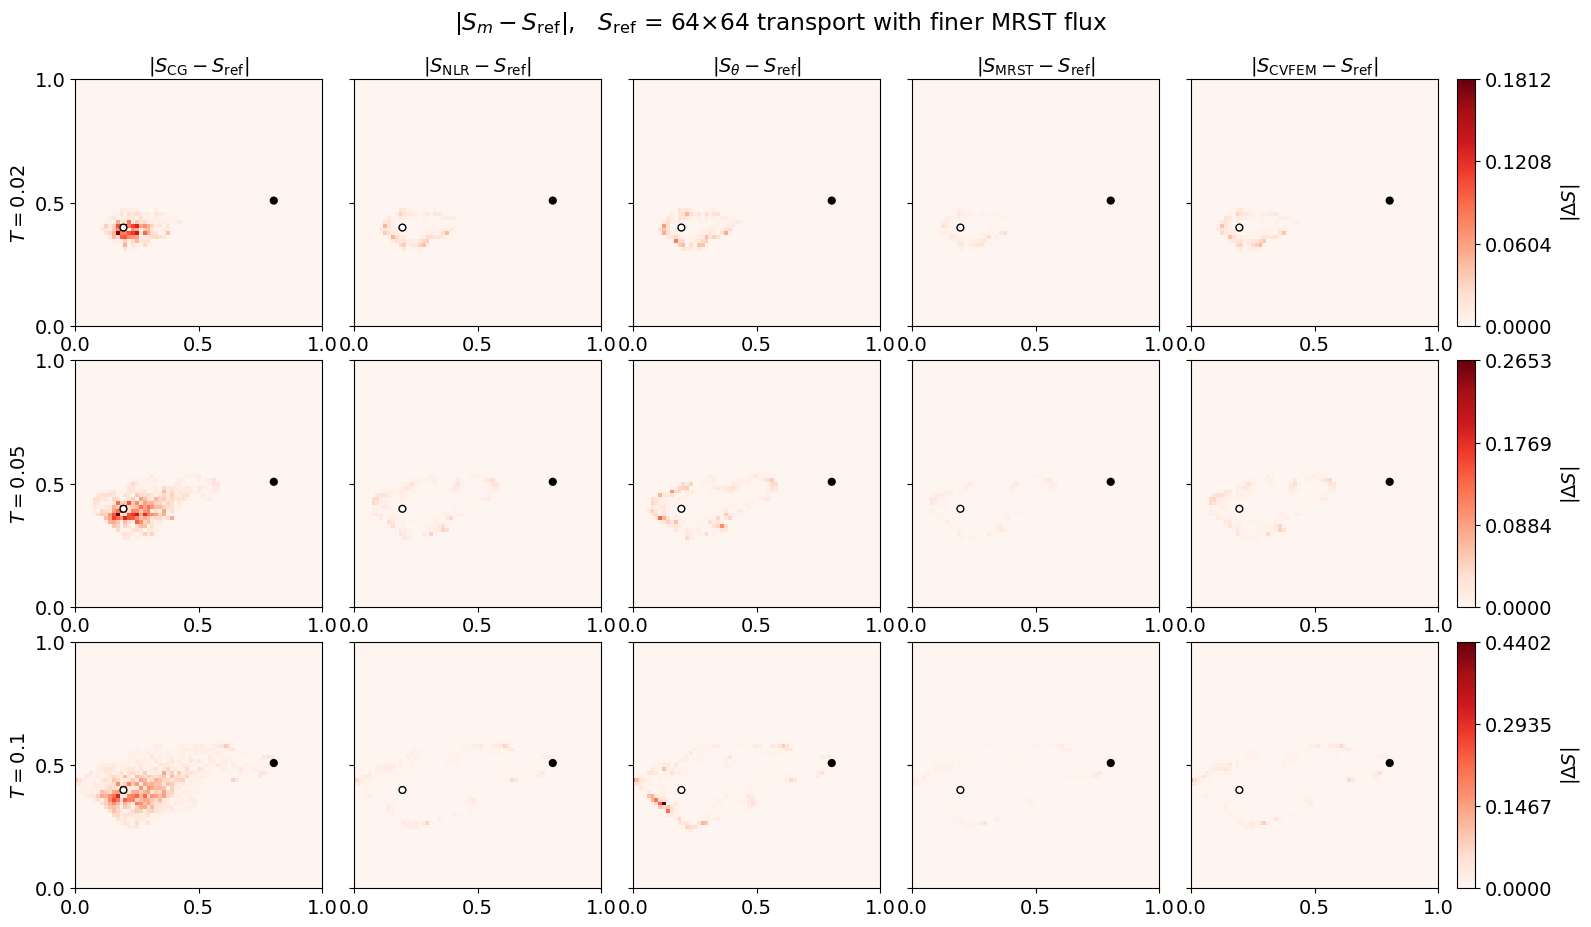

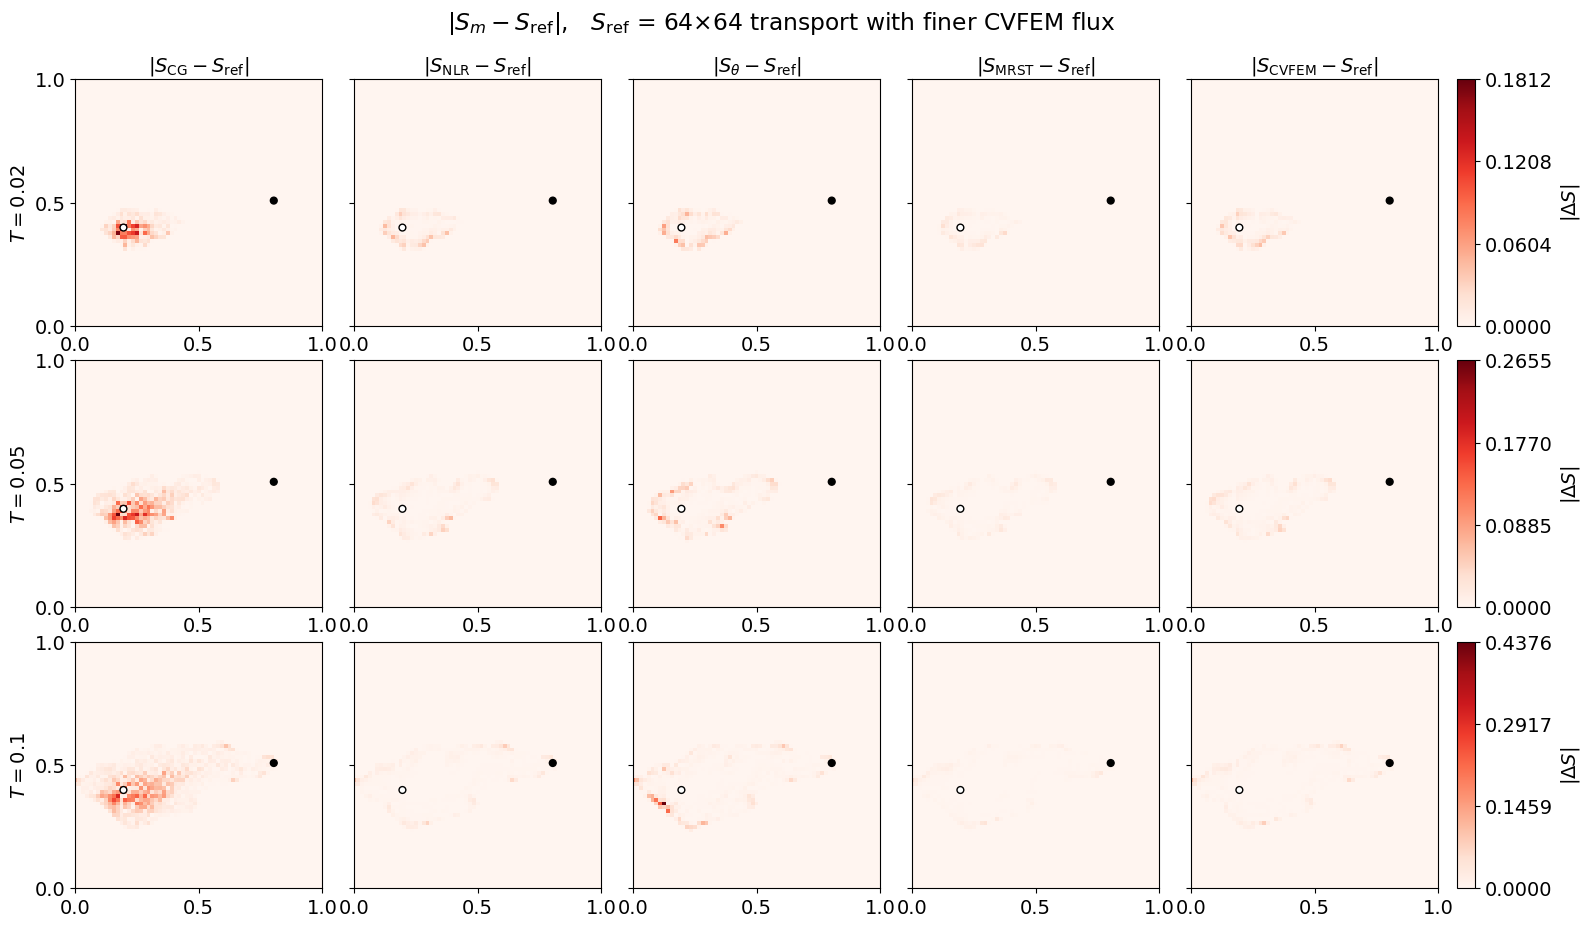

Multi-time saturation errors on the native 65 x 65 dual mesh relative to coarse transport driven by oracle fluxes:
  reference       time      method        L2 error       area RMSE   point RMSE    max|e|
  MRST1024_flux      0.02  CG        8.949856e-03 8.949856e-03 8.812166e-03 1.811501e-01
  MRST1024_flux      0.02  NLR       2.605211e-03 2.605211e-03 2.565130e-03 4.990531e-02
  MRST1024_flux      0.02  PINN      3.478121e-03 3.478121e-03 3.424611e-03 8.162820e-02
  MRST1024_flux      0.02  MRST      1.214957e-03 1.214957e-03 1.196265e-03 2.469123e-02
  MRST1024_flux      0.02  CVFEM     2.408518e-03 2.408518e-03 2.371464e-03 4.467955e-02
  MRST1024_flux      0.05  CG        1.557851e-02 1.557851e-02 1.533884e-02 2.652986e-01
  MRST1024_flux      0.05  NLR       3.102357e-03 3.102357e-03 3.054629e-03 4.616624e-02
  MRST1024_flux      0.05  PINN      5.646814e-03 5.646814e-03 5.559940e-03 1.347486e-01
  MRST1024_flux      0.05  MRST      1.525372e-03 1.525372e-03 1.501905e-03 2.36855

In [24]:
# Coarse dual transport driven by oracle fluxes on the native 65 x 65 Deng dual mesh.
# MRST1024: raw 1024 x 1024 Cartesian face fluxes summed exactly onto the dual faces.
# CVFEM576: Q1 CVFEM pressure on a 576 x 576 grid, exported directly on the same dual faces.
# No RT0 reconstruction or interpolation is used in either oracle transfer.
COARSE_ORACLE_MRST1024_FILE = pathlib.Path(DATA_FILE).parent / "case3_mrst_export_spe10_ref_cvfem.mat"
COARSE_ORACLE_CVFEM576_FILE = pathlib.Path(DATA_FILE).parent / "case3_cvfem_oracle_spe10_576_dual64.mat"
COARSE_ORACLE_MRST1024_REF_NAME = "MRST1024_flux"
COARSE_ORACLE_CVFEM576_REF_NAME = "CVFEM576_flux"
COARSE_ORACLE_REF_NAME = COARSE_ORACLE_MRST1024_REF_NAME  # backward-compatible alias
COARSE_ORACLE_USE_METHOD_NSTEPS = True
COARSE_ORACLE_ENFORCE_CFL = True
COARSE_ORACLE_SHOW_SOURCE_POINTS = True
COARSE_ORACLE_MATH_LABELS = {
    COARSE_ORACLE_MRST1024_REF_NAME: r"\mathrm{MRST1024\,flux}",
    COARSE_ORACLE_CVFEM576_REF_NAME: r"\mathrm{CVFEM576\,flux}",
}
if "SAT_NATIVE_METHOD_ORDER" not in globals():
    SAT_NATIVE_METHOD_ORDER = [m for m in ["CG", "NLR", "PINN", "MRST", "CVFEM"] if m == "MRST" or m in dual_flux_by_method]
if "SAT_NATIVE_METHOD_TITLES" not in globals():
    SAT_NATIVE_METHOD_TITLES = {"CG": "CG", "NLR": "NLR", "PINN": "PINN", "MRST": "MRST (TPFA)", "CVFEM": "CVFEM"}
if "SAT_NATIVE_METHOD_LABELS" not in globals():
    SAT_NATIVE_METHOD_LABELS = {"CG": r"\mathrm{CG}", "NLR": r"\mathrm{NLR}", "PINN": r"\theta", "MRST": r"\mathrm{MRST}", "CVFEM": r"\mathrm{CVFEM}"}


def _axis_segment_lookup_for_raw_faces(target_p1, target_p2, n_raw, tol=1.0e-10):
    """Map each raw Cartesian face centroid key to one coarse dual subface."""
    target_p1 = np.asarray(target_p1, dtype=float).reshape(-1, 2)
    target_p2 = np.asarray(target_p2, dtype=float).reshape(-1, 2)
    lookup = {}
    duplicate_keys = 0
    skipped_targets = 0
    for j, (a, b) in enumerate(zip(target_p1, target_p2)):
        if abs(a[0] - b[0]) <= tol and abs(a[1] - b[1]) > tol:
            axis = "V"
            line = int(round(0.5 * (a[0] + b[0]) * n_raw))
            lo = int(round(min(a[1], b[1]) * n_raw))
            hi = int(round(max(a[1], b[1]) * n_raw))
        elif abs(a[1] - b[1]) <= tol and abs(a[0] - b[0]) > tol:
            axis = "H"
            line = int(round(0.5 * (a[1] + b[1]) * n_raw))
            lo = int(round(min(a[0], b[0]) * n_raw))
            hi = int(round(max(a[0], b[0]) * n_raw))
        else:
            skipped_targets += 1
            continue
        if hi <= lo:
            skipped_targets += 1
            continue
        lo = max(0, lo)
        hi = min(int(n_raw), hi)
        for m in range(lo, hi):
            key = (axis, int(line), int(m))
            if key in lookup and lookup[key] != j:
                duplicate_keys += 1
            lookup[key] = j
    return lookup, {"duplicate_keys": int(duplicate_keys), "skipped_targets": int(skipped_targets)}


def sum_mrst1024_primal_flux_to_coarse_dual_faces(path, target_p1, target_p2, target_normal):
    path = pathlib.Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing MRST-1024 oracle flux file: {path}")
    data = loadmat(path, squeeze_me=True, struct_as_record=False)
    required = ["face_flux_1024", "face_centroid_1024", "face_normal_1024"]
    missing = [name for name in required if name not in data]
    if missing:
        raise KeyError(f"{path.name} is missing required raw-1024 fields: {missing}")
    if "meta_pressure_celldim" in data:
        dims = np.asarray(data["meta_pressure_celldim"], dtype=np.int64).reshape(-1)
        if dims.size < 2 or int(dims[0]) != int(dims[1]):
            raise ValueError(f"Expected square MRST pressure grid, got meta_pressure_celldim={dims}")
        n_raw = int(dims[0])
    else:
        n_faces = int(np.asarray(data["face_flux_1024"]).size)
        n_raw = int(round((np.sqrt(1.0 + 2.0 * n_faces) - 1.0) / 2.0))
        if 2 * n_raw * (n_raw + 1) != n_faces:
            raise ValueError(f"Could not infer raw Cartesian grid size from {n_faces} faces")

    target_normal = np.asarray(target_normal, dtype=float).reshape(-1, 2)
    lookup, lookup_diag = _axis_segment_lookup_for_raw_faces(target_p1, target_p2, n_raw)
    face_flux = np.asarray(data["face_flux_1024"], dtype=float).reshape(-1)
    face_centroid = np.asarray(data["face_centroid_1024"], dtype=float).reshape(-1, 2)
    face_normal = np.asarray(data["face_normal_1024"], dtype=float).reshape(-1, 2)
    if face_centroid.shape[0] != face_flux.size or face_normal.shape[0] != face_flux.size:
        raise ValueError("Raw MRST face arrays have inconsistent lengths")

    Fout = np.zeros(len(target_normal), dtype=float)
    hit_count = np.zeros(len(target_normal), dtype=np.int64)
    used_raw_faces = 0
    skipped_not_on_target = 0
    skipped_orientation = 0
    for i, (F, ctr, nrm) in enumerate(zip(face_flux, face_centroid, face_normal)):
        if abs(nrm[0]) >= 0.5:
            axis = "V"
            line = int(round(float(ctr[0]) * n_raw))
            m = int(np.floor(np.clip(float(ctr[1]) * n_raw, 0.0, n_raw - 1.0e-12)))
        elif abs(nrm[1]) >= 0.5:
            axis = "H"
            line = int(round(float(ctr[1]) * n_raw))
            m = int(np.floor(np.clip(float(ctr[0]) * n_raw, 0.0, n_raw - 1.0e-12)))
        else:
            skipped_orientation += 1
            continue
        j = lookup.get((axis, int(line), int(m)))
        if j is None:
            skipped_not_on_target += 1
            continue
        orient = float(np.dot(nrm, target_normal[j]))
        if abs(orient) < 0.5:
            skipped_orientation += 1
            continue
        Fout[j] += float(F) * (1.0 if orient > 0.0 else -1.0)
        hit_count[j] += 1
        used_raw_faces += 1

    diagnostics = {
        "file": str(path),
        "n_raw": int(n_raw),
        "raw_faces_total": int(face_flux.size),
        "raw_faces_used": int(used_raw_faces),
        "target_faces": int(len(target_normal)),
        "matched_target_faces": int(np.count_nonzero(hit_count)),
        "min_raw_faces_per_matched_target": int(np.min(hit_count[hit_count > 0])) if np.any(hit_count > 0) else 0,
        "max_raw_faces_per_matched_target": int(np.max(hit_count)) if hit_count.size else 0,
        "skipped_not_on_target": int(skipped_not_on_target),
        "skipped_orientation": int(skipped_orientation),
        **lookup_diag,
    }
    return Fout, diagnostics


def _rounded_tuple(values, ndigits=12):
    return tuple(np.round(np.asarray(values, dtype=float).reshape(-1), ndigits).tolist())


def load_coarse_dual_flux_from_mat(path, target_owner, target_neigh, target_p1, target_p2, target_normal, tol=1.0e-10):
    path = pathlib.Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing coarse dual oracle flux file: {path}")
    data = loadmat(path, squeeze_me=True, struct_as_record=False)
    required = ["face_flux", "face_neighbors", "face_p1", "face_p2", "face_normal"]
    missing = [name for name in required if name not in data]
    if missing:
        raise KeyError(f"{path.name} is missing required dual-face fields: {missing}")

    face_flux = np.asarray(data["face_flux"], dtype=float).reshape(-1)
    face_neighbors = np.asarray(data["face_neighbors"], dtype=np.int64).reshape(-1, 2)
    face_p1 = np.asarray(data["face_p1"], dtype=float).reshape(-1, 2)
    face_p2 = np.asarray(data["face_p2"], dtype=float).reshape(-1, 2)
    face_normal = np.asarray(data["face_normal"], dtype=float).reshape(-1, 2)

    target_owner = np.asarray(target_owner, dtype=np.int64).reshape(-1)
    target_neigh = np.asarray(target_neigh, dtype=np.int64).reshape(-1)
    target_p1 = np.asarray(target_p1, dtype=float).reshape(-1, 2)
    target_p2 = np.asarray(target_p2, dtype=float).reshape(-1, 2)
    target_normal = np.asarray(target_normal, dtype=float).reshape(-1, 2)
    n_target = target_owner.size
    if face_flux.size != n_target:
        # Full-face export (e.g. 8580 aggregated dual faces) -> distribute onto the
        # notebook's subfaces, length-proportionally.  Exact for CV balances and
        # interface totals: both subfaces of an interior interface join the same
        # node pair, so only their sum enters transport and conservation.
        src_owner = face_neighbors[:, 0] - 1
        src_neigh = np.where(face_neighbors[:, 1] > 0, face_neighbors[:, 1] - 1, -1).astype(np.int64)
        src_len = np.linalg.norm(face_p2 - face_p1, axis=1)
        interior_lookup = {}
        boundary_lookup = {}
        for i in range(face_flux.size):
            if src_neigh[i] >= 0:
                key = (min(int(src_owner[i]), int(src_neigh[i])), max(int(src_owner[i]), int(src_neigh[i])))
                if key in interior_lookup:
                    raise ValueError(f"{path.name}: duplicate interior face for node pair {key}")
                interior_lookup[key] = i
            else:
                bkey = (int(src_owner[i]), int(round(face_normal[i, 0])), int(round(face_normal[i, 1])))
                if bkey in boundary_lookup:
                    raise ValueError(f"{path.name}: duplicate boundary face for {bkey}")
                boundary_lookup[bkey] = i

        t_len = np.linalg.norm(target_p2 - target_p1, axis=1)
        Fout = np.zeros(n_target, dtype=float)
        matched = 0
        missing_targets = []
        for j in range(n_target):
            if target_neigh[j] >= 0:
                key = (min(int(target_owner[j]), int(target_neigh[j])), max(int(target_owner[j]), int(target_neigh[j])))
                i = interior_lookup.get(key)
            else:
                i = boundary_lookup.get(
                    (int(target_owner[j]), int(round(target_normal[j, 0])), int(round(target_normal[j, 1])))
                )
            if i is None:
                missing_targets.append(j)
                continue
            orient = float(face_normal[i, 0] * target_normal[j, 0] + face_normal[i, 1] * target_normal[j, 1])
            Fout[j] = face_flux[i] * (t_len[j] / src_len[i]) * (1.0 if orient >= 0.0 else -1.0)
            matched += 1
        if missing_targets:
            raise ValueError(
                f"{path.name}: full-face split matched {matched}/{n_target} subfaces; "
                f"first missing target indices={missing_targets[:10]}"
            )
        diagnostics = {
            "file": str(path),
            "kind": "full dual faces split length-proportionally onto subfaces",
            "target_faces": int(n_target),
            "source_faces": int(face_flux.size),
            "mapping": "node-pair (+boundary-normal) match, length-proportional split",
            "matched_target_faces": int(matched),
            "max_geometry_error": float("nan"),
            "input_conservation_residual": float(np.asarray(data.get("conservation_residual", np.nan)).reshape(-1)[0]),
        }
        return Fout, diagnostics

    src_owner = face_neighbors[:, 0] - 1
    src_neigh = np.where(face_neighbors[:, 1] > 0, face_neighbors[:, 1] - 1, -1).astype(np.int64)
    direct_order = (
        np.array_equal(src_owner, target_owner)
        and np.array_equal(src_neigh, target_neigh)
        and np.max(np.abs(face_p1 - target_p1)) <= tol
        and np.max(np.abs(face_p2 - target_p2)) <= tol
        and np.max(np.abs(face_normal - target_normal)) <= tol
    )

    diagnostics = {
        "file": str(path),
        "kind": "CVFEM576 dual-face flux",
        "target_faces": int(n_target),
        "input_conservation_residual": float(np.asarray(data.get("conservation_residual", np.nan)).reshape(-1)[0]),
    }
    if direct_order:
        diagnostics.update({
            "mapping": "direct file order",
            "matched_target_faces": int(n_target),
            "max_geometry_error": float(max(
                np.max(np.abs(face_p1 - target_p1)),
                np.max(np.abs(face_p2 - target_p2)),
                np.max(np.abs(face_normal - target_normal)),
            )),
        })
        return face_flux.copy(), diagnostics

    source_lookup = {}
    duplicate_keys = 0
    for i in range(face_flux.size):
        key = (
            int(src_owner[i]), int(src_neigh[i]),
            _rounded_tuple(face_p1[i]), _rounded_tuple(face_p2[i]), _rounded_tuple(face_normal[i]),
        )
        if key in source_lookup:
            duplicate_keys += 1
        source_lookup[key] = i

    Fout = np.zeros(n_target, dtype=float)
    matched = 0
    missing_targets = []
    for j in range(n_target):
        key = (
            int(target_owner[j]), int(target_neigh[j]),
            _rounded_tuple(target_p1[j]), _rounded_tuple(target_p2[j]), _rounded_tuple(target_normal[j]),
        )
        src_idx = source_lookup.get(key)
        if src_idx is None:
            missing_targets.append(j)
            continue
        Fout[j] = face_flux[src_idx]
        matched += 1
    if matched != n_target:
        raise ValueError(
            f"{path.name}: only matched {matched}/{n_target} dual faces; "
            f"first missing target indices={missing_targets[:10]}"
        )
    diagnostics.update({
        "mapping": "reordered by owner/neighbor/geometry",
        "matched_target_faces": int(matched),
        "duplicate_keys": int(duplicate_keys),
        "max_geometry_error": float("nan"),
    })
    return Fout, diagnostics


def _dual_balance_residual_for_flux(Fout):
    residual = np.zeros(n_nodes, dtype=float)
    np.add.at(residual, dual_owner, Fout)
    np.add.at(residual, dual_neigh[dual_has_neighbor], -Fout[dual_has_neighbor])
    return residual - dual_source_rate


def _stats_line(arr):
    arr = np.asarray(arr, dtype=float).reshape(-1)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return "n=0"
    return (
        f"n={arr.size:d} mean|R|={np.mean(np.abs(arr)):.6e} "
        f"median|R|={np.median(np.abs(arr)):.6e} "
        f"rmse={np.sqrt(np.mean(arr**2)):.6e} "
        f"max|R|={np.max(np.abs(arr)):.6e} sum(R)={np.sum(arr):+.6e}"
    )


def _snapshot_key_for_dual_time(data, T, explicit=True):
    suffix = f"T{int(round(100.0 * float(T))):03d}"
    candidates = [f"sw_{suffix}_exp", f"sw_{suffix}"] if explicit else [f"sw_{suffix}", f"sw_{suffix}_exp"]
    for key in candidates:
        if key in data:
            return key
    if "snap_times" in data:
        times = np.asarray(data["snap_times"], dtype=float).reshape(-1)
        if times.size:
            idx = int(np.argmin(np.abs(times - float(T))))
            suffix = f"T{int(round(100.0 * float(times[idx]))):03d}"
            candidates = [f"sw_{suffix}_exp", f"sw_{suffix}"] if explicit else [f"sw_{suffix}", f"sw_{suffix}_exp"]
            for key in candidates:
                if key in data:
                    return key
    return None


def _ensure_method_dual_by_time_has_mrst(methods_by_time):
    out = {key: dict(val) for key, val in methods_by_time.items()}
    if all("MRST" in out.get(key, {}) for key, _T, _pvi in transport_cases):
        return out
    path = globals().get("MRST_DUAL65_FILE", pathlib.Path(DATA_FILE).parent / "case3_mrst_export_finep_dualT.mat")
    path = pathlib.Path(path)
    if not path.exists():
        return out
    data = loadmat(path, squeeze_me=True, struct_as_record=False)
    for key, T, _pvi in transport_cases:
        if "MRST" in out.get(key, {}):
            continue
        skey = _snapshot_key_for_dual_time(data, T, explicit=globals().get("MRST_DUAL_USE_EXPLICIT_TRANSPORT", True))
        if skey is None:
            continue
        arr = np.asarray(data[skey], dtype=float).reshape(-1)
        if arr.size == n_nodes:
            out.setdefault(key, {})["MRST"] = arr.reshape(dual_shape)
    return out


coarse_ref_flux_by_name = {}
coarse_ref_flux_diagnostics = {}
if COARSE_ORACLE_MRST1024_FILE.exists():
    _F_mrst1024, _diag_mrst1024 = sum_mrst1024_primal_flux_to_coarse_dual_faces(
        COARSE_ORACLE_MRST1024_FILE,
        dual_face_p1,
        dual_face_p2,
        dual_face_normal,
    )
    _diag_mrst1024["kind"] = "MRST1024 raw primal-face sum"
    coarse_ref_flux_by_name[COARSE_ORACLE_MRST1024_REF_NAME] = _F_mrst1024
    coarse_ref_flux_diagnostics[COARSE_ORACLE_MRST1024_REF_NAME] = _diag_mrst1024
else:
    print(f"Missing raw MRST-1024 oracle flux file: {COARSE_ORACLE_MRST1024_FILE}")

if COARSE_ORACLE_CVFEM576_FILE.exists():
    _F_cvfem576, _diag_cvfem576 = load_coarse_dual_flux_from_mat(
        COARSE_ORACLE_CVFEM576_FILE,
        dual_owner,
        dual_neigh,
        dual_face_p1,
        dual_face_p2,
        dual_face_normal,
    )
    coarse_ref_flux_by_name[COARSE_ORACLE_CVFEM576_REF_NAME] = _F_cvfem576
    coarse_ref_flux_diagnostics[COARSE_ORACLE_CVFEM576_REF_NAME] = _diag_cvfem576
else:
    print(f"Missing CVFEM-576 oracle flux file: {COARSE_ORACLE_CVFEM576_FILE}")

coarse_ref_flux_transport = {}
coarse_ref_flux_meta = {}
if RUN_DUAL_TRANSPORT and coarse_ref_flux_by_name:
    for ref_name, Fref in coarse_ref_flux_by_name.items():
        Rref = _dual_balance_residual_for_flux(Fref)
        diag = coarse_ref_flux_diagnostics[ref_name]
        print(f"Coarse dual oracle flux ({ref_name}, {diag.get('kind', 'oracle')}):")
        print(f"  file={pathlib.Path(diag['file']).name}")
        if "n_raw" in diag:
            print(f"  raw grid={diag['n_raw']} x {diag['n_raw']}")
            print(
                "  matched target faces="
                f"{diag['matched_target_faces']} / {diag['target_faces']}, "
                f"raw faces/target=[{diag['min_raw_faces_per_matched_target']}, {diag['max_raw_faces_per_matched_target']}], "
                f"raw faces used={diag['raw_faces_used']} / {diag['raw_faces_total']}"
            )
            if diag["duplicate_keys"] or diag["skipped_targets"] or diag["skipped_orientation"]:
                print(
                    f"  mapping notes: duplicate_keys={diag['duplicate_keys']}, skipped_targets={diag['skipped_targets']}, "
                    f"skipped_orientation={diag['skipped_orientation']}, skipped_not_on_target={diag['skipped_not_on_target']}"
                )
        else:
            print(
                f"  matched target faces={diag['matched_target_faces']} / {diag['target_faces']}, "
                f"mapping={diag['mapping']}, max geometry error={diag['max_geometry_error']:.3e}"
            )
            if np.isfinite(diag.get("input_conservation_residual", np.nan)):
                print(f"  exported balance residual={diag['input_conservation_residual']:.3e}")
        print(f"  single-phase balance residual sum(outward flux)-source: {_stats_line(Rref)}")
        coarse_ref_flux_transport[ref_name] = {}
        coarse_ref_flux_meta[ref_name] = {}
        dt_cfl_ref = compute_dual_transport_dt(Fref)
        for key, T, _pvi in transport_cases:
            nsteps_method = int(reference_nsteps.get(key, 1)) if "reference_nsteps" in globals() else 1
            nsteps_cfl = max(1, int(np.ceil(float(T) / dt_cfl_ref)))
            if COARSE_ORACLE_USE_METHOD_NSTEPS:
                nsteps = max(1, nsteps_method)
                if COARSE_ORACLE_ENFORCE_CFL:
                    nsteps = max(nsteps, nsteps_cfl)
            else:
                nsteps = nsteps_cfl
            Sref, meta = advance_dual_transport(Fref, float(T), clip=TRANSPORT_CLIP, nsteps_override=nsteps)
            coarse_ref_flux_transport[ref_name][key] = np.asarray(Sref, dtype=float).reshape(dual_shape)
            coarse_ref_flux_meta[ref_name][key] = meta
        print(
            f"  coarse transport dt_cfl={dt_cfl_ref:.6e}, "
            f"nsteps={[coarse_ref_flux_meta[ref_name][key]['nsteps'] for key, _, _ in transport_cases]}"
        )
else:
    coarse_ref_flux_transport = {}


if "method_dual_by_time" not in globals():
    method_dual_by_time = {}
    for key, _T, _pvi in transport_cases:
        methods = {}
        for name in ["CG", "NLR", "PINN", "CVFEM"]:
            if RUN_DUAL_TRANSPORT and name in transport_results.get(key, {}):
                methods[name] = np.asarray(transport_results[key][name]["S"], dtype=float).reshape(dual_shape)
        method_dual_by_time[key] = methods
method_dual_by_time = _ensure_method_dual_by_time_has_mrst(method_dual_by_time)

coarse_ref_flux_error_rows = []
coarse_ref_flux_abs_errors = {}
_area_weights_dual = np.outer(np.diff(y_dual_edges), np.diff(x_dual_edges)).reshape(-1)
_area_total_dual = float(np.sum(_area_weights_dual))

for ref_name, ref_results in coarse_ref_flux_transport.items():
    for key, T, _pvi in transport_cases:
        if key not in ref_results:
            continue
        Sref = np.asarray(ref_results[key], dtype=float).reshape(-1)
        methods = method_dual_by_time.get(key, {})
        for method in SAT_NATIVE_METHOD_ORDER:
            if method not in methods:
                continue
            Sm = np.asarray(methods[method], dtype=float).reshape(-1)
            if Sm.size != Sref.size:
                continue
            diff = Sm - Sref
            abs_diff = np.abs(diff).reshape(dual_shape)
            coarse_ref_flux_abs_errors[(ref_name, key, method)] = abs_diff
            coarse_ref_flux_error_rows.append({
                "reference": ref_name,
                "T": float(T),
                "method": method,
                "L2": float(np.sqrt(np.sum(diff ** 2 * _area_weights_dual))),
                "RMSE": float(np.sqrt(np.sum(diff ** 2 * _area_weights_dual) / max(_area_total_dual, 1.0e-300))),
                "point_RMSE": float(np.sqrt(np.mean(diff ** 2))),
                "max_abs": float(np.max(np.abs(diff))),
            })


def _plot_coarse_ref_flux_errors(ref_name):
    if ref_name not in coarse_ref_flux_transport:
        return
    available_rows = [(key, T, pvi) for key, T, pvi in transport_cases if key in coarse_ref_flux_transport[ref_name]]
    if not available_rows:
        print(f"No times available for {ref_name}; skipping plot.")
        return
    nrows = len(available_rows)
    ncols = len(SAT_NATIVE_METHOD_ORDER)
    with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
        fig, axes = plt.subplots(nrows, ncols, figsize=(3.25 * ncols, 3.10 * nrows), squeeze=False)
        fig.subplots_adjust(left=0.065, right=0.905, bottom=0.05, top=0.92, wspace=0.12, hspace=0.14)
        for irow, (key, T, _pvi) in enumerate(available_rows):
            row_errors = [coarse_ref_flux_abs_errors.get((ref_name, key, method)) for method in SAT_NATIVE_METHOD_ORDER]
            row_vmax = max([float(np.nanmax(err)) for err in row_errors if err is not None] + [1.0e-14])
            row_pcm = None
            for icol, method in enumerate(SAT_NATIVE_METHOD_ORDER):
                ax = axes[irow, icol]
                err = coarse_ref_flux_abs_errors.get((ref_name, key, method))
                if err is None:
                    ax.axis("off")
                    if irow == 0:
                        ax.set_title(f"{SAT_NATIVE_METHOD_TITLES.get(method, method)} missing")
                    continue
                row_pcm = ax.pcolormesh(
                    x_dual_edges, y_dual_edges, err,
                    cmap="Reds", vmin=0.0, vmax=row_vmax, shading="flat",
                )
                if COARSE_ORACLE_SHOW_SOURCE_POINTS:
                    ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=24, edgecolors="k", zorder=5)
                _method_label = SAT_NATIVE_METHOD_LABELS.get(method, rf"\mathrm{{{method}}}")
                if irow == 0:
                    ax.set_title(rf"$|S_{{{_method_label}}} - S_\mathrm{{ref}}|$")
                if icol == 0:
                    ax.set_ylabel(rf"$T = {float(T):g}$")
                ax.set_aspect("equal")
                ax.set_xlim(xmin, xmax)
                ax.set_ylim(ymin, ymax)
                ax.set_xticks([0.0, 0.5, 1.0])
                ax.set_yticks([0.0, 0.5, 1.0])
                ax.grid(False)
                if icol > 0:
                    ax.tick_params(labelleft=False)
            if row_pcm is not None:
                for _ax_row in axes[irow, :]:
                    _ax_row.apply_aspect()
                _pos = axes[irow, -1].get_position()
                _cax = fig.add_axes([_pos.x1 + 0.012, _pos.y0, 0.011, _pos.height])
                cbar = fig.colorbar(row_pcm, cax=_cax)
                cbar.set_label(r"$|\Delta S|$")
                cbar.set_ticks(np.linspace(0.0, row_vmax, 4))
        if "MRST" in ref_name.upper():
            _ref_flux_source = "MRST"
        elif "CVFEM" in ref_name.upper():
            _ref_flux_source = "CVFEM"
        else:
            _ref_flux_source = ref_name.replace("_", " ")
        fig.suptitle(
            rf"$|S_m - S_\mathrm{{ref}}|$,   $S_\mathrm{{ref}}$ = 64$\times$64 transport with finer {_ref_flux_source} flux",
            y=0.995,
        )
        plt.show()


for _ref_name in coarse_ref_flux_transport:
    _plot_coarse_ref_flux_errors(_ref_name)

print("Multi-time saturation errors on the native 65 x 65 dual mesh relative to coarse transport driven by oracle fluxes:")
print("  reference       time      method        L2 error       area RMSE   point RMSE    max|e|")
for row in coarse_ref_flux_error_rows:
    print(
        f"  {row['reference']:<14} {row['T']:8.4g}  {row['method']:<8} "
        f"{row['L2']:13.6e} {row['RMSE']:11.6e} {row['point_RMSE']:11.6e} {row['max_abs']:10.6e}"
    )





In [17]:
# Save compact diagnostics for paper tables/figures.
OUT_DIR = pathlib.Path(f"result_deng_example4_spe10_Q{CG_ORDER}_hardcurl_PINN_no_fracture")
OUT_DIR.mkdir(exist_ok=True)
np.savez(
    OUT_DIR / "diagnostics.npz",
    nx=np.array(nx),
    ny=np.array(ny),
    CG_ORDER=np.array(CG_ORDER),
    dual_shape=np.asarray(dual_shape),
    physdim=physdim,
    xc_matrix=xc_matrix,
    kappa_cell=kappa_cell_dg0,
    source_points_requested=SOURCE_POINTS_REQUESTED,
    source_points_effective=source_points_effective,
    source_cell_ids=source_cell_ids,
    source_rates=SOURCE_RATES,
    source_rate_cell=source_rate_cell,
    p_nodes=p_nodes,
    p_matrix_cg=p_matrix_cg,
    p_nlr_nodes=p_nlr_nodes,
    p_cvfem_nodes=p_cvfem_nodes,
    p_matrix_cvfem=p_matrix_cvfem,
    R_tau_cg=R_tau_cg,
    R_tau_nlr=R_tau_nlr,
    R_xi_cg=R_xi_cg,
    R_xi_nlr=R_xi_nlr,
    R_tau_cvfem=R_tau_cvfem,
    R_xi_cvfem=R_xi_cvfem,
    face_flux_cg=face_flux_cg_global,
    face_flux_nlr=face_flux_nlr_global,
    face_flux_cvfem=face_flux_cvfem_global,
    face_flux_pinn=np.asarray([]) if face_flux_pinn_global is None else face_flux_pinn_global,
    pinn_active=np.array(PINN_ACTIVE),
    transport_method_names=transport_rect_method_names,
    transport_S=transport_rect_S,
    transport_T=np.array(selected_T),
    transport_PVI=np.array(selected_PVI),
    transport_water_mass=transport_rect_water_mass,
    transport_water_net=transport_rect_water_net,
    transport_water_balance_error=transport_rect_water_balance_error,
    transport_water_balance_error_pct=transport_rect_water_balance_error_pct,
    mrst_primal_snapshot_key=np.array(_mrst_sw_key if _mrst_sw_key is not None else ""),
    mrst_primal_use_explicit_transport=np.array(MRST_PRIMAL_USE_EXPLICIT_TRANSPORT if "MRST_PRIMAL_USE_EXPLICIT_TRANSPORT" in globals() else False),
    mrst_fine_snapshot_key=np.array(_fine_sw_key if _fine_sw_key is not None else ""),
    mrst_dual_use_explicit_transport=np.array(MRST_DUAL_USE_EXPLICIT_TRANSPORT if "MRST_DUAL_USE_EXPLICIT_TRANSPORT" in globals() else False),
    mrst_fine_file=np.array(str(FINE_MRST_FILE) if FINE_MRST_FILE is not None else ""),
    mrst_fine_meta_grid=np.array(str(mrst_fine.get("meta_grid", "")) if MRST_FINE_AVAILABLE else ""),
    mrst_fine_meta_workflow=np.array(str(mrst_fine.get("meta_workflow", "")) if MRST_FINE_AVAILABLE else ""),
    mrst_fine_dt=np.asarray(mrst_fine.get("meta_dt", []), dtype=float) if MRST_FINE_AVAILABLE else np.array([]),
    mrst_fine_nsteps=np.asarray(mrst_fine.get("meta_nsteps", [])) if MRST_FINE_AVAILABLE else np.array([]),
    native_error_reference=np.asarray([row["reference"] for row in saturation_native_error_rows], dtype=object) if "saturation_native_error_rows" in globals() else np.asarray([], dtype=object),
    native_error_time=np.asarray([row["T"] for row in saturation_native_error_rows], dtype=float) if "saturation_native_error_rows" in globals() else np.asarray([], dtype=float),
    native_error_method=np.asarray([row["method"] for row in saturation_native_error_rows], dtype=object) if "saturation_native_error_rows" in globals() else np.asarray([], dtype=object),
    native_error_family=np.asarray([row["family"] for row in saturation_native_error_rows], dtype=object) if "saturation_native_error_rows" in globals() else np.asarray([], dtype=object),
    native_error_l2=np.asarray([row["L2"] for row in saturation_native_error_rows], dtype=float) if "saturation_native_error_rows" in globals() else np.asarray([], dtype=float),
    native_error_rmse=np.asarray([row["RMSE"] for row in saturation_native_error_rows], dtype=float) if "saturation_native_error_rows" in globals() else np.asarray([], dtype=float),
    native_error_point_rmse=np.asarray([row["point_RMSE"] for row in saturation_native_error_rows], dtype=float) if "saturation_native_error_rows" in globals() else np.asarray([], dtype=float),
    native_error_max_abs=np.asarray([row["max_abs"] for row in saturation_native_error_rows], dtype=float) if "saturation_native_error_rows" in globals() else np.asarray([], dtype=float),
    coarse_ref_flux_error_reference=np.asarray([row["reference"] for row in coarse_ref_flux_error_rows], dtype=object) if "coarse_ref_flux_error_rows" in globals() else np.asarray([], dtype=object),
    coarse_ref_flux_error_time=np.asarray([row["T"] for row in coarse_ref_flux_error_rows], dtype=float) if "coarse_ref_flux_error_rows" in globals() else np.asarray([], dtype=float),
    coarse_ref_flux_error_method=np.asarray([row["method"] for row in coarse_ref_flux_error_rows], dtype=object) if "coarse_ref_flux_error_rows" in globals() else np.asarray([], dtype=object),
    coarse_ref_flux_error_l2=np.asarray([row["L2"] for row in coarse_ref_flux_error_rows], dtype=float) if "coarse_ref_flux_error_rows" in globals() else np.asarray([], dtype=float),
    coarse_ref_flux_error_rmse=np.asarray([row["RMSE"] for row in coarse_ref_flux_error_rows], dtype=float) if "coarse_ref_flux_error_rows" in globals() else np.asarray([], dtype=float),
    coarse_ref_flux_error_point_rmse=np.asarray([row["point_RMSE"] for row in coarse_ref_flux_error_rows], dtype=float) if "coarse_ref_flux_error_rows" in globals() else np.asarray([], dtype=float),
    coarse_ref_flux_error_max_abs=np.asarray([row["max_abs"] for row in coarse_ref_flux_error_rows], dtype=float) if "coarse_ref_flux_error_rows" in globals() else np.asarray([], dtype=float),
)
print(f"Saved diagnostics to {OUT_DIR / 'diagnostics.npz'}")




Saved diagnostics to result_deng_example4_spe10_Q1_hardcurl_PINN_no_fracture/diagnostics.npz


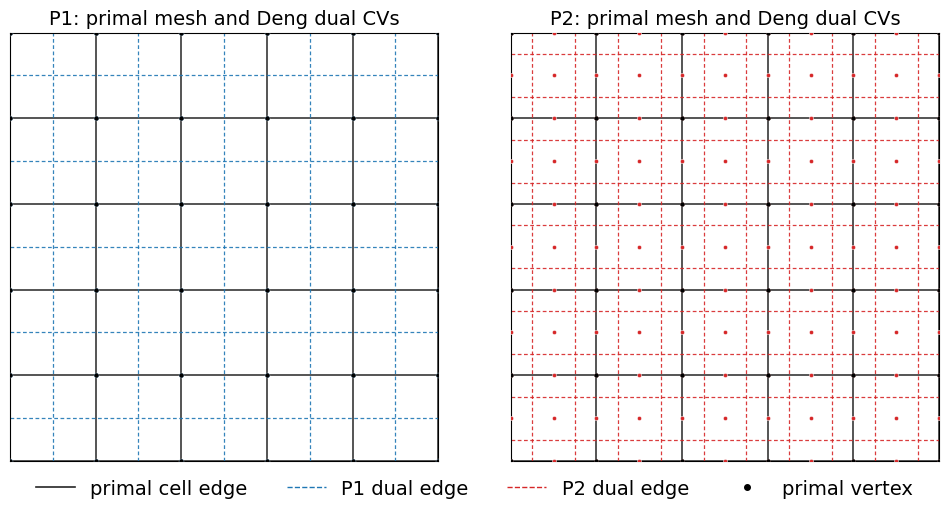

In [18]:
# Visual explanation: primal mesh versus Deng nodal dual meshes for P1 and P2.
# This schematic is zoomed near the injector primal cell so the dual CV structure is readable.
DENG_MESH_SKETCH_AROUND_INJECTOR = True
DENG_MESH_SKETCH_HALF_WIDTH_CELLS = 2
DENG_MESH_SKETCH_SAVE = True


def _dual_edges_from_order(order):
    xq = np.linspace(xmin, xmax, nx * order + 1)
    yq = np.linspace(ymin, ymax, ny * order + 1)
    xd = np.concatenate([[xmin], 0.5 * (xq[:-1] + xq[1:]), [xmax]])
    yd = np.concatenate([[ymin], 0.5 * (yq[:-1] + yq[1:]), [ymax]])
    return xq, yq, xd, yd


def _source_node_indices_for_order(order, cid):
    ix = int(cid % nx)
    iy = int(cid // nx)
    ids = []
    for jj in range(order + 1):
        for ii in range(order + 1):
            ids.append((ix * order + ii, iy * order + jj))
    return ids


inj_cid = int(source_cell_ids[0])
inj_ix = inj_cid % nx
inj_iy = inj_cid // nx
if DENG_MESH_SKETCH_AROUND_INJECTOR:
    pad = int(DENG_MESH_SKETCH_HALF_WIDTH_CELLS)
    ix0 = max(0, inj_ix - pad)
    ix1 = min(nx, inj_ix + pad + 1)
    iy0 = max(0, inj_iy - pad)
    iy1 = min(ny, inj_iy + pad + 1)
else:
    ix0, ix1, iy0, iy1 = 0, min(nx, 5), 0, min(ny, 5)

xlim = (xmin + ix0 * hx, xmin + ix1 * hx)
ylim = (ymin + iy0 * hy, ymin + iy1 * hy)


def _draw_mesh_panel(ax, order, dual_color, title):
    xq, yq, xd, yd = _dual_edges_from_order(order)

    # Primal 64x64 cell edges.
    for i in range(ix0, ix1 + 1):
        x = xmin + i * hx
        ax.plot([x, x], ylim, color="0.15", lw=1.1, zorder=1)
    for j in range(iy0, iy1 + 1):
        y = ymin + j * hy
        ax.plot(xlim, [y, y], color="0.15", lw=1.1, zorder=1)

    # Deng nodal-dual CV edges for the chosen order.
    for x in xd[(xd >= xlim[0] - 1e-14) & (xd <= xlim[1] + 1e-14)]:
        ax.plot([x, x], ylim, color=dual_color, lw=0.9, ls="--", dashes=(3.0, 2.0), alpha=0.9, zorder=2)
    for y in yd[(yd >= ylim[0] - 1e-14) & (yd <= ylim[1] + 1e-14)]:
        ax.plot(xlim, [y, y], color=dual_color, lw=0.9, ls="--", dashes=(3.0, 2.0), alpha=0.9, zorder=2)

    # Qk pressure/transport nodes.
    Xq, Yq = np.meshgrid(xq, yq, indexing="xy")
    mask = (
        (Xq >= xlim[0] - 1e-14) & (Xq <= xlim[1] + 1e-14)
        & (Yq >= ylim[0] - 1e-14) & (Yq <= ylim[1] + 1e-14)
    )
    ax.scatter(Xq[mask], Yq[mask], s=12 if order == 1 else 9, c=dual_color, edgecolors="white", linewidths=0.35, zorder=4)

    # Primal vertices, shown separately because the Q2 dual mesh has extra nodes.
    xp = np.linspace(xmin, xmax, nx + 1)
    yp = np.linspace(ymin, ymax, ny + 1)
    Xp, Yp = np.meshgrid(xp, yp, indexing="xy")
    pmask = (
        (Xp >= xlim[0] - 1e-14) & (Xp <= xlim[1] + 1e-14)
        & (Yp >= ylim[0] - 1e-14) & (Yp <= ylim[1] + 1e-14)
    )
    ax.scatter(Xp[pmask], Yp[pmask], s=20, c="black", marker=".", zorder=6)

    ax.set_title(title)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)


with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 12, "ytick.labelsize": 12}):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), constrained_layout=True)
    _draw_mesh_panel(axes[0], 1, "#1f77b4", r"P1: primal mesh and Deng dual CVs")
    _draw_mesh_panel(axes[1], 2, "#d62728", r"P2: primal mesh and Deng dual CVs")

    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], color="0.15", lw=1.2, label="primal cell edge"),
        Line2D([0], [0], color="#1f77b4", lw=1.0, ls="--", label="P1 dual edge"),
        Line2D([0], [0], color="#d62728", lw=1.0, ls="--", label="P2 dual edge"),
        Line2D([0], [0], marker=".", color="black", linestyle="none", markersize=8, label="primal vertex"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.11))
    # fig.suptitle("Deng nodal dual control volumes", y=1.02)
    # if DENG_MESH_SKETCH_SAVE:
    #     _mesh_out_dir = OUT_DIR if "OUT_DIR" in globals() else pathlib.Path("result_deng_example4_spe10_mesh_sketch")
    #     _mesh_out_dir.mkdir(exist_ok=True)
    #     fig.savefig(_mesh_out_dir / "deng_q1_q2_dual_mesh_sketch.png", dpi=300, bbox_inches="tight")
    #     print(f"Saved mesh sketch to {_mesh_out_dir / 'deng_q1_q2_dual_mesh_sketch.png'}")
    plt.show()
